# Manuscript figures

In [1]:
%load_ext autoreload
%autoreload 2

import os
# only load this one time per session
if 'NOTEBOOK_INITIALIZED' not in globals():
    os.chdir(os.path.dirname(os.path.abspath('.')))
    NOTEBOOK_INITIALIZED = True

import seaborn as sns
import matplotlib.pyplot as plt
import pooch
import pandas as pd
from tqdm import tqdm
import numpy as np

import src.utils as utils
import src.config as config
import src.haplosaurus as hs
import src.ESM as ESM
import src.ESM_predict as ESMp
import src.gprofiler as gp
import src.vep_pipeline as vp
import src.vep_analysis as va
import src.vep_metrics as vm
import src.proteingym as pg 
import src.ensembl_rest as er
import src.biopython as bp
import src.analysis.distributions as db
import src.analysis.attributions as ab
import src.colabfold.colabfold as cf
import src.benchmark.clinvar as bcv

pd.set_option('display.max_columns', None)
plt.rcParams['font.family'] =  'Nimbus Sans'

/home/schilder/.conda/envs/esm2/lib/python3.12/site-packages/Bio/Application/__init__.py:39: BiopythonDeprecationWarning: The Bio.Application modules and modules relying on it have been deprecated.

Due to the on going maintenance burden of keeping command line application
wrappers up to date, we have decided to deprecate and eventually remove these
modules.

We instead now recommend building your command line and invoking it directly
with the subprocess module.
  warnings.warn(


## Figure 1

### Figure 1a

![](fig/fig1a.pdf)

### Figure 1b

![](fig/fig1b.pdf)

### Figure 1c

In [2]:
# Focus on one model for the main plots
model_name = "esm2_t33_650M_UR50D"

force = False
tmp_vep_path = f"./results/data/vep_df_{model_name}.parquet"
if os.path.exists(tmp_vep_path) and not force:
    print(f"Loading {tmp_vep_path}")
    vep_df = pd.read_parquet(tmp_vep_path)
else:
    vep_files = va.list_vep_files(model_location=model_name, 
                                  as_df=True)
    vep_df = va.merge_vep(add_metadata=True, 
                          scoring_strategy=["masked-marginals"], 
                          vep_files=vep_files.loc[vep_files['model_location']==model_name]
                               )
    print(f"Saving {tmp_vep_path}")
    vep_df.to_parquet(tmp_vep_path)

vep_df.head() 

Loading ./results/data/vep_df_esm2_t33_650M_UR50D.parquet


,haplotype,protein,protein_sequence,mutant,mutated_sequence,DMS_bin_score,VEP,scoring_strategy,is_ref,model_location,variant_set,ENSP,ENST,mutant_in_haplotype,site,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,#Uploaded_variation,Location,Allele,Gene,Feature,Feature_type,Consequence,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,IMPACT,DISTANCE,STRAND,FLAGS,REFSEQ_MATCH,REFSEQ_OFFSET,GIVEN_REF,USED_REF,BAM_EDIT,HGVSc,HGVSp,HGVS_OFFSET,AF_ESP,AF_EXAC,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNSIGCONF,CLNVC,CLNVCSO,GENEINFO,MC,ORIGIN,RS,AF_TGP,CLNVI,CLNDISDBINCL,CLNDNINCL,CLNSIGINCL,EVH_epistatic,EVH_independent,ESM1V_ensemble_mean,Tranception,model_count,clinsig
0,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,L1045F,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Benign,-3.635069,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,NP_000229.1:L1045F,7,150947347,67473,G,A,.,PASS,67473,7:150947347,A,3757,NM_000238.4,Transcript,missense_variant,3541,3133,1045,L/F,Ctc/Ttc,-,MODERATE,-,-1,-,-,-,G,G,-,NM_000238.4:c.3133C>T,NP_000229.1:p.Leu1045Phe,-,NaN,0.00000,78369,"MedGen:CN230736|EFO:EFO_0004269,Human_Phenotyp...",Cardiovascular_phenotype|Cardiac_arrhythmia|Co...,NC_000007.14:g.150947347G>A,"criteria_provided,_multiple_submitters,_no_con...",Benign,NaN,single_nucleotide_variant,SO:0001483,KCNH2:3757,SO:0001583|missense_variant,1,199473025,NaN,ClinGen:CA008015,None,None,None,NaN,NaN,-6.731237,-0.021689,6,benign
1,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,D1003Y,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Pathogenic,-1.670645,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,NP_000229.1:D1003Y,7,150947473,200516,C,A,.,PASS,200516,7:150947473,A,3757,NM_000238.4,Transcript,missense_variant,3415,3007,1003,D/Y,Gac/Tac,-,MODERATE,-,-1,-,-,-,C,C,-,NM_000238.4:c.3007G>T,NP_000229.1:p.Asp1003Tyr,-,NaN,NaN,197155,MedGen:CN517202,not_provided,NC_000007.14:g.150947473C>A,"criteria_provided,_single_submitter",Likely_pathogenic,NaN,single_nucleotide_variant,SO:0001483,KCNH2:3757,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,794728402,NaN,ClinGen:CA007791,None,None,None,NaN,NaN,-2.509515,-0.039753,6,likely_path
2,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,N996I,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Pathogenic,-4.619007,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,NP_000229.1:N996I,7,150947493,67458,T,A,.,PASS,67458,7:150947493,A,3757,NM_000238.4,Transcript,missense_variant,3395,2987,996,N/I,aAc/aTc,-,MODERATE,-,-1,-,-,-,T,T,-,NM_000238.4:c.2987A>T,NP_000229.1:p.Asn996Ile,-,NaN,NaN,78354,"MONDO:MONDO:0019171,MedGen:C1141890,OMIM:PS192...",Congenital_long_QT_syndrome|not_provided|Long_...,NC_000007.14:g.150947493T>A,"criteria_provided,_multiple_submitters,_no_con...",Pathogenic/Likely_pathogenic,NaN,single_nucleotide_variant,SO:0001483,KCNH2:3757,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,199473018,NaN,ClinGen:CA007728|UniProtKB:Q12809#VAR_068285,None,None,None,NaN,NaN,-5.869637,-0.057342,6,likely_path
3,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,E978K,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Benign,-0.514701,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,NP_000229.1:E978K,7,150947639,67453,C,T,.,PASS,67453,7:150947639,T,3757,NM_000238.4,Transcript,missense_variant,3340,2932,978,E/K,Gag/Aag,-,MODERATE,-,-1,-,-,-,C,C,-,NM_000238.4:c.2932G>A,NP_000229.1:p.Glu978Lys,-,0.00008,0.00039,78349,"EFO:EFO_0004269,Human_Phenotype_Ontology:HP:00...",Cardiac_arrhythmia|Cardiovascular_phenotype|no...,NC_000007.14:g.150947639C>T,"criteria_provided,_multip

  0%|          | 0/2525 [00:00<?, ?it/s]

Extracting ID columns.
Using default maps.
Simplifying annotations.
      ClinSig  Count       Source Variant Type   Variant Type (Source)
0      benign   2615  SpliceVarDB     Splicing  Splicing (SpliceVarDB)
1  pathogenic   3327  SpliceVarDB     Splicing  Splicing (SpliceVarDB)
2         vus   2548  SpliceVarDB     Splicing  Splicing (SpliceVarDB)
0      benign  11718      ClinVar          UTR           UTR (ClinVar)
1  pathogenic   2053      ClinVar          UTR           UTR (ClinVar)
0      benign  30727   ProteinGym     Missense   Missense (ProteinGym)
1  pathogenic  32000   ProteinGym     Missense   Missense (ProteinGym)


<string>:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.


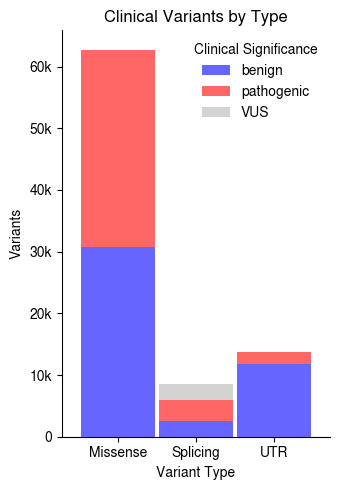

In [3]:
variant_count_by_source_barplot_out = va.variant_count_by_source_barplot(show_plot=True, 
                                            figsize=(3.5, 5), 
                                            flip_axes=True, 
                                            legend_loc="upper right")
variant_count_by_source_barplot_out["fig"].savefig("manuscript/fig/clinical_variants_by_type.pdf", **utils.FIG_SAVE_KWARGS)

### Figure 1d

Superpopulation sample counts.

In [4]:
tx_ids_1kg = hs.list_haplotypes(cache = hs.DIR_DICT["haplotypes"])
tx_ids_hgdp = hs.list_haplotypes(cache = hs.DIR_DICT["HGDP_haplotypes"])
print("tx_id union",len(set(tx_ids_1kg).union(tx_ids_hgdp)))
print("tx_id intersection",len(set(tx_ids_1kg).intersection(tx_ids_hgdp)))

Found haplotypes of 47329 transcripts in: '/home/schilder/.cache/ensembl_rest/haplotypes/'
Found haplotypes of 85520 transcripts in: '/home/schilder/projects/data/Human_Genome_Diversity_Project/haplosaurus/'
tx_id union 92863
tx_id intersection 39986


Import haplotype sequences from Haplosaurus. 
These are the wild-type sequences for each protein that occurs within the 1000 Genomes Project.






In [5]:
proteins_df = pg.merge_resources(rows_per_id=None)

haplotypes_hgdp = hs.get_haplotypes(cache = hs.DIR_DICT["HGDP_haplotypes"],
                                     tx_ids=proteins_df['ENST'].unique(), 
                                    cache_only = True) 
haplotypes_1kg = hs.get_haplotypes(cache = hs.DIR_DICT["haplotypes"],
                                    tx_ids=proteins_df['ENST'].unique(), 
                                    cache_only = True) 
haplotypes = hs.merge_haplotype_datasets({"1KG":haplotypes_1kg, "HGDP":haplotypes_hgdp},
                                         tx_id_method = "union",
                                         use_deepcopy = True) 

Found haplotypes of 85520 transcripts in: '/home/schilder/projects/data/Human_Genome_Diversity_Project/haplosaurus/'


Getting haplotypes:   0%|          | 0/2652 [00:00<?, ?it/s]

Found haplotypes of 47329 transcripts in: '/home/schilder/.cache/ensembl_rest/haplotypes/'


Getting haplotypes:   0%|          | 0/2503 [00:00<?, ?it/s]

Using deepcopy
Merging 2847 tx_ids using union


Merging haplotype datasets:   0%|          | 0/2 [00:00<?, ?it/s]

Merging haplotypes:   0%|          | 0/2652 [00:00<?, ?it/s]

Getting haplotype names:   0%|          | 0/2847 [00:00<?, ?it/s]

Merged 132721 haplotypes across 2847 tx_ids.


Extracting sample IDs:   0%|          | 0/2847 [00:00<?, ?it/s]

0 samples are missing superpopulation metadata


<string>:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


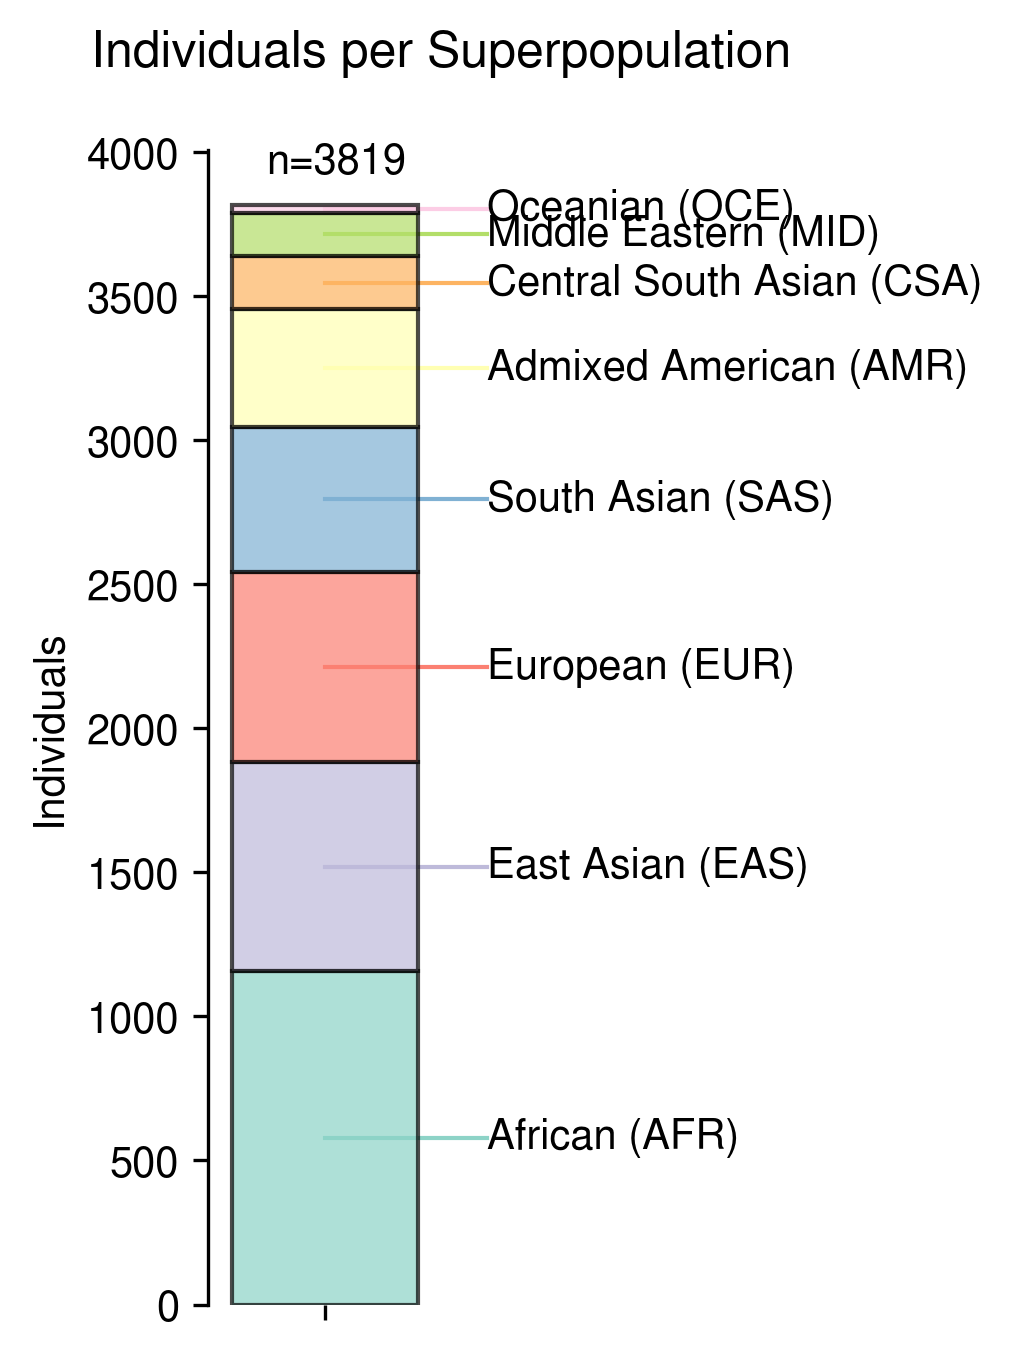

In [11]:
plot_superpopulation_bar_out = hs.plot_superpopulation_bar(haplotypes=haplotypes)
plot_superpopulation_bar_out["fig"].savefig("manuscript/fig/superpopulation_bar.pdf", **utils.FIG_SAVE_KWARGS)

### Figure 1e

WT variants per haplotype: ESM

Plot the number of haplotypes per protein, as well as the number of WT variants per haplotype.

Adding reference haplotype:   0%|          | 0/2847 [00:00<?, ?it/s]

Getting haplotype sequences:   0%|          | 0/2847 [00:00<?, ?it/s]

Getting haplotype names:   0%|          | 0/2847 [00:00<?, ?it/s]

Converting haplotypes to dataframe:   0%|          | 0/2847 [00:00<?, ?it/s]

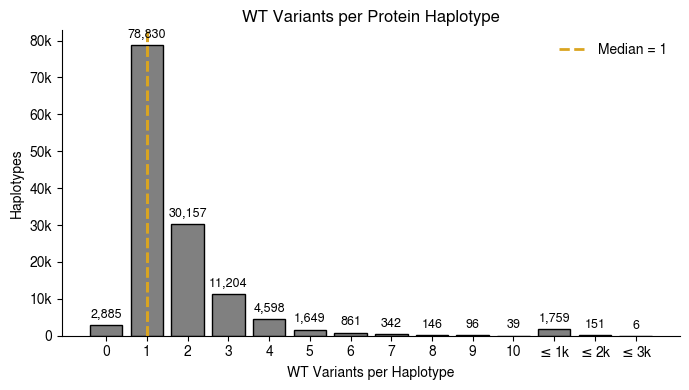

median number of variants per haplotype: 1.0
mean number of variants per haplotype: 7.615349261243342


In [52]:
n_variants_histogram_protein = hs.plot_haplotypes_summary(haplotypes, 
                                   show_median=True,
                                   show_mean=False,
                                   figsize=(7, 4),
                                    gridspec_kw={'width_ratios': [0, 1]},
                                    bin_size=1000, 
                                     title=("Haplotypes per Protein", "WT Variants per Protein Haplotype"),
                                #    count_indels_as_one=True,
                                   show_subplots=(False, True),
                                   save_path="manuscript/fig/wt_variants_per_haplotype_protein.pdf")

print(f"median number of variants per haplotype: {n_variants_histogram_protein['data']['hap_df']['edits'].median()}")
print(f"mean number of variants per haplotype: {n_variants_histogram_protein['data']['hap_df']['edits'].mean()}")

In [51]:
# hap_df = hs.haplotypes_to_df(haplotypes).reset_index()
# hap_df = utils.add_edits(hap_df)
# n_variants_histogram_protein = va.plot_n_variants_histogram(hap_df, 
#                                                             x="edits", 
#                                                             title="WT Variants per Protein Haplotype",
#                                                             save_path="manuscript/fig/wt_variants_per_haplotype_protein.pdf", 
#                                                             figsize=(7, 4),
#                                                             show_plot=True)

### Figure 1f

Number of WT variants per haplotype: SpliceAI

In [24]:
spliceai_n_variants_path = "results/data/spliceai_n_variants_df.parquet"
force = False

if not os.path.exists(spliceai_n_variants_path) or force:
    # NOTE: Must first activate a conda environment with genvarloader installed
    import src.GVL as GVL
    # List of GVL zip file paths
    gvl_zips = [
        os.path.expanduser("~/projects/data/1000_Genomes_on_GRCh38/SpliceAI/data/gvl_1kgp/1kgp_gvl.zip"),
        os.path.expanduser("~/projects/data/1000_Genomes_on_GRCh38/SpliceAI/data/gvl_hgdp/hgdp_gvl.zip"),
    ] 
    # Functionalized workflow
    datasets = GVL.load_gvl_datasets(gvl_zips)
    n_variants_spliceai = GVL.get_n_variants_df(datasets)
    n_variants_spliceai.to_parquet(spliceai_n_variants_path)
else:
    n_variants_spliceai = pd.read_parquet(spliceai_n_variants_path)

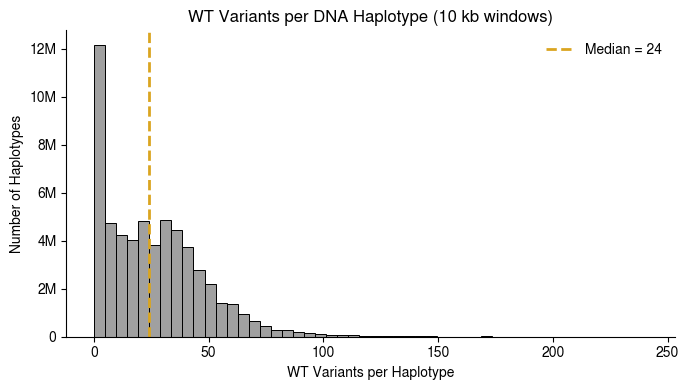

In [49]:
n_variants_histogram_spliceai = va.plot_n_variants_histogram(n_variants_spliceai, 
                                                            title="WT Variants per DNA Haplotype (10 kb windows)",
                                                            save_path="manuscript/fig/wt_variants_per_haplotype_spliceai.pdf", 
                                                            figsize=(7, 4),
                                                            show_plot=True)

### Figure 1g

WT variants per haplotype: Flashzoi

In [26]:
flashzoi_n_variants_path = "results/data/flashzoi_n_variants_df.parquet"
force = False

if not os.path.exists(flashzoi_n_variants_path) or force:
    # NOTE: Must first activate a conda environment with genvarloader installed
    import src.GVL as GVL
    import glob
    gvl_zips = glob.glob(os.path.expanduser("~/projects/data/1000_Genomes_on_GRCh38/clinvar_utr_snv/*.gvl"))

    datasets = GVL.load_gvl_datasets(gvl_zips)
    n_variants_flashzoi = GVL.get_n_variants_df(datasets)
    n_variants_flashzoi.to_parquet(flashzoi_n_variants_path)
else:
    n_variants_flashzoi = pd.read_parquet(flashzoi_n_variants_path)

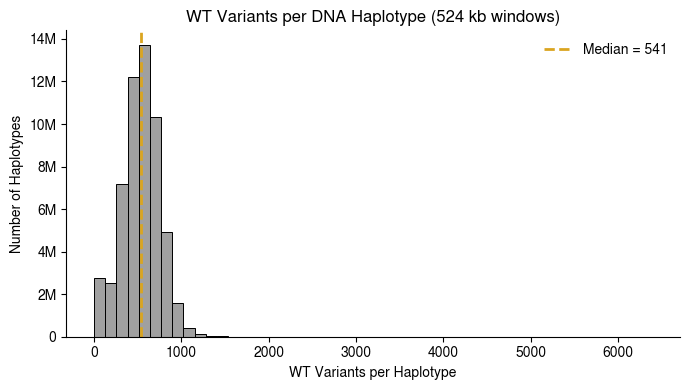

In [50]:
n_variants_histogram_flashzoi = va.plot_n_variants_histogram(n_variants_flashzoi, 
                                                            title="WT Variants per DNA Haplotype (524 kb windows)",
                                                            save_path="manuscript/fig/wt_variants_per_haplotype_flashzoi.pdf", 
                                                            figsize=(7, 4),
                                                            show_plot=True)

## Figure 2

### Figure 2a

In [53]:
# Focus on one model for the main plots
model_name = "esm2_t33_650M_UR50D"

force = False
tmp_vep_path = f"./results/data/vep_df_{model_name}.parquet"
if os.path.exists(tmp_vep_path) and not force:
    print(f"Loading {tmp_vep_path}")
    vep_df = pd.read_parquet(tmp_vep_path)
else:
    vep_files = va.list_vep_files(model_location=model_name, 
                                  as_df=True)
    vep_df = va.merge_vep(add_metadata=True, 
                          scoring_strategy=["masked-marginals"], 
                          vep_files=vep_files.loc[vep_files['model_location']==model_name]
                               )
    print(f"Saving {tmp_vep_path}")
    vep_df.to_parquet(tmp_vep_path)

vep_df.head() 

Loading ./results/data/vep_df_esm2_t33_650M_UR50D.parquet


,haplotype,protein,protein_sequence,mutant,mutated_sequence,DMS_bin_score,VEP,scoring_strategy,is_ref,model_location,variant_set,ENSP,ENST,mutant_in_haplotype,site,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,#Uploaded_variation,Location,Allele,Gene,Feature,Feature_type,Consequence,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,IMPACT,DISTANCE,STRAND,FLAGS,REFSEQ_MATCH,REFSEQ_OFFSET,GIVEN_REF,USED_REF,BAM_EDIT,HGVSc,HGVSp,HGVS_OFFSET,AF_ESP,AF_EXAC,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNSIGCONF,CLNVC,CLNVCSO,GENEINFO,MC,ORIGIN,RS,AF_TGP,CLNVI,CLNDISDBINCL,CLNDNINCL,CLNSIGINCL,EVH_epistatic,EVH_independent,ESM1V_ensemble_mean,Tranception,model_count,clinsig
0,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,L1045F,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Benign,-3.635069,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,NP_000229.1:L1045F,7,150947347,67473,G,A,.,PASS,67473,7:150947347,A,3757,NM_000238.4,Transcript,missense_variant,3541,3133,1045,L/F,Ctc/Ttc,-,MODERATE,-,-1,-,-,-,G,G,-,NM_000238.4:c.3133C>T,NP_000229.1:p.Leu1045Phe,-,NaN,0.00000,78369,"MedGen:CN230736|EFO:EFO_0004269,Human_Phenotyp...",Cardiovascular_phenotype|Cardiac_arrhythmia|Co...,NC_000007.14:g.150947347G>A,"criteria_provided,_multiple_submitters,_no_con...",Benign,NaN,single_nucleotide_variant,SO:0001483,KCNH2:3757,SO:0001583|missense_variant,1,199473025,NaN,ClinGen:CA008015,None,None,None,NaN,NaN,-6.731237,-0.021689,6,benign
1,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,D1003Y,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Pathogenic,-1.670645,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,NP_000229.1:D1003Y,7,150947473,200516,C,A,.,PASS,200516,7:150947473,A,3757,NM_000238.4,Transcript,missense_variant,3415,3007,1003,D/Y,Gac/Tac,-,MODERATE,-,-1,-,-,-,C,C,-,NM_000238.4:c.3007G>T,NP_000229.1:p.Asp1003Tyr,-,NaN,NaN,197155,MedGen:CN517202,not_provided,NC_000007.14:g.150947473C>A,"criteria_provided,_single_submitter",Likely_pathogenic,NaN,single_nucleotide_variant,SO:0001483,KCNH2:3757,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,794728402,NaN,ClinGen:CA007791,None,None,None,NaN,NaN,-2.509515,-0.039753,6,likely_path
2,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,N996I,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Pathogenic,-4.619007,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,NP_000229.1:N996I,7,150947493,67458,T,A,.,PASS,67458,7:150947493,A,3757,NM_000238.4,Transcript,missense_variant,3395,2987,996,N/I,aAc/aTc,-,MODERATE,-,-1,-,-,-,T,T,-,NM_000238.4:c.2987A>T,NP_000229.1:p.Asn996Ile,-,NaN,NaN,78354,"MONDO:MONDO:0019171,MedGen:C1141890,OMIM:PS192...",Congenital_long_QT_syndrome|not_provided|Long_...,NC_000007.14:g.150947493T>A,"criteria_provided,_multiple_submitters,_no_con...",Pathogenic/Likely_pathogenic,NaN,single_nucleotide_variant,SO:0001483,KCNH2:3757,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,199473018,NaN,ClinGen:CA007728|UniProtKB:Q12809#VAR_068285,None,None,None,NaN,NaN,-5.869637,-0.057342,6,likely_path
3,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,E978K,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Benign,-0.514701,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,NP_000229.1:E978K,7,150947639,67453,C,T,.,PASS,67453,7:150947639,T,3757,NM_000238.4,Transcript,missense_variant,3340,2932,978,E/K,Gag/Aag,-,MODERATE,-,-1,-,-,-,C,C,-,NM_000238.4:c.2932G>A,NP_000229.1:p.Glu978Lys,-,0.00008,0.00039,78349,"EFO:EFO_0004269,Human_Phenotype_Ontology:HP:00...",Cardiac_arrhythmia|Cardiovascular_phenotype|no...,NC_000007.14:g.150947639C>T,"criteria_provided,_multip

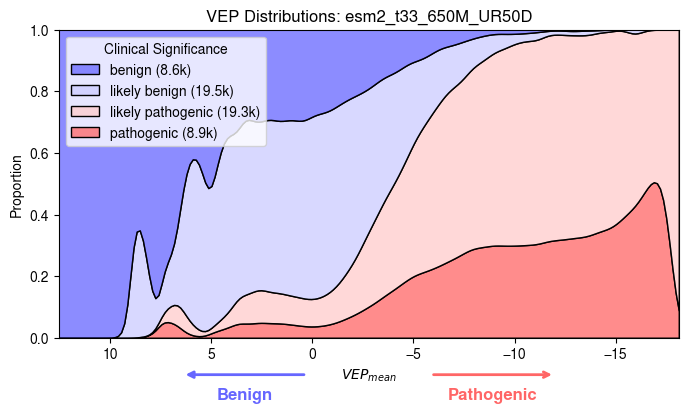

In [54]:
# vep_dist_plot_esm2 = db.plot_vep_histogram_with_arrows(vep_df,  
#                                         #   model_name=model_name,  
#                                           arrow_y= -0.35,
#                                           arrow_head_length=0.047,
#                                           arrow_length=.19,
#                                           figsize=(8, 4),
#                                           arrow_text_fontsize=9,
#                                            format_k=True,
#                                            k_precision=1,
#                                            suffix=None,
#                                            legend_loc="upper right",
#                                          title=f"VEP Distributions: {model_name}",
#                                           external_legend_annotation=False)
# vep_dist_plot_esm2["fig"].savefig("manuscript/fig/fig1h.png", **utils.FIG_SAVE_KWARGS)

import src.analysis.distributions as db
vep_dist_plot_esm2  = db.plot_vep_kde_with_arrows(vep_df=vep_df, 
                                                      figsize=(8, 4),
                                                      flip_xaxis=True,
                                                      format_k=True,
                                                      legend_loc="upper right",
                                                        title=f"VEP Distributions: {model_name}",
                                                        save_path="manuscript/fig/vep_kde_esm2.pdf")

In [55]:
uniprot_ids = {"BRCA1":"P38398", 
               "DYPD":"Q12882"}
tx_ids = {"BRCA1":"ENST00000357654", 
          "DYPD":"ENST00000370192"}
refseq_ids = {"BRCA1": 'NP_009225.1',
              "DYPD": 'NP_000101.2'}

# Get specific instance of the protein
target_gene = "BRCA1" # DYPD
uniprot_id = uniprot_ids[target_gene]
refseq_id = refseq_ids[target_gene]
tx_id = tx_ids[target_gene] 

In [56]:

#### Import directly from AlphaFoldDB ####
# structure = cf.import_mmcif(protein_id = uniprot_id)[0]
# contact_map = cf.get_contact_map(structure, 
#                                  max_distance=8.0, 
#                                  continuous=True, 
#                                  return_distance_map=True )


#### Import from local AlphaFold files that I generated myself ####
pdb_files = cf.search_files(base_dir =  os.path.expanduser("~/projects/data/colabfold"),
                            tx_id = tx_id,
                            subdir = "af2_sameMSA",
                            suffix = ".pdb*",
                            model_number = 1,
                            ref_only = True) 

# contact_map_ref = cf.import_contact_maps(pdb_files,
#                                         return_distance_map=True,
#                                         continuous=True,
#                                         as_dict=False)  


distance_map_ref = cf.import_contact_maps(pdb_files,
                                            return_raw_distance_map=True,
                                            as_dict=False)  


1 PDB files found


100%|██████████| 1/1 [00:00<00:00,  4.28it/s]


Contact enrichment for BRCA1 WT vs. Clinical variant interactions.

In [57]:
contact_map_binary_ref = cf.import_contact_maps(pdb_files,
                                                max_distance=8.0, 
                                                continuous=False, 
                                                return_distance_map=False,
                                                as_dict=False ) 

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00,  4.61it/s]


In [58]:
model_name = "esm2_t33_650M_UR50D"
force = False

if 'vep_files' not in globals() or force:
    vep_files = va.list_vep_files(model_location=model_name, 
                                  as_df=True)

vep_prot = va.merge_vep(
    scoring_strategy=["masked-marginals"],
    vep_files=vep_files.loc[(vep_files['model_location']==model_name) & 
                            (vep_files['protein']==refseq_id)]
    )
print("n_haplotypes: ", vep_prot["haplotype"].nunique())
vep_prot["HGNC"] = vep_prot["GENEINFO"].str.split(":").str[0]  


No save_dir provided, using: /home/schilder/projects/data/1KG/vep


Finding VEP files:   0%|          | 0/1 [00:00<?, ?it/s]

Found 202449 parquet files in /home/schilder/projects/data/1KG/vep
Unique values:
>> model_location: 1
scoring_strategy: 3
variant_set: 1
haplotype: 111378
protein: 2250
No save_dir provided, using: /home/schilder/projects/data/1KG/vep
Found 144 masked-marginals parquet files


Reading files:   0%|          | 0/144 [00:00<?, ?it/s]

Concatenating VEP dataframes
Loading ==> /home/schilder/projects/data/haplosaurus/tx_id_map.pkl


Loading '/home/schilder/projects/data/haplosaurus/tx_id_map.pkl': 100%|██████████| 1.70M/1.70M [00:00<00:00, 4.57GB/s]


VEP dataframe shape: (65664, 73)
n_haplotypes:  144


Use ridge regression to find WT-Clinical variant interactions.

In [59]:
wtvariants_to_vep_linear_model_out = ab.wtvariants_to_vep_linear_model(vep_df=vep_prot,
                                                                       alpha=1)  
utils.save_pickle(wtvariants_to_vep_linear_model_out, 
        f"results/data/wtvariants_to_vep_linear_model_out_{target_gene}.pkl")
ridge_df = wtvariants_to_vep_linear_model_out["interaction_df"]

vep_matrix shape:  (144, 456)
wt_matrix shape:  (144, 132)
Dropped 1 haplotypes due to NaNs in input or target matrices.
Saving ==> results/data/wtvariants_to_vep_linear_model_out_BRCA1.pkl


### Figure 2b

Toy schematic of variant sensitization maps methodology (ridge regression method).

/home/schilder/.conda/envs/esm2/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/schilder/.conda/envs/esm2/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


Found 10x9 submatrix at rows 0-10, cols 122-131 with 21.1% 1s


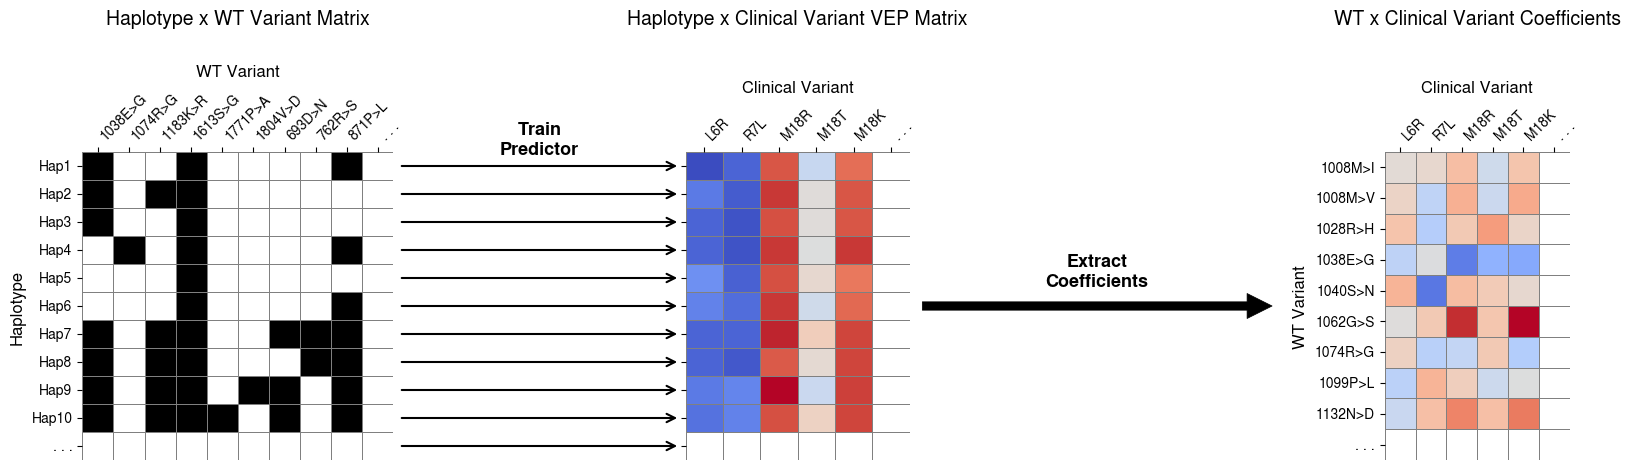

<Figure size 640x480 with 0 Axes>

In [72]:
surrogate_model_schematic = ab.plot_variant_sensitization_schematic(wtvariants_to_vep_linear_model_out,    
                                        show_haplotype_labels_plot3=True,
                                            show_text_labels=(False, False, False),
                                             noise_scale=0.40,
                                                n_clinical_variants=5,
                                                n_haplotypes=10,
                                                n_wt_variants=9,
                                                title_y_position=1.2,
                                                include_haplotype_suffix=False,
                                                include_any_1_col=True, 
                                                include_any_1_row=False,
                                                grey_box_left_extension=0.23, 
                                                grey_box_top_extension=0.25, 
                                                add_grey_box=False,   
                                                rotate_x_labels=True, 
                                                heatmap_aspect=(.9, .75, 1),
                                                replace_haplotype_prefix=True)
surrogate_model_schematic['fig'].savefig("manuscript/fig/surrogate_model_schematic.pdf", **utils.FIG_SAVE_KWARGS)
surrogate_model_schematic['fig']

### Figure 2B

BRCA1 AlphaFold contact map (reference sequence).

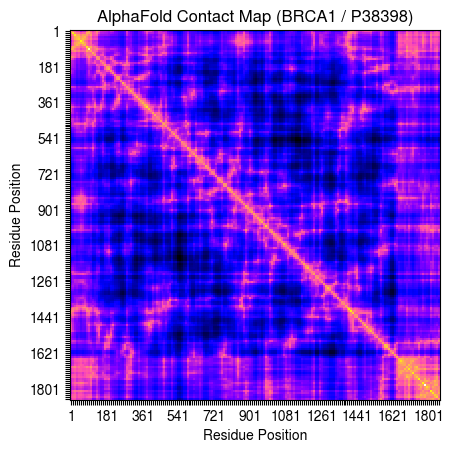

In [73]:
plot_contact_map_out = cf.plot_contact_map(contact_map=distance_map_ref, 
                            title=f"AlphaFold Contact Map ({target_gene} / {uniprot_id})",  
                            bin_size=10,   
                            cmap="gnuplot2_r", 
                            pow=1/2, 
                            agg_func=np.nanmax)

distance_map_ref_binned = plot_contact_map_out["data"]["contact_map_binned"]
distance_map_ref_binned = cf.mc.expand_matrix(distance_map_ref_binned, 
                                      target_size=distance_map_ref.shape) 
plot_contact_map_out['fig'].savefig("manuscript/fig/brca1_distance_map.pdf", **utils.FIG_SAVE_KWARGS)

In [74]:
#### Import from local AlphaFold files that I generated myself ####
pdb_files = cf.search_files(base_dir =  os.path.expanduser("~/projects/data/colabfold"),
                            tx_id = tx_id,
                            subdir = "af2_sameMSA",
                            suffix = ".pdb*",
                            model_number = 1 ) 

contact_maps = cf.import_contact_maps(pdb_files,
                                        return_raw_distance_map=True
                                        )  

126 PDB files found


100%|██████████| 126/126 [00:33<00:00,  3.75it/s]


In [76]:
top_wt_variants = ridge_df.groupby("wt_variant")["interaction_strength"].mean().sort_values(ascending=False)
contact_maps_wt = {k:v for k,v in contact_maps.items() if top_wt_variants.index[0].replace(">","_") in k or k==cf.get_ref_key(contact_maps)}
top_wt_variants.head()

wt_variant
1710G>R    0.022135
1706G>A    0.018714
1783M>T    0.017807
616delS    0.016924
1652M>I    0.013827
Name: interaction_strength, dtype: float64

<string>:163: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


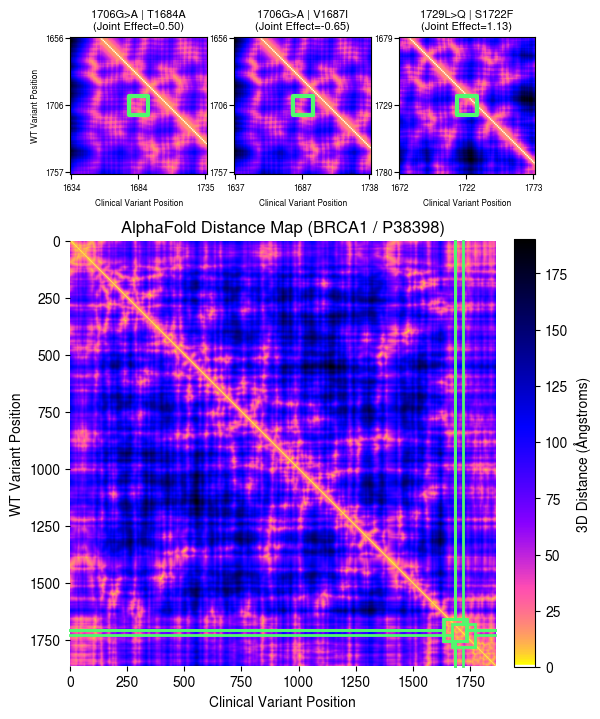

In [95]:
import matplotlib
distance_map_zooms = cf.plot_contact_map_and_zooms(
    contact_maps_wt,
    ridge_df, 
    highlight_colors="#50f96e",
    palette="gnuplot2_r",
    main_plot_above=-1,
    linewidth=2,
    title=f"AlphaFold Distance Map ({target_gene} / {uniprot_id})",
    max_highlights=3,
    highlight_size=100,
    zoom_nrows = 1,
    zoom_ncols=None,
    zoom_subplot_size = 2,
    main_nrows = 2,
    main_ncols = 2,
    pow=1/2,
     zoom_show_ticks=True,  # Enable tick labels
    zoom_tick_density=3,  # Show 5 ticks per axis
    # zoom_rect_white_outline=True,
    # zoom_rect_white_outline_width=4,
    main_padding=0.001,
    save_path="manuscript/fig/brca1_distance_map_zooms.pdf"
)

### Figure 2C

BRCA1 sensitization map (aligned) +  BRCA1 AlphaFold contact map (reference sequence).

Choose a threshold for the interaction strength and compute the contact enrichment at that specific threshold.  
Then plot the contact map and the sensitization map.

In [96]:
interaction_threshold = 0.05

top_interactions = ridge_df.loc[ridge_df["interaction_strength"] > interaction_threshold]    

ridge_enrichment_at_threshold = ab.compute_enrichment_vs_threshold(
    outlier_df=ridge_df,
    contact_map_binary=contact_map_binary_ref, 
    thresholds=[interaction_threshold],
    linear_sampling=False,  
    interaction_col="interaction_strength"
)

print()
print(f"Number of top interactions: {top_interactions.shape[0]}" + \
      f" ({top_interactions.shape[0] / ridge_df.shape[0]*100:.2f}% of all WT-Clinical variant pairs)")
print(f"Enrichment at threshold {interaction_threshold}: {ridge_enrichment_at_threshold['enrichment'].values[0]:.2f}x" )

100%|██████████| 1/1 [00:00<00:00, 21.67it/s]


Number of top interactions: 518 (0.86% of all WT-Clinical variant pairs)
Enrichment at threshold 0.05: 58.58x


In [97]:
vep_prot.loc[(vep_prot["site"].isin(top_interactions["site"].head(10)))].groupby("site")["VEP"].mean().sort_values(ascending=False)
# vep_prot.loc[vep_prot["site"]=="NP_009225.1:V1687I"]["VEP"].hist(bins=50)

site
NP_009225.1:Y1853H     0.466824
NP_009225.1:Y179C     -0.623751
NP_009225.1:P1859R    -0.997451
NP_009225.1:V1687I    -2.108766
NP_009225.1:V1653L    -5.326225
NP_009225.1:T1684A    -6.312315
NP_009225.1:S1722F    -9.086795
NP_009225.1:L1839S   -10.287786
NP_009225.1:V1687G   -13.562093
NP_009225.1:Q1721P   -14.548687
Name: VEP, dtype: float64

In [98]:
top_interactions.head(20)

,wt_variant,site,interaction_strength,interaction_strength_signed,outlier_type,n_haplotypes,interaction_strength_weighted,clinical_variant,wt_position,wt_REF,wt_ALT,clinical_position,clinical_REF,clinical_ALT
25444,1729L>Q,NP_009225.1:S1722F,1.132624,1.132624,more benign,1,1.064248,S1722F,1729,L,Q,1722,S,F
24133,1706G>A,NP_009225.1:V1687I,0.651702,-0.651702,more pathogenic,1,0.807280,V1687I,1706,G,A,1687,V,I
24100,1706G>A,NP_009225.1:T1684A,0.503096,0.503096,more benign,1,0.709293,T1684A,1706,G,A,1684,T,A
24130,1706G>A,NP_009225.1:V1653L,0.395925,0.395925,more benign,1,0.629226,V1653L,1706,G,A,1653,V,L
24922,1720T>A,NP_009225.1:Q1721P,0.385628,0.385628,more benign,1,0.620990,Q1721P,1720,T,A,1721,Q,P
24132,1706G>A,NP_009225.1:V1687G,0.377944,0.377944,more benign,1,0.614772,V1687G,1706,G,A,1687,V,G
29175,186S>Y,NP_009225.1:Y179C,0.367613,0.367613,more benign,1,0.606311,Y179C,186,S,Y,179,Y,C
26205,1783M>T,NP_009225.1:L1839S,0.343707,0.343707,more benign,1,0.586266,L1839S,1783,M,T,1839,L,S
28721,1856P>T,NP_009225.1:Y1853H,0.343572,0.343572,more benign,1,0.586150,Y1853H,1856,P,T,1853,Y,H
28550,1856P>T,NP_009225.1:P1859R,0.302587,-0.302587,more pathogenic,1,0.550079,P1859R,1856,P,T,1859,P,R


Adding rectangles


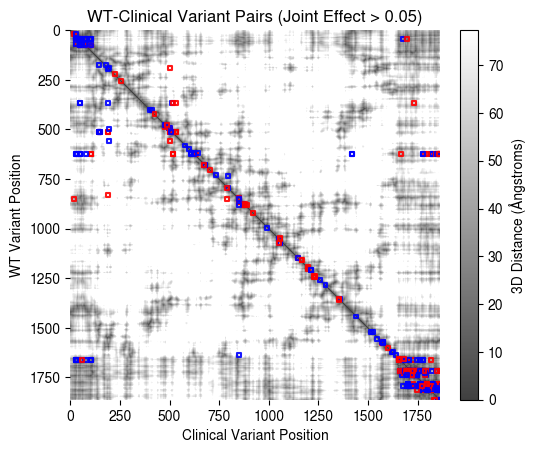

In [112]:
fig2c = ab.plot_contact_and_sensitization_maps(
    contact_map_binned=distance_map_ref,
    # contact_map_binned=(distance_map_ref_binned >= 8).astype(int),
    outlier_sig=top_interactions, 
    cmap=("gnuplot2_r", "binary_r"),
    heatmap_alpha=0.75,
     rectangles_alpha=.9,
     rectangles_linewidth=1.5,
    masking_percentile2=50,
    invert_mask=True,
    rectangles_cmap={"more pathogenic": "red", "more benign": "blue", "neutral": "grey"},
    title=rf"WT-Clinical Variant Pairs (Joint Effect > 0.05)",# +"\n"+rf"(Interaction Strength $\geq$ {interaction_threshold})",
    show_plot=(False, True),
    # figsize=(10, 10)
)

fig2c["fig"]["subplot2"].savefig("manuscript/fig/brca1_sensitization_map.pdf", **utils.FIG_SAVE_KWARGS)

### Figure 2D

Contact enrichment: ridge regression method

In [31]:
ridge_enrichment = ab.compute_enrichment_vs_threshold(
    outlier_df=ridge_df,
    contact_map_binary=contact_map_binary_ref, 
    num_thresholds=50,
    linear_sampling=False,  
    interaction_col="interaction_strength"
)

100%|██████████| 50/50 [00:02<00:00, 18.05it/s]


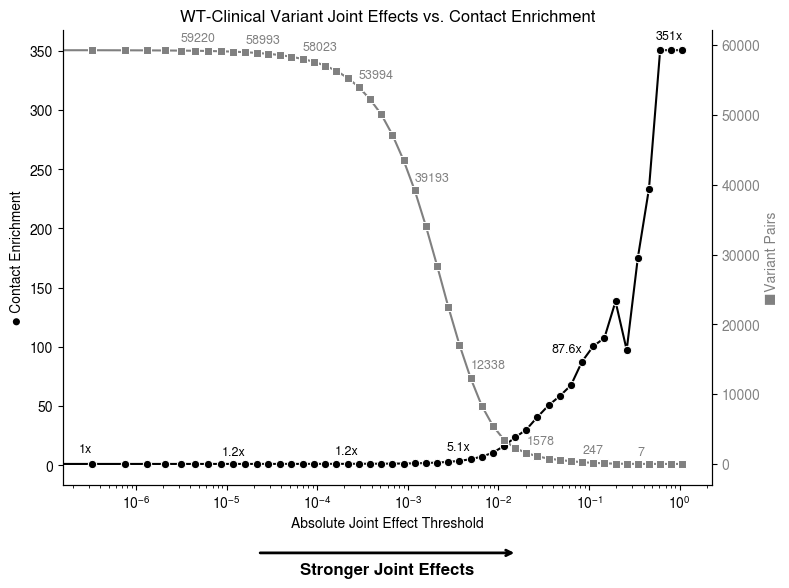

In [32]:
fig2d = ab.plot_enrichment_vs_interactions(ridge_enrichment,   
                                           figsize=(8, 6),
                                        log_x_axis=True, 
                                        # log_y1_axis=True,
                                        # log_y2_axis=True,
                                        y1_first_label=True,
                                        y1_last_label=True,
                                        y2_first_label=True,
                                        y2_last_label=True, )
fig2d["fig"].savefig("manuscript/fig/brca1_contact_map_enrichment.pdf", **utils.FIG_SAVE_KWARGS)

### Figure 2E

Mean interaction strength per clinical variant.

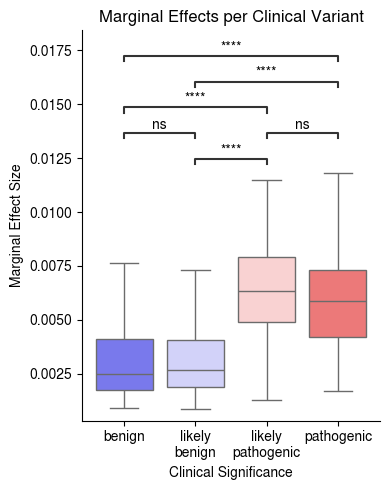

In [34]:
fig2e = ab.plot_clinsig_interaction_strength(
    ridge_df, vep_prot, 
    title="Marginal Effects per Clinical Variant",
    xlabel="Clinical Significance",
    ylabel="Marginal Effect Size", 
    text_format="star",
    figsize=(4, 5),
)
fig2e["fig"].savefig("manuscript/fig/brca1_marginal_effects_per_clinical_variant.pdf", **utils.FIG_SAVE_KWARGS)

### Figure 2F

Interaction strength vs. Angstroms.

In [175]:
ridge_df.loc[ridge_df["interaction_strength"] > 0.01]

,wt_variant,site,interaction_strength,interaction_strength_signed,outlier_type,n_haplotypes,interaction_strength_weighted,clinical_variant,wt_position,wt_REF,wt_ALT,clinical_position,clinical_REF,clinical_ALT,position_distance,Angstroms,is_contact,clinical_variant_fmt,protein,wt_p.position,wt_p.REF,wt_p.ALT,wt_HGVSp
25444,1729L>Q,NP_009225.1:S1722F,1.132624,1.132624,more benign,1,1.064248,S1722F,1729,L,Q,1722,S,F,7,5.362032,True,1722S>F,NP_009225.1,1729,L,Q,NP_009225.1:p.Leu1729Gln
24133,1706G>A,NP_009225.1:V1687I,0.651702,-0.651702,more pathogenic,1,0.807280,V1687I,1706,G,A,1687,V,I,19,6.155341,True,1687V>I,NP_009225.1,1706,G,A,NP_009225.1:p.Gly1706Ala
24100,1706G>A,NP_009225.1:T1684A,0.503096,0.503096,more benign,1,0.709293,T1684A,1706,G,A,1684,T,A,22,8.582898,False,1684T>A,NP_009225.1,1706,G,A,NP_009225.1:p.Gly1706Ala
24130,1706G>A,NP_009225.1:V1653L,0.395925,0.395925,more benign,1,0.629226,V1653L,1706,G,A,1653,V,L,53,9.117680,False,1653V>L,NP_009225.1,1706,G,A,NP_009225.1:p.Gly1706Ala
24922,1720T>A,NP_009225.1:Q1721P,0.385628,0.385628,more benign,1,0.620990,Q1721P,1720,T,A,1721,Q,P,1,3.853017,True,1721Q>P,NP_009225.1,1720,T,A,NP_009225.1:p.Thr1720Ala
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57367,871P>L,NP_009225.1:S1841R,0.010012,-0.010012,more pathogenic,89,0.943976,S1841R,871,P,L,1841,S,R,970,58.378235,False,1841S>R,NP_009225.1,871,P,L,NP_009225.1:p.Pro871Leu
47583,669M>T,NP_009225.1:H41Y,0.010011,-0.010011,more pathogenic,1,0.100055,H41Y,669,M,T,41,H,Y,628,76.621727,False,41H>Y,NP_009225.1,669,M,T,NP_009225.1:p.Met669Thr
35531,356Q>R,NP_009225.1:V1665G,0.010010,0.010010,more benign,6,0.245075,V1665G,356,Q,R,1665,V,G,1309,67.862282,False,1665V>G,NP_009225.1,356,Q,R,NP_009225.1:p.Gln356Arg
47637,669M>T,NP_009225.1:L1839S,0.010009,-0.010009,more pathogenic,1,0.100047,L1839S,669,M,T,1839,L,S,1170,75.010262,False,1839L>S,NP_009225.1,669,M,T,NP_009225.1:p.Met669Thr


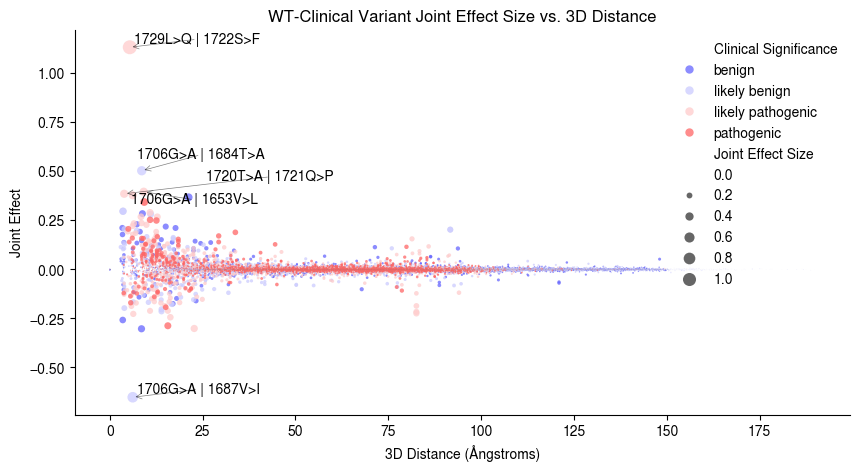

In [ ]:
# Use a lambda to pass contact_map_ref as a closure variable, avoiding the error
ridge_df["position_distance"] = (ridge_df["wt_position"] - ridge_df["clinical_position"]).abs()
ridge_df["Angstroms"] = ridge_df.apply(lambda x: ab.get_contact_score(x, distance_map_ref), axis=1)
ridge_df["is_contact"] = ridge_df.apply(lambda x: ab.get_contact_score(x, contact_map_binary_ref)==1, axis=1) 
ridge_df["clinical_variant_fmt"] = ridge_df["clinical_variant"].apply(
    lambda x: (
        f"{x[1:-1]}{x[0]}>{x[-1]}"
        if isinstance(x, str) and len(x) >= 3 and x[1:-1].isdigit()
        else x
    )
)
ridge_df['protein'] = ridge_df['site'].str.split(":").str[0]
ridge_df = utils.add_hgvsp_id(ridge_df)


fig2f = ab.plot_wt_clinical_interaction_vs_angstroms(ridge_df,#.loc[ridge_df["interaction_strength"] > 0.01], 
                                                    vep_prot, N=5, style_var=None,
                                                    adjust_text_kwargs={"min_arrow_len": 0}
)
fig2f["fig"] = utils.rasterize_figure(fig2f["fig"])
fig2f["fig"].savefig("manuscript/fig/brca1_interaction_strength_vs_angstroms.pdf", **utils.FIG_SAVE_KWARGS)

Check the baseline enrichment of all interactions with the top WT variant.

In [36]:
ridge_enrichment_at_threshold_1729LQ = ab.compute_enrichment_vs_threshold(
    outlier_df=ridge_df.loc[(ridge_df["wt_variant"]=='1729L>Q')],
    contact_map_binary=contact_map_binary_ref, 
    thresholds=[0,],
    linear_sampling=False,  
    interaction_col="interaction_strength"
)
ridge_enrichment_at_threshold_1729LQ

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00, 21.75it/s]


,observed_prob,expected_prob,binom_test,enrichment,interaction_threshold,n_interactions
0,0.008571,0.002852,"BinomTestResult(k=3, n=350, alternative='two-s...",3.004995,0,456


### Figure 2h

Create population-weighted contact maps

For each superpopulation, weight the contacts maps according to their frequency in those populations.

In [37]:
contact_maps_binary = cf.import_contact_maps(pdb_files,
                                             return_distance_map=False,
                                             continuous=False)

100%|██████████| 126/126 [00:30<00:00,  4.14it/s]


In [39]:
haplotypes_hgdp = hs.get_haplotypes(cache = hs.DIR_DICT["HGDP_haplotypes"],
                                     tx_ids=tx_id, 
                                    cache_only = True) 
haplotypes_1kg = hs.get_haplotypes(cache = hs.DIR_DICT["haplotypes"],
                                    tx_ids=tx_id, 
                                    cache_only = True) 
haplotypes = hs.merge_haplotype_datasets({"1KG":haplotypes_1kg, "HGDP":haplotypes_hgdp},
                                         tx_id_method = "intersection",
                                         use_deepcopy = True)

# Get a merged FASTA file
merged_fasta = hs.haplotypes_to_fasta(haplotypes=haplotypes,  
                        tx_ids=[tx_id],
                        save_dir=os.path.expanduser(f"~/projects/data/colabfold/{tx_id}"), 
                        split_subdir="",
                        # force=True,
                        compress=False) 

# Insert or add padding to each contact map (using the MSA as a guide)to make them all the same length
msa = bp.read_msa(merged_fasta[list(merged_fasta.keys())[0]], to_msa=True)
contact_maps_binary = cf.pad_all_contact_maps_to_msa(contact_maps=contact_maps_binary, 
                                                     msa=msa) 


Found haplotypes of 85520 transcripts in: '/home/schilder/projects/data/Human_Genome_Diversity_Project/haplosaurus/'


Getting haplotypes:   0%|          | 0/1 [00:00<?, ?it/s]

Found haplotypes of 47329 transcripts in: '/home/schilder/.cache/ensembl_rest/haplotypes/'


Getting haplotypes:   0%|          | 0/1 [00:00<?, ?it/s]

Using deepcopy
Merging 1 tx_ids using intersection


...

Merging haplotypes:   0%|          | 0/1 [00:00<?, ?it/s]

Getting haplotype names:   0%|          | 0/1 [00:00<?, ?it/s]

Merged 144 haplotypes across 1 tx_ids.


Converting haplotypes to split FASTAs:   0%|          | 0/1 [00:00<?, ?it/s]

Padding contact maps to MSA: 100%|██████████| 124/124 [00:02<00:00, 41.93it/s]


In [140]:
haps_to_samples = hs.haplotypes_to_samples(haplotypes=haplotypes,  
                                           as_df=True,
                                           add_sample_metadata=True,
                                           return_seqs=False, 
                                           add_ref=False, 
                                           duplicate_ref=False,
                                           verbose=True,
                                           )

freq_df = hs.calculate_haplotype_frequency_per_superpop(
    haps_to_samples,
    cast=True, 
    verbose=True,
    add_specificity_cols=True
)
freq_df.head()

Extracting sample IDs:   0%|          | 0/1 [00:00<?, ?it/s]

Number of samples: 3938
Number of transcripts to process: 1


Processing sample to haplotype name maps:   0%|          | 0/1 [00:00<?, ?it/s]

Converting haplotypes to DataFrame
Adding sample metadata to the DataFrame
0 samples are missing superpopulation metadata
Samples before merging: 3826
Samples after merging: 3826
Final shape: (7860, 16)
>> haplotype(s): 144
>> cohort(s): 3
>> cohort_sample(s): 3938
>> sample(s): 3826
>> population(s): 158
>> superpopulation(s): 8
>> sex(s): 2
0 samples are missing superpopulation metadata

Number of variants specific to each superpopulation:
specific_superpopulation
AFR    41
EAS    20
SAS    16
AMR    14
EUR    13
MID     8
OCE     4
CSA     2
Name: count, dtype: int64

Percentage of superpopulation-specific haplotypes: 81.94%


,haplotype,AFR_freq,AMR_freq,CSA_freq,EAS_freq,EUR_freq,MID_freq,OCE_freq,SAS_freq,AFR_samples,AMR_samples,CSA_samples,EAS_samples,EUR_samples,MID_samples,OCE_samples,SAS_samples,top_superpopulation,top_superpopulation_freq,superpopulation_count,specific_superpopulation,specific_superpopulation_samples
0,ENSP00000350283:1028R>H,0.000000,0.004902,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,AMR,0.004902,1,AMR,4.0
1,"ENSP00000350283:1038E>G,1183K>R,1613S>G",0.000000,0.000000,0.0,0.0,0.000000,0.003289,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,MID,0.003289,1,MID,1.0
2,"ENSP00000350283:1038E>G,1613S>G",0.000000,0.000000,0.0,0.0,0.003012,0.003289,0.0,0.000000,0.0,0.0,0.0,0.0,4.0,1.0,0.0,0.0,MID,0.003289,2,None,NaN
3,ENSP00000350283:1040S>N,0.000791,0.017157,0.0,0.0,0.020331,0.006579,0.0,0.000992,2.0,14.0,0.0,0.0,27.0,2.0,0.0,1.0,EUR,0.020331,5,None,NaN
4,ENSP00000350283:1099P>L,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.002976,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,SAS,0.002976,1,SAS,3.0


In [41]:
pop_contact_maps = cf.compute_population_specific_contact_maps(
    contact_maps=contact_maps,
    contact_maps_binary=contact_maps_binary,
    freq_df=freq_df, 
    superpopulation_specific_only=False,
    exclude_ref_from_weights=True,
    weight_binary_maps=True,
)
specific_maps = pop_contact_maps["specific_maps"]
specific_diff_maps = pop_contact_maps["specific_diff_maps"]
specific_binary_diff_maps = pop_contact_maps["specific_binary_diff_maps"]
specific_binary_diff_figs = pop_contact_maps["specific_binary_diff_figs"]

100%|██████████| 8/8 [00:21<00:00,  2.72s/it]


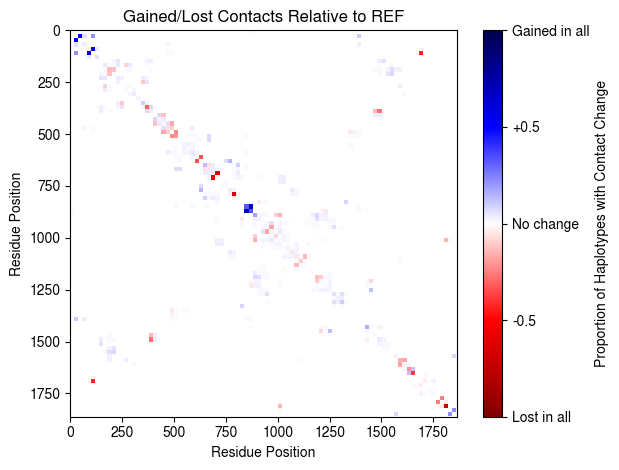

In [42]:
fig1g = cf.plot_contact_map_diff(contact_maps_binary,  
                                weights=None,
                                show_plot=True,
                                verbose=False)
fig1g["fig"].savefig("manuscript/fig/brca1_gained_lost_contact_proportions.pdf", **utils.FIG_SAVE_KWARGS)

In [43]:
print(f"{(fig1g['data']>0).sum()} ({(fig1g['data']> 0).sum() / fig1g['data'].size*100:.2f}%) of contacts were gained in at least 1 haplotype")
print(f"{(fig1g['data']<0).sum()} ({(fig1g['data']< 0).sum() / fig1g['data'].size*100:.2f}%) of contacts were lost in at least 1 haplotype")

14072 (0.41%) of contacts were gained in at least 1 haplotype
994 (0.03%) of contacts were lost in at least 1 haplotype


### Figure 2I

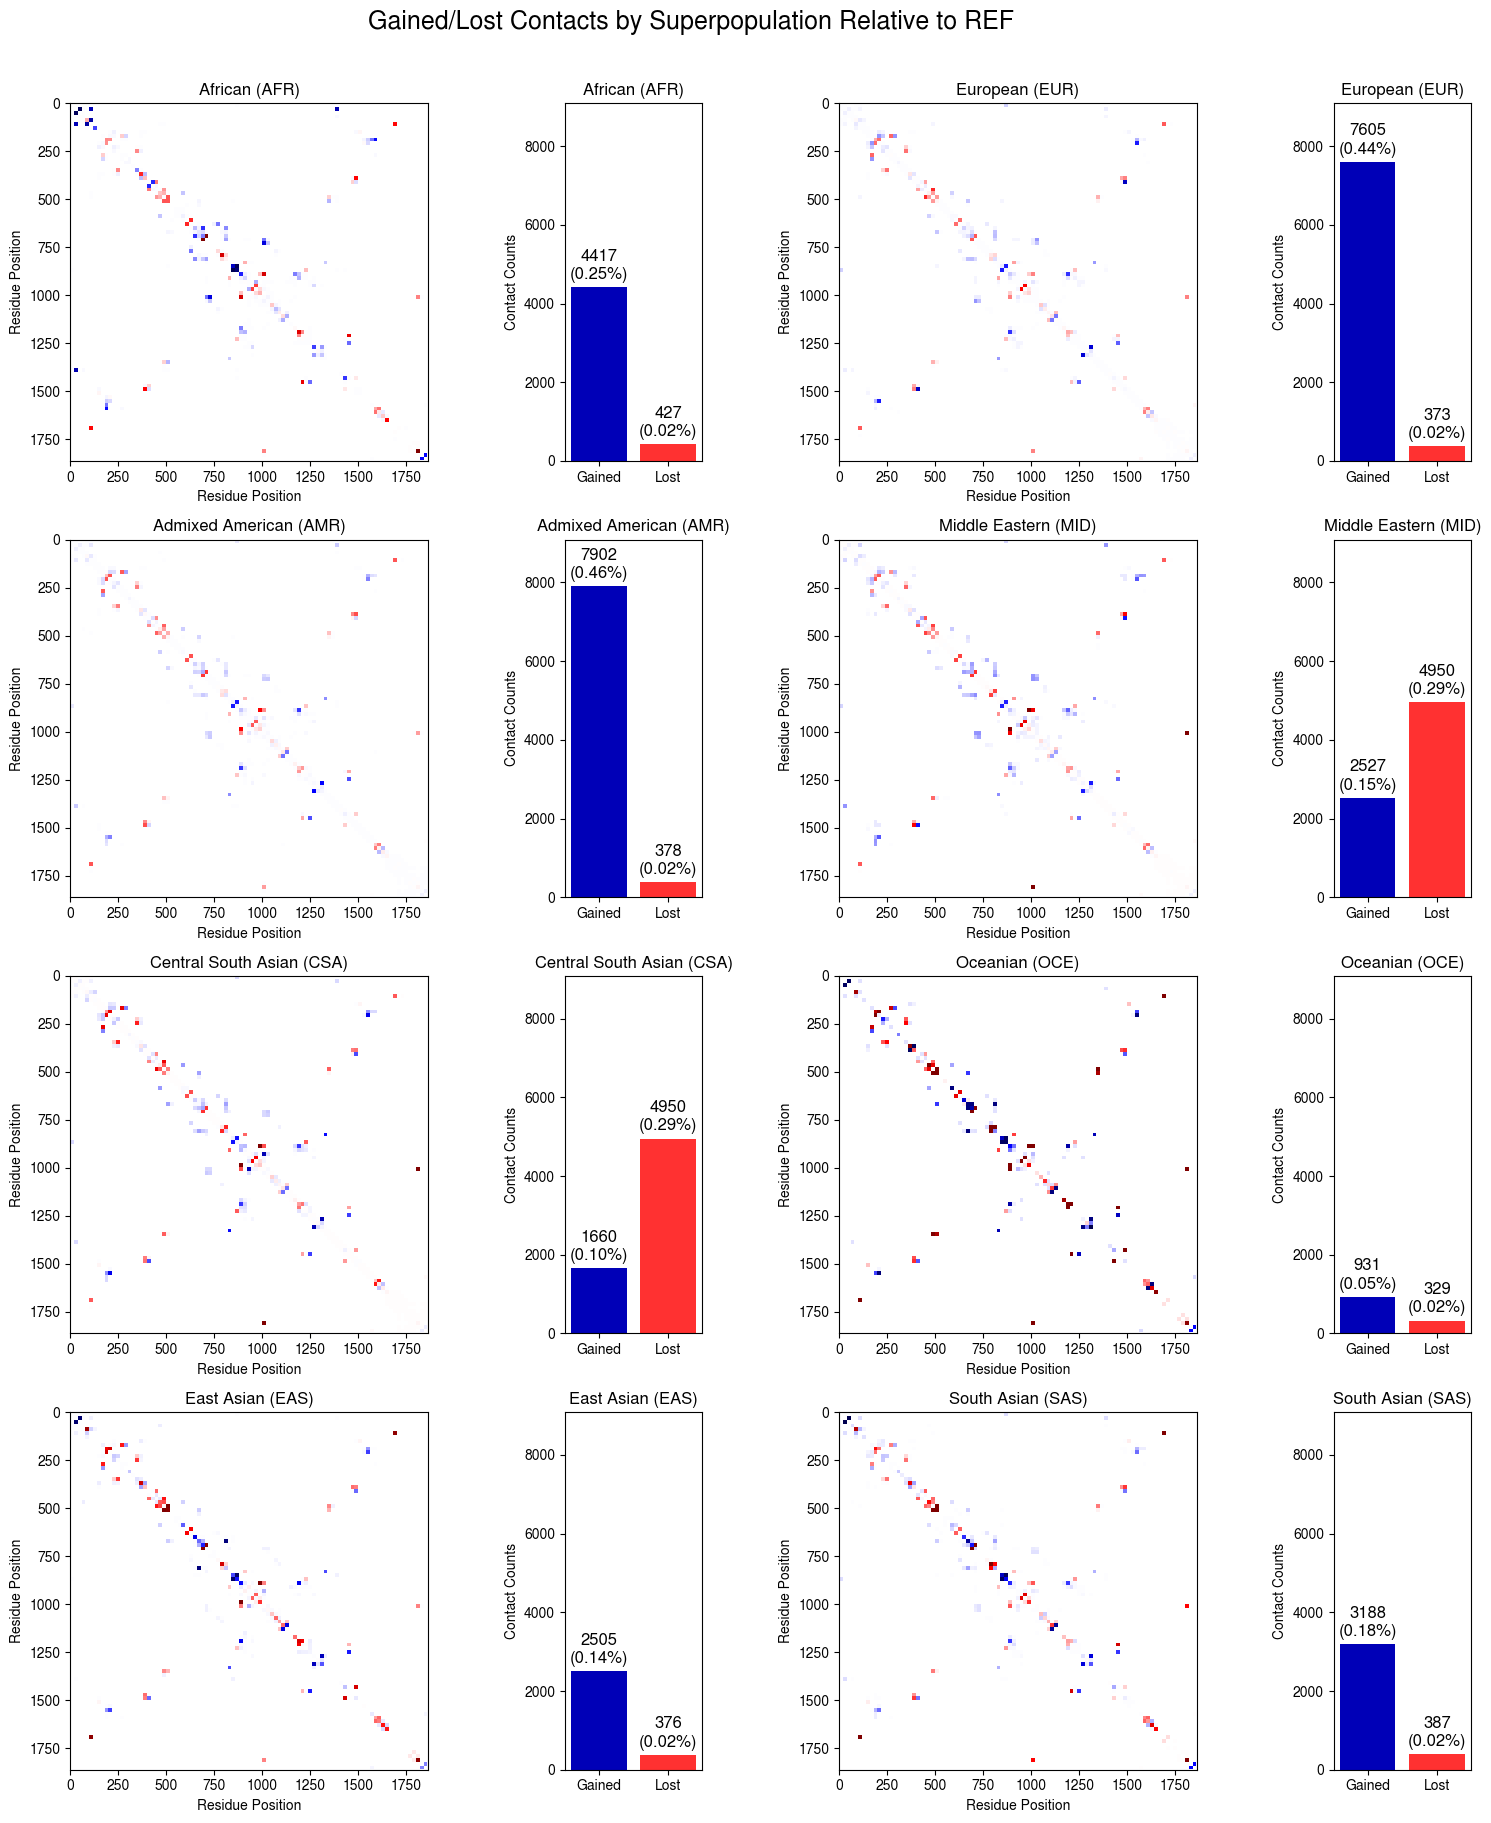

In [44]:
# %%capture

fig_superop_diff = cf.plot_superpopulation_contact_diff(
    specific_binary_diff_figs,
    specific_binary_diff_maps, 
    use_common_heatmap_scale=True,
    set_common_barplot_ylim=True,
    show_plot=False
)
fig_superop_diff['fig'].savefig("manuscript/fig/brca1_superpopulation_contact_diff.pdf", **utils.FIG_SAVE_KWARGS)

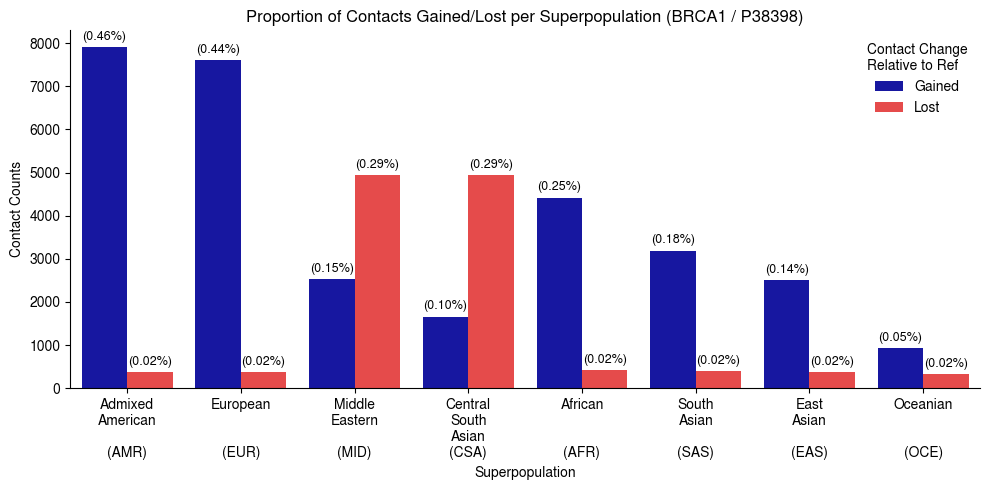

In [107]:
fig2h = cf.plot_contact_map_diff_barplot_grouped(
    bar_df=fig_superop_diff['data'],
    text_label_info=["percent"],
    group_by="superpopulation", 
    title=f"Proportion of Contacts Gained/Lost per Superpopulation ({target_gene} / {uniprot_id})",
    )
fig2h['fig'].savefig("manuscript/fig/brca1_superpopulation_contact_diff_barplot.pdf", **utils.FIG_SAVE_KWARGS)


## Figure 3

### Figure 3a

VEP distributions: SpliceAI

In [3]:
spliceai_df_path = "../data/1000_Genomes_on_GRCh38/SpliceAI/spliceai_clinvar_merged.parquet"
spliceai_df = pd.read_parquet(spliceai_df_path)

# Standardise clinical significance labels
spliceai_df["clinsig"] = spliceai_df["CLNSIG_simplified"].astype(str)
likely_mask = spliceai_df["CLNSIG"].str.lower().str.contains("likely").fillna(False)
spliceai_df.loc[likely_mask, "clinsig"] = "likely_"+spliceai_df.loc[likely_mask, "clinsig"]
spliceai_df.replace({"clinsig": {"vus": "VUS"}}, inplace=True)
spliceai_df = spliceai_df[~spliceai_df["clinsig"].isin([np.str_('nan'), 'nan'])]
spliceai_df["clinsig_simple"] = spliceai_df["clinsig"].str.replace("likely_", "")

/tmp/ipykernel_1274614/2931141490.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  likely_mask = spliceai_df["CLNSIG"].str.lower().str.contains("likely").fillna(False)


In [4]:
spliceai_df["clinsig"].unique()

array(['VUS', 'benign', 'likely_benign', 'likely_pathogenic',
       'pathogenic'], dtype=object)

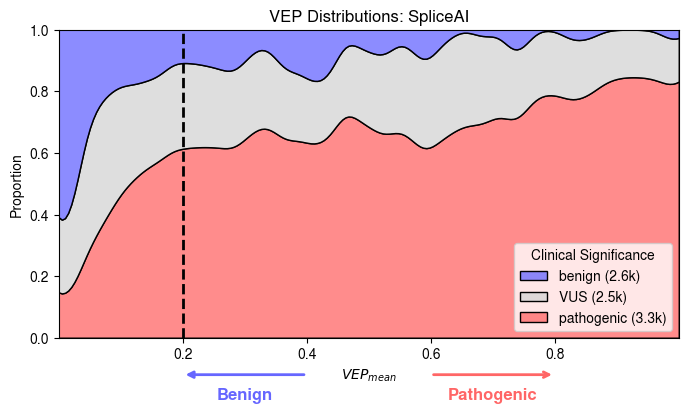

In [5]:
import src.analysis.distributions as db

vep_dist_plot_spliceai = db.plot_vep_kde_with_arrows(vep_df=spliceai_df, 
                                    figsize=(8, 4),
                                    hline_x=0.2,
                                    clinsig_col="clinsig_simple",
                                    legend_loc="upper right",
                                    format_k=True,
                                    title="VEP Distributions: SpliceAI",
                                    save_path="manuscript/fig/vep_kde_spliceai.pdf")

### Figure 3C

Dataset summary statistics.

- WT variants per person (can get from VCFs)
- WT variants per haplotype in the SpliceAI/Flashzoi regions used (can get from GVL datasets with `.n_variants`)
- Number of clinical variants per gene
- Proportion of SpliceAI VEPs that were of each score type (stratified by pathogenicity/splicegenicity)
- Proportion of Flashzoi VEPs that were of each 5' or 3' UTR

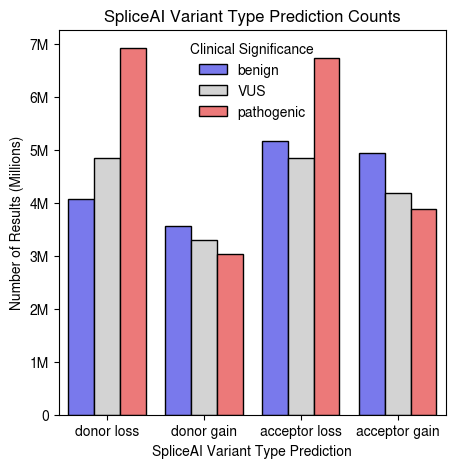

In [109]:
source_type_counts = spliceai_df.groupby(["clinsig_simple","max_delta_score_type"], observed=True).size().reset_index(name="count")
source_type_counts["max_delta_score_type"] = source_type_counts["max_delta_score_type"].str.replace("_"," ")
source_type_counts, palette_labeled = db.fix_clinsig_labels(source_type_counts, clinsig_col="clinsig_simple", mutant_col="site")
# source_type_counts["max_delta_score_type"]=source_type_counts["max_delta_score_type"].str.replace(" ","\n")

source_type_counts = utils.sort_by_clinsig(source_type_counts, clinsig_col="clinsig_simple_label")

import matplotlib.ticker as mticker

plt.figure(figsize=(5, 5))
ax = sns.barplot(
    data=source_type_counts,
    x="max_delta_score_type",
    y="count",
    hue="clinsig_simple_label",
    palette=palette_labeled,
    edgecolor="black",  # Add black lines around bars
    linewidth=1,
)

plt.xlabel("SpliceAI Variant Type Prediction")
plt.ylabel("Number of Results (Millions)")
plt.title("SpliceAI Variant Type Prediction Counts")
plt.legend(title="Clinical Significance", 
            frameon=False,  loc="upper center")

# Format y-axis in terms of millions (#.#M)
def millions_formatter(x, pos):
    return f"{x*1e-6:.0f}M" if x >= 1e6 else (f"{x:.0f}" if x < 1e6 else f"{x*1e-6:.0f}M")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(millions_formatter))

plt.savefig("manuscript/fig/spliceai_score_type_by_clinsig.pdf", **utils.FIG_SAVE_KWARGS)
plt.show()

### Figure 3D

/tmp/ipykernel_500173/1869801834.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  entropy_df = spliceai_df.groupby(["clinsig_simple","site"], observed=True).apply(lambda x: entropy(x["max_delta_score_type"].value_counts(normalize=True), base=2)).reset_index(name="entropy")


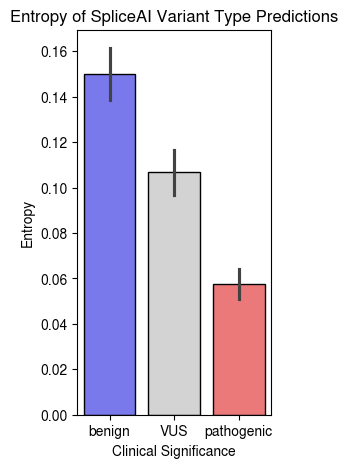

In [112]:
from scipy.stats import entropy

entropy_df = spliceai_df.groupby(["clinsig_simple","site"], observed=True).apply(lambda x: entropy(x["max_delta_score_type"].value_counts(normalize=True), base=2)).reset_index(name="entropy")
entropy_df = utils.sort_by_clinsig(entropy_df, clinsig_col="clinsig_simple")


plt.figure(figsize=(2.5, 5))

sns.barplot(data=entropy_df, 
               x="clinsig_simple", 
               y="entropy", 
               hue="clinsig_simple", 
               legend=False,
                edgecolor="black",
                linewidth=1,
               palette=utils.get_clinsig_palette(),
                )
# plt.xticks(rotation=45, ha='right')
plt.xlabel("Clinical Significance")
plt.ylabel("Entropy")
plt.title("Entropy of SpliceAI Variant Type Predictions")
plt.savefig("manuscript/fig/spliceai_entropy_by_clinsig.pdf", **utils.FIG_SAVE_KWARGS)

### Figure 3E

### Figure 3F

## Figure 4

Flashzoi UTR.

### Figure 1a

VEP distributions: Flashzoi

In [ ]:
variant_set="clinvar_utr_snv"
xr_mfds_dir=os.path.join(
    os.path.expanduser('~'),
    "projects/data/1000_Genomes_on_GRCh38",
    variant_set
) 
pq_file = os.path.join(xr_mfds_dir, "vep_df.parquet")

flashzoi_df = pd.read_parquet(pq_file)
if "VEP" not in flashzoi_df.columns:
    flashzoi_df["VEP"] = flashzoi_df["flashzoi_norm"] 
if "site" not in flashzoi_df.columns:
    flashzoi_df.rename(columns={"site_x": "site"}, inplace=True)
flashzoi_df["protein"] = flashzoi_df["GENE"] 

# Normalize the values before mapping
clnsig_map = {"likely_path": "likely pathogenic",
                    "path": "pathogenic", 
                    "benign": "benign",
                    "vus": "VUS",
                    "likely_benign": "likely benign"} 
flashzoi_df.rename(columns={"site_x":"site"}, inplace=True)
flashzoi_df["VEP"] = flashzoi_df["flashzoi_norm"]
flashzoi_df["clinsig"] = flashzoi_df["CLNSIG_simple"].map(clnsig_map)
flashzoi_df["clinsig_simple"] = flashzoi_df["clinsig"].str.replace("likely ", "")

In [15]:
flashzoi_df.groupby(["CLNSIG_simple"])["site"].nunique()

CLNSIG_simple
benign           3903
likely_benign    1800
likely_path       572
path              374
Name: site, dtype: int64

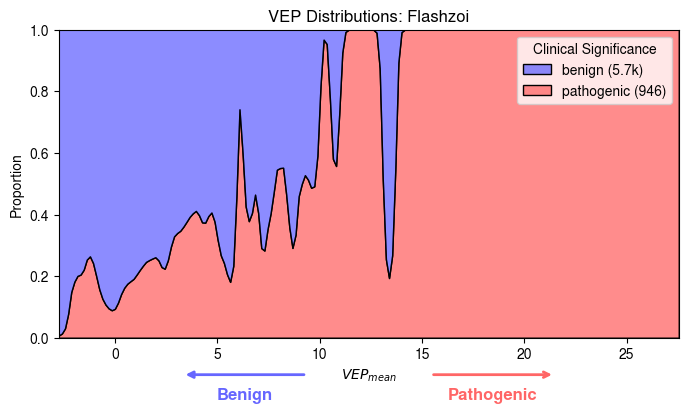

In [12]:
import src.analysis.distributions as db
vep_dist_plot_flashzoi  = db.plot_vep_kde_with_arrows(vep_df=flashzoi_df, 
                                                      figsize=(8, 4),
                                                      format_k=True,
                                                      clinsig_col="clinsig_simple",
                                                      legend_loc="upper right",
                                                      title="VEP Distributions: Flashzoi",
                                                      save_path="manuscript/fig/vep_kde_flashzoi.pdf")

### Figure 4B

Mean VEP by clinsig and 5'/3' UTR

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns
from statannotations.Annotator import Annotator
import itertools

def plot_variant_type_and_clinsig(
    df,
    x_var = "MC_term_label",
    y_var = "VEP",
    hue_var = "clinsig_simple",
    x_label = "Clinical Variant Type",
    y_label = r"VEP$_{mean}$",
    title = r"VEP$_{mean}$ by Clinical Variant Type",
    legend_title = "Clinical Significance", 
    palette=utils.get_clinsig_palette(),
    figsize=(3, 5),
    save_path=None,
    fig_kwargs=None
):
    """
    Create and save a barplot of mean VEP by clinical variant type and significance with statistical annotation.
    Includes comparisons both within each clinical variant type (i.e., among clinsig groups for each MC_term)
    and across clinical variant types (i.e., among MC_terms for each clinsig group).

    Parameters
    ----------
    flashzoi_agg : pd.DataFrame
        DataFrame with columns 'MC_term', 'VEP', 'clinsig_simple'.
    save_path : str
        Output path for the saved figure.
    fig_kwargs : dict or None
        Additional kwargs for plt.savefig (merged with utils.FIG_SAVE_KWARGS).
    """

    # Map MC_term for pretty labels
    df = df.copy()  # avoid modifying original

    mc_terms = sorted(df[x_var].unique())
    clinsig_simple_cats = list(df[hue_var].unique())

    fig = plt.figure(figsize=figsize)
    ax = sns.barplot(
        data=df,
        x=x_var,
        y=y_var,
        hue=hue_var,
        palette=palette,
        order=mc_terms,
        hue_order=clinsig_simple_cats,
    )
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_title(title)
    ax.legend(
        title=legend_title,
        frameon=False,
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0)
    )

    sns.despine(ax=ax, top=True, right=True)

    # Prepare all pairwise comparisons within MC_term (between clinsigs)
    pairs_within = [
        ((mc_term, cat1), (mc_term, cat2))
        for mc_term in mc_terms
        for i, cat1 in enumerate(clinsig_simple_cats)
        for j, cat2 in enumerate(clinsig_simple_cats)
        if j > i
    ]

    # Prepare all pairwise comparisons across MC_terms (between variant types, per clinsig group)
    pairs_across = [
        ((mc1, cln), (mc2, cln))
        for cln in clinsig_simple_cats
        for i, mc1 in enumerate(mc_terms)
        for j, mc2 in enumerate(mc_terms)
        if j > i
    ]

    # Combine both within and across pairs
    pairs = pairs_within + pairs_across

    annotator = Annotator(
        ax=ax,
        pairs=pairs,
        data=df,
        x=x_var,
        y=y_var,
        hue=hue_var,
        order=mc_terms,
        hue_order=clinsig_simple_cats,
    )
    annotator.configure(
        test='t-test_ind',
        text_format='star',
        loc='inside',  # could also consider 'outside' but inside is default
        comparisons_correction="bonferroni"
    )
    annotator.apply_and_annotate()

    save_kwargs = dict(utils.FIG_SAVE_KWARGS)
    if fig_kwargs is not None:
        save_kwargs.update(fig_kwargs)
    if save_path is not None:
        plt.savefig(save_path, **save_kwargs)
    
    plt.show()


In [65]:
flashzoi_vep_mean = flashzoi_df.groupby(["clinsig_simple","MC_term","site"])["VEP"].mean().reset_index()
flashzoi_vep_mean["MC_term_label"] = flashzoi_vep_mean["MC_term"].map(
    {"3_prime_UTR_variant": r"3 $'$ UTR", "5_prime_UTR_variant": r"5 $'$ UTR"}
)

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

5 $'$ UTR_benign vs. 5 $'$ UTR_pathogenic: t-test independent samples with Bonferroni correction, P_val:1.271e-09 t=-6.320e+00
3 $'$ UTR_benign vs. 3 $'$ UTR_pathogenic: t-test independent samples with Bonferroni correction, P_val:2.379e-09 t=-6.205e+00
3 $'$ UTR_benign vs. 5 $'$ UTR_benign: t-test independent samples with Bonferroni correction, P_val:1.636e-03 t=-3.536e+00
3 $'$ UTR_pathogenic vs. 5 $'$ UTR_pathogenic: t-test independent samples with Bonferroni correction, P_val:1.000e+00 t=-5.136e-01


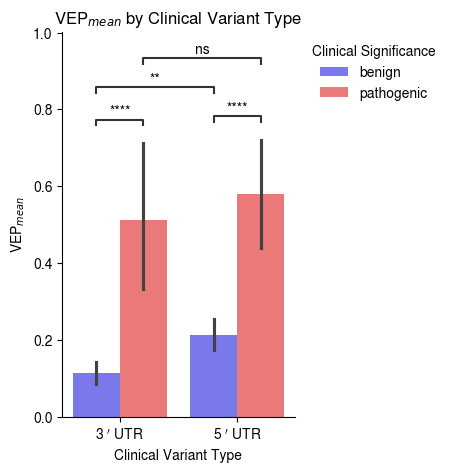

In [69]:
# Call the function
plot_variant_type_and_clinsig(flashzoi_vep_mean, save_path="manuscript/fig/flashzoi_vep_mean_by_variant_type_and_clinsig.pdf")

In [ ]:
from statsmodels import robust

tqdm.pandas()
flashzoi_vep_mad = flashzoi_df.groupby(["clinsig_simple","MC_term","site"], observed=True).progress_apply(
    lambda x: robust.mad(x["VEP"], c=1)
).reset_index().rename(columns={0:"MAD"}).sort_values(by="MAD", ascending=False)

flashzoi_vep_mad["MC_term_label"] = flashzoi_vep_mad["MC_term"].map(
    {"3_prime_UTR_variant": r"3 $'$ UTR", "5_prime_UTR_variant": r"5 $'$ UTR"}
)


 98%|█████████▊| 6485/6649 [00:18<00:00, 3462.30it/s]/home/schilder/.conda/envs/esm2/lib/python3.12/site-packages/tqdm/std.py:917: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return getattr(df, df_function)(wrapper, **kwargs)
100%|██████████| 6649/6649 [00:21<00:00, 311.58it/s] 


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

5 $'$ UTR_pathogenic vs. 5 $'$ UTR_benign: t-test independent samples with Bonferroni correction, P_val:5.907e-01 t=-1.448e+00
3 $'$ UTR_pathogenic vs. 3 $'$ UTR_benign: t-test independent samples with Bonferroni correction, P_val:1.000e+00 t=8.717e-01
3 $'$ UTR_pathogenic vs. 5 $'$ UTR_pathogenic: t-test independent samples with Bonferroni correction, P_val:1.000e+00 t=-1.098e+00
3 $'$ UTR_benign vs. 5 $'$ UTR_benign: t-test independent samples with Bonferroni correction, P_val:2.123e-14 t=-7.841e+00


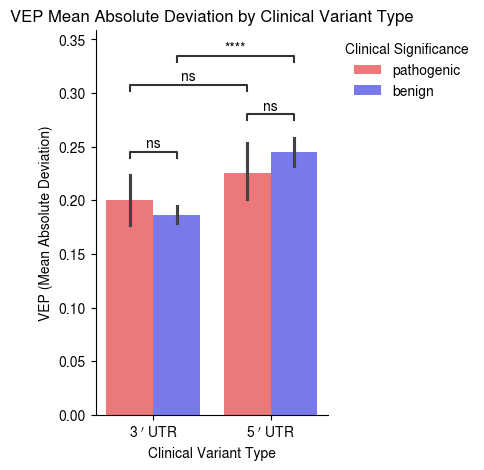

In [67]:
plot_variant_type_and_clinsig(flashzoi_vep_mad, y_var="MAD", y_label="VEP (Mean Absolute Deviation)",
title="VEP Mean Absolute Deviation by Clinical Variant Type",
save_path="manuscript/fig/flashzoi_vep_mad_by_variant_type_and_clinsig.pdf")

---

---

## Figure S1

Plot VEP distributions for each combination of model and scoring strategy.

#### Protein sequence models

In [175]:
# Focus on one model for the main plots
model_name = "esm2_t33_650M_UR50D"

force = False
tmp_vep_path = f"./results/data/vep_df_{model_name}.parquet"
if os.path.exists(tmp_vep_path) and not force:
    print(f"Loading {tmp_vep_path}")
    vep_df = pd.read_parquet(tmp_vep_path)
else:
    vep_files = va.list_vep_files(model_location=model_name, 
                                  as_df=True)
    vep_df = va.merge_vep(add_metadata=True, 
                          scoring_strategy=["masked-marginals"], 
                          vep_files=vep_files.loc[vep_files['model_location']==model_name]
                               )
    print(f"Saving {tmp_vep_path}")
    vep_df.to_parquet(tmp_vep_path)

vep_df.head() 

Loading ./results/data/vep_df_esm2_t33_650M_UR50D.parquet


,haplotype,protein,protein_sequence,mutant,mutated_sequence,DMS_bin_score,VEP,scoring_strategy,is_ref,model_location,variant_set,ENSP,ENST,mutant_in_haplotype,site,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,#Uploaded_variation,Location,Allele,Gene,Feature,Feature_type,Consequence,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,IMPACT,DISTANCE,STRAND,FLAGS,REFSEQ_MATCH,REFSEQ_OFFSET,GIVEN_REF,USED_REF,BAM_EDIT,HGVSc,HGVSp,HGVS_OFFSET,AF_ESP,AF_EXAC,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNSIGCONF,CLNVC,CLNVCSO,GENEINFO,MC,ORIGIN,RS,AF_TGP,CLNVI,CLNDISDBINCL,CLNDNINCL,CLNSIGINCL,EVH_epistatic,EVH_independent,ESM1V_ensemble_mean,Tranception,model_count,clinsig
0,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,L1045F,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Benign,-3.635069,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,NP_000229.1:L1045F,7,150947347,67473,G,A,.,PASS,67473,7:150947347,A,3757,NM_000238.4,Transcript,missense_variant,3541,3133,1045,L/F,Ctc/Ttc,-,MODERATE,-,-1,-,-,-,G,G,-,NM_000238.4:c.3133C>T,NP_000229.1:p.Leu1045Phe,-,NaN,0.00000,78369,"MedGen:CN230736|EFO:EFO_0004269,Human_Phenotyp...",Cardiovascular_phenotype|Cardiac_arrhythmia|Co...,NC_000007.14:g.150947347G>A,"criteria_provided,_multiple_submitters,_no_con...",Benign,NaN,single_nucleotide_variant,SO:0001483,KCNH2:3757,SO:0001583|missense_variant,1,199473025,NaN,ClinGen:CA008015,None,None,None,NaN,NaN,-6.731237,-0.021689,6,benign
1,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,D1003Y,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Pathogenic,-1.670645,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,NP_000229.1:D1003Y,7,150947473,200516,C,A,.,PASS,200516,7:150947473,A,3757,NM_000238.4,Transcript,missense_variant,3415,3007,1003,D/Y,Gac/Tac,-,MODERATE,-,-1,-,-,-,C,C,-,NM_000238.4:c.3007G>T,NP_000229.1:p.Asp1003Tyr,-,NaN,NaN,197155,MedGen:CN517202,not_provided,NC_000007.14:g.150947473C>A,"criteria_provided,_single_submitter",Likely_pathogenic,NaN,single_nucleotide_variant,SO:0001483,KCNH2:3757,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,794728402,NaN,ClinGen:CA007791,None,None,None,NaN,NaN,-2.509515,-0.039753,6,likely_path
2,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,N996I,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Pathogenic,-4.619007,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,NP_000229.1:N996I,7,150947493,67458,T,A,.,PASS,67458,7:150947493,A,3757,NM_000238.4,Transcript,missense_variant,3395,2987,996,N/I,aAc/aTc,-,MODERATE,-,-1,-,-,-,T,T,-,NM_000238.4:c.2987A>T,NP_000229.1:p.Asn996Ile,-,NaN,NaN,78354,"MONDO:MONDO:0019171,MedGen:C1141890,OMIM:PS192...",Congenital_long_QT_syndrome|not_provided|Long_...,NC_000007.14:g.150947493T>A,"criteria_provided,_multiple_submitters,_no_con...",Pathogenic/Likely_pathogenic,NaN,single_nucleotide_variant,SO:0001483,KCNH2:3757,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,199473018,NaN,ClinGen:CA007728|UniProtKB:Q12809#VAR_068285,None,None,None,NaN,NaN,-5.869637,-0.057342,6,likely_path
3,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,E978K,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Benign,-0.514701,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,NP_000229.1:E978K,7,150947639,67453,C,T,.,PASS,67453,7:150947639,T,3757,NM_000238.4,Transcript,missense_variant,3340,2932,978,E/K,Gag/Aag,-,MODERATE,-,-1,-,-,-,C,C,-,NM_000238.4:c.2932G>A,NP_000229.1:p.Glu978Lys,-,0.00008,0.00039,78349,"EFO:EFO_0004269,Human_Phenotype_Ontology:HP:00...",Cardiac_arrhythmia|Cardiovascular_phenotype|no...,NC_000007.14:g.150947639C>T,"criteria_provided,_multip

In [57]:
force = False
groupby_cols = ['model_location','protein','clinsig','mutant','scoring_strategy'] 
vep_agg =[]
vep_counts = []
for model_location in va.list_all_models():

    print(f"Processing {model_location}")
    save_path = os.path.join("results/data/","vep_df_"+model_location+".parquet")
    
    if os.path.exists(save_path) and not force:
        print(f"Loading {save_path}")
        vep_tmp = pd.read_parquet(save_path)
    else:
        vep_files_model = va.list_vep_files(model_location=model_location, as_df=True)
        vep_tmp = va.merge_vep(add_metadata=True, 
                                scoring_strategy=["masked-marginals"], 
                                vep_files=vep_files_model
                                )
        print(f"Saving {save_path}")
        vep_tmp.to_parquet(save_path)
    vep_counts.append(vep_tmp.shape[0])
    vep_agg.append(vep_tmp.groupby(groupby_cols, observed=True)["VEP"].mean().reset_index())
     

vep_agg = pd.concat(vep_agg)
print("Total VEP results:",sum(vep_counts))
vep_agg.head()

No save_dir provided, using: /home/schilder/projects/data/1KG/vep
Processing esm2_t12_35M_UR50D
Loading results/data/vep_df_esm2_t12_35M_UR50D.parquet
Processing esm1b_t33_650M_UR50S
Loading results/data/vep_df_esm1b_t33_650M_UR50S.parquet
Processing esm2_t33_650M_UR50D
Loading results/data/vep_df_esm2_t33_650M_UR50D.parquet
Processing esm1_t34_670M_UR50D
Loading results/data/vep_df_esm1_t34_670M_UR50D.parquet
Processing esm1_t6_43M_UR50S
Loading results/data/vep_df_esm1_t6_43M_UR50S.parquet
Processing esm1v_t33_650M_UR90S_1
Loading results/data/vep_df_esm1v_t33_650M_UR90S_1.parquet
Processing esm2_t48_15B_UR50D
Loading results/data/vep_df_esm2_t48_15B_UR50D.parquet
Processing esm3_sm_open_v1
Loading results/data/vep_df_esm3_sm_open_v1.parquet
Processing esmc_600m
Loading results/data/vep_df_esmc_600m.parquet
Total VEP results: 21709189


,model_location,protein,clinsig,mutant,scoring_strategy,VEP
0,esm2_t12_35M_UR50D,NP_000007.1,benign,C159W,masked-marginals,-4.259397
1,esm2_t12_35M_UR50D,NP_000007.1,likely_benign,M87I,masked-marginals,-0.187846
2,esm2_t12_35M_UR50D,NP_000007.1,likely_path,A113T,masked-marginals,-4.230541
3,esm2_t12_35M_UR50D,NP_000007.1,likely_path,A165T,masked-marginals,-2.380263
4,esm2_t12_35M_UR50D,NP_000007.1,likely_path,A81T,masked-marginals,-2.507311


In [6]:
vep_agg.groupby('model_location').size().sort_values(ascending=False)

model_location
esm1_t34_670M_UR50D       56379
esmc_600m                 56379
esm2_t33_650M_UR50D       56364
esm3_sm_open_v1           56364
esm2_t12_35M_UR50D        53402
esm1v_t33_650M_UR90S_1    35659
esm1b_t33_650M_UR50S      34964
esm2_t48_15B_UR50D         8319
esm1_t6_43M_UR50S          1757
dtype: int64

In [65]:
vep_agg["clinsig"].value_counts()

clinsig
likely_path      126486
likely_benign    120298
path              58536
benign            54267
Name: count, dtype: int64

Filtered 0.2% of rows with NAs in col 'VEP'


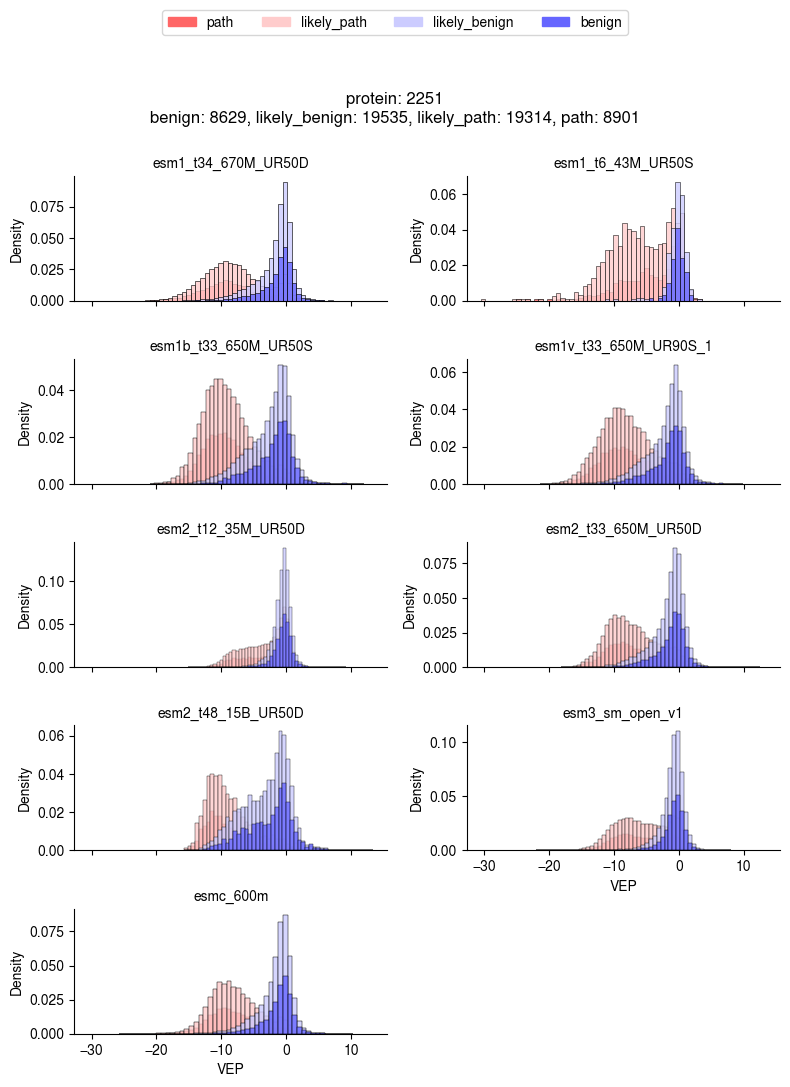

In [66]:
figS1 = va.plot_vep_density(vep_agg.sort_values(by='model_location'), 
                     multiple=['layer','stack','fill'][0],
                     row=None,
                     col='model_location',    
                    #  multiple="stack",
                     plot_func=sns.histplot,
                     stat='density',
                     bins=50,
                     facetgrid_kwargs={'col_wrap': 2}, 
                     height=2,
                     aspect=2,
                     save_path="results/plots/vep_PLM_distributions.pdf"
                     )
figS1['fig'].savefig("manuscript/fig/vep_PLM_distributions.pdf", **utils.FIG_SAVE_KWARGS)

In [67]:
vep_diff_df, vep_diff_summary = db.test_vep_clinsig_separation(vep_agg)
vep_diff_summary

,pvalue,statistic
model_location,,
esmc_600m,1.939497e-08,1.507877e+08
esm2_t33_650M_UR50D,2.205292e-04,1.464150e+08
esm1_t34_670M_UR50D,9.101600e-07,1.448694e+08
esm3_sm_open_v1,3.546757e-05,1.418671e+08
esm2_t12_35M_UR50D,2.079269e-03,1.145610e+08
esm1b_t33_650M_UR50S,1.259272e-01,5.662216e+07
esm1v_t33_650M_UR90S_1,4.195902e-02,5.624953e+07
esm2_t48_15B_UR50D,5.156835e-02,3.089960e+06
esm1_t6_43M_UR50S,1.649432e-01,1.093967e+05


### DNA sequence models

Import Flashzoi VEP results.

In [ ]:
variant_set="clinvar_utr_snv"
xr_mfds_dir=os.path.join(
    os.path.expanduser('~'),
    "projects/data/1000_Genomes_on_GRCh38",
    variant_set
) 
pq_file = os.path.join(xr_mfds_dir, "vep_df.parquet")

flashzoi_df = pd.read_parquet(pq_file)
if "VEP" not in flashzoi_df.columns:
    flashzoi_df["VEP"] = flashzoi_df["flashzoi_norm"] 
if "site" not in flashzoi_df.columns:
    flashzoi_df.rename(columns={"site_x": "site"}, inplace=True)
flashzoi_df["protein"] = flashzoi_df["GENE"] 

# Normalize the values before mapping
clnsig_map = {"likely_path": "likely pathogenic",
                    "path": "pathogenic", 
                    "benign": "benign",
                    "vus": "VUS",
                    "likely_benign": "likely benign"} 
flashzoi_df.rename(columns={"site_x":"site"}, inplace=True)
flashzoi_df["VEP"] = flashzoi_df["flashzoi_norm"]
flashzoi_df["clinsig"] = flashzoi_df["CLNSIG_simple"].map(clnsig_map)

Import SpliceAI VEP results.

In [ ]:
spliceai_df_path = "../data/1000_Genomes_on_GRCh38/SpliceAI/spliceai_clinvar_merged.parquet"
spliceai_df = pd.read_parquet(spliceai_df_path)
spliceai_df["protein"] = spliceai_df["GENE"]

# Normalize the values before mapping
clinsig_map = {"benign": "benign",
               "pathogenic": "path",
               "vus": "VUS"}
spliceai_df["clinsig"] = (
    spliceai_df["CLNSIG_simplified"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map(clinsig_map)
)

spliceai_df["clinsig"].unique()

## Supp Figure: Reference Representativeness

### a

Ref representativeness schematic.

[crop and paste subfigure e]

### b

Reference rep violin: ESM2

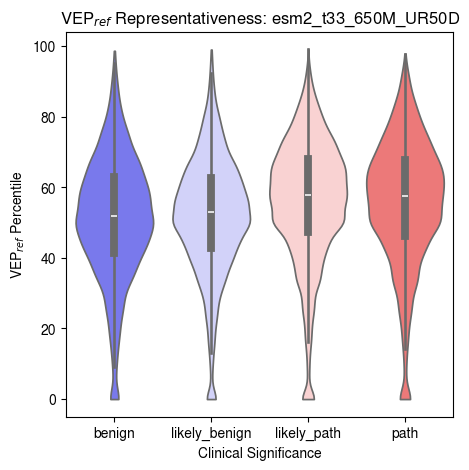

In [90]:
ref_rep_out_esm2 = va.plot_vep_ref_representativeness(vep_df, 
                groupby_cols=['model_location','protein','clinsig','mutant','scoring_strategy'], 
                title=r"VEP$_{ref}$ Representativeness"+f": {model_name}",
                hline_x=None,
                reverse_percentiles=True
                )
ref_rep_out_esm2["fig"].savefig("manuscript/fig/ref_rep_violin_esm2.pdf", **utils.FIG_SAVE_KWARGS)   

### c

Reference rep violin: SpliceAI

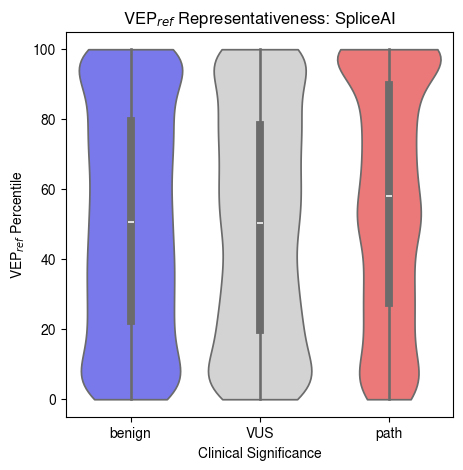

In [89]:
ref_rep_out_spliceai = va.plot_vep_ref_representativeness(spliceai_df, 
                                groupby_cols=['site','clinsig'],
                                # clinsig_col="CLNSIG_simplified",
                                title=r"VEP$_{ref}$ Representativeness"+f": SpliceAI",
                                hline_x=None
                                )
ref_rep_out_spliceai["fig"].savefig("manuscript/fig/ref_rep_violin_spliceai.pdf", **utils.FIG_SAVE_KWARGS)   

### d

Reference rep violin: Flashzoi

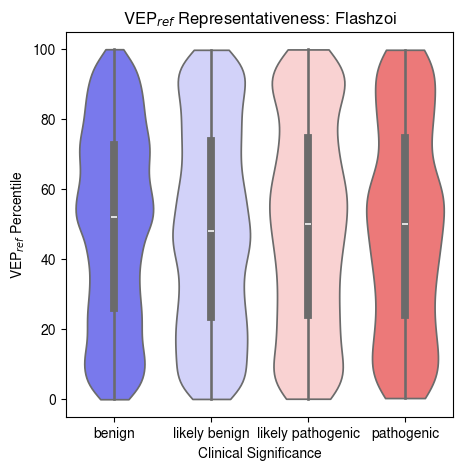

In [94]:
ref_rep_out_flashzoi = va.plot_vep_ref_representativeness(flashzoi_df, 
                                groupby_cols=['site','clinsig'],
                                title=r"VEP$_{ref}$ Representativeness"+f": Flashzoi",
                                hline_x=None,
                                reverse_percentiles=True)
ref_rep_out_flashzoi["fig"].savefig("manuscript/fig/ref_rep_violin_flashzoi.pdf", **utils.FIG_SAVE_KWARGS)   

### e

Reference rep bar: ESM2

Computing representativeness stats for VEP_percentile


<string>:102: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
<string>:187: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


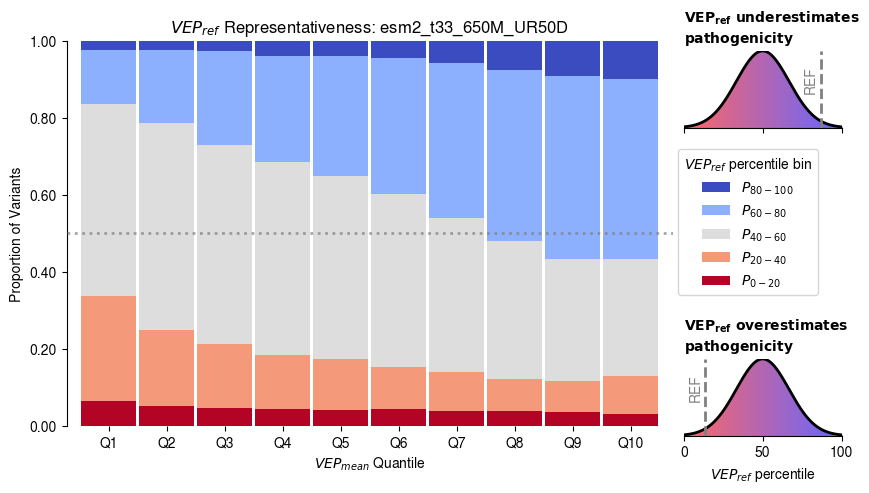

In [98]:
ref_rep_bar_esm2 = db.plot_ref_vep_percentile_stacked_bar(vep_df, 
                                                    title=r"$VEP_{ref}$ Representativeness:"+f" {model_name}",
                                                    figsize=(10, 5), 
                                                    barplot_width_ratio=5, 
                                                    n_ref_pct_bins=5,
                                                    legend_on_right=True,
                                                    show_schematic_xlabel=(False, True), 
                                                    show_schematic_ylabel=[False, False],
                                                    show_vertical_arrows=False,   
                                                    schematic_width_ratio=1.3,
                                                    schematic_padding_left = -0.15,
                                                    schematic_padding_top=0.02,
                                                    schematic_heights=[0.2, 0.6, 0.2],
                                                    
                                                    flip_xaxis=True
                                                    )
ref_rep_bar_esm2["fig"].savefig("manuscript/fig/ref_rep_bar_esm2.pdf", **utils.FIG_SAVE_KWARGS)   
 

### f

Reference rep bar: SpliceAI

Computing representativeness stats for VEP_percentile


<string>:102: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
<string>:187: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


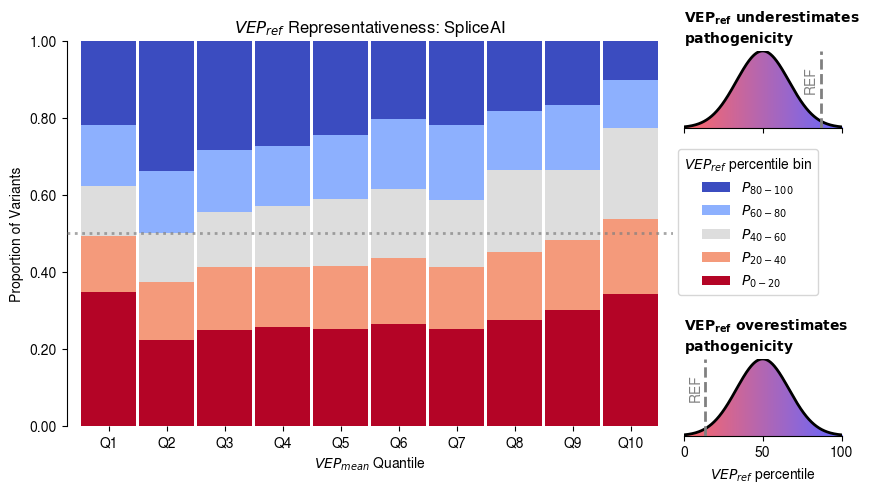

In [101]:
ref_rep_bar_spliceai = db.plot_ref_vep_percentile_stacked_bar(spliceai_df,
                                                    groupby_cols=['site','clinsig'],
                                                     title=r"$VEP_{ref}$ Representativeness: SpliceAI",
                                                    figsize=(10, 5), 
                                                    barplot_width_ratio=5, 
                                                    n_ref_pct_bins=5,
                                                    legend_on_right=True,
                                                    show_schematic_xlabel=(False, True), 
                                                    show_schematic_ylabel=[False, False],
                                                    show_vertical_arrows=False,   
                                                    schematic_width_ratio=1.3,
                                                    schematic_padding_left = -0.15,
                                                    schematic_padding_top=0.02,
                                                    schematic_heights=[0.2, 0.6, 0.2]
                                                    )
ref_rep_bar_spliceai["fig"].savefig("manuscript/fig/ref_rep_bar_spliceai.pdf", **utils.FIG_SAVE_KWARGS)   

### g

Reference rep bar: Flashzoi

Computing representativeness stats for VEP_percentile


<string>:102: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
<string>:187: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


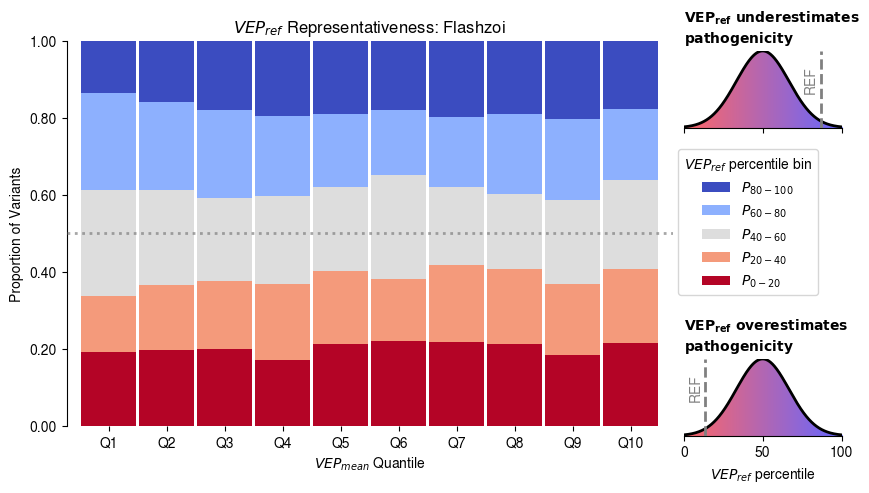

In [102]:
ref_rep_bar_flashzoi = db.plot_ref_vep_percentile_stacked_bar(flashzoi_df,
                                                    groupby_cols=['site','clinsig'],
                                                     title=r"$VEP_{ref}$ Representativeness: Flashzoi",
                                                    figsize=(10, 5), 
                                                    barplot_width_ratio=5, 
                                                    n_ref_pct_bins=5,
                                                    legend_on_right=True,
                                                    show_schematic_xlabel=(False, True), 
                                                    show_schematic_ylabel=[False, False],
                                                    show_vertical_arrows=False,   
                                                    schematic_width_ratio=1.3,
                                                    schematic_padding_left = -0.15,
                                                    schematic_padding_top=0.02,
                                                    schematic_heights=[0.2, 0.6, 0.2]
                                                    )
ref_rep_bar_flashzoi["fig"].savefig("manuscript/fig/ref_rep_bar_flashzoi.pdf", **utils.FIG_SAVE_KWARGS)   
 

In [57]:
#### Violin plot version ####
# fig1f_vio = db.plot_vep_percentiles(vep_df, row=None, col=None, height=5, aspect=1.5, x_rotation=0, x_ha='center')

## Supp Figure: VEP normality/modality

In [113]:
groupby_cols = ['model_location','protein','clinsig','mutant','site','scoring_strategy']
normality_results = db.test_normality(vep_df,
                                      min_n=20,
                                      groupby_cols=groupby_cols,
                                      save_path='results/normality_results.parquet')
normality_results.head()

Loading cached normality results


metric,model_location,protein,clinsig,mutant,site,scoring_strategy,n_samples,pvalue,statistic
0,esm2_t33_650M_UR50D,NP_000007.1,benign,C159W,NP_000007.1:C159W,masked-marginals,26.0,0.288377,2.486977
1,esm2_t33_650M_UR50D,NP_000007.1,likely_benign,M87I,NP_000007.1:M87I,masked-marginals,26.0,0.000002,25.841743
2,esm2_t33_650M_UR50D,NP_000007.1,likely_path,A113T,NP_000007.1:A113T,masked-marginals,26.0,0.008392,9.560975
3,esm2_t33_650M_UR50D,NP_000007.1,likely_path,A165T,NP_000007.1:A165T,masked-marginals,26.0,0.000017,21.954090
4,esm2_t33_650M_UR50D,NP_000007.1,likely_path,A81T,NP_000007.1:A81T,masked-marginals,26.0,0.001276,13.327450


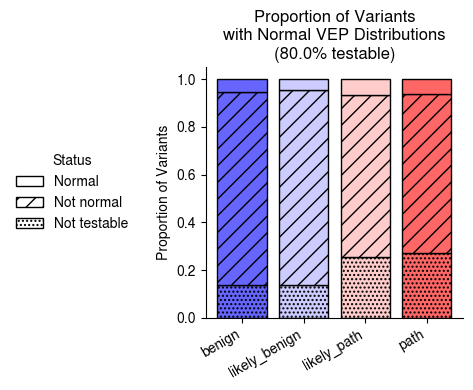

Total proteins: 2250
Total sites: 56364
Sites with normal distribution (Testable): 45089.03316213845 (80.00%)
Sites with normal distribution (True): 3178.2121221624743 (5.64%)
Sites with non-normal distribution: 41910.82103997596 (74.36%)


In [ ]:
fig_normality = db.plot_test_normality(normality_results, 
                                figsize=(5, 4), 
                                legend_left=True, 
                                )
fig_normality['fig'].savefig("manuscript/fig/normality_tests.pdf", **utils.FIG_SAVE_KWARGS)

### Figure S2c

Estimate the modallity for each VEP distribution.

In [120]:
vep_ecdf = db.estimate_modality(
    vep_df=vep_df,  
    save_path='results/vep_ecdf.parquet',
    min_haplotypes=20,
    max_components=50,
    force=False
    )  
vep_ecdf["n_peaks"].min(),  vep_ecdf["n_peaks"].max(), vep_ecdf["n_peaks"].median()

Loading cached ECDF data
(4578200, 21)


(np.int64(1), np.int64(6), np.float64(2.0))

Remaining sites @ n_haplotypes >= 20: 43643 / 45782 = 95.3278581102%


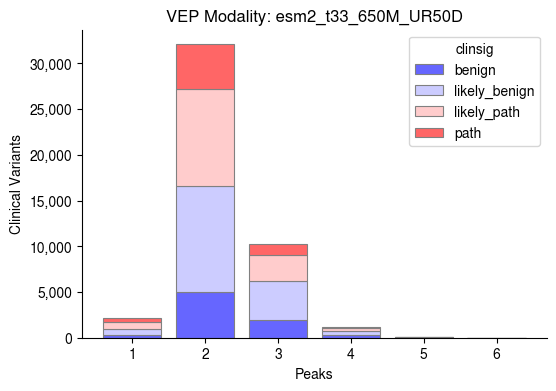

clinsig,n_peaks,benign,likely_benign,likely_path,path,total
0,1,293,611,854,381,2139
1,2,5011,11550,10685,4830,32076
2,3,1925,4272,2805,1270,10272
3,4,254,533,275,121,1183
4,5,24,54,21,8,107
5,6,1,3,1,0,5


In [122]:
fig_modality = db.plot_estimate_modality(vep_ecdf,
                                    title=f"VEP Modality: {model_name}",
                                    min_haplotypes=20, 
                                    figsize=(6, 4))
fig_modality['fig'].savefig("manuscript/fig/modality_estimates.pdf", **utils.FIG_SAVE_KWARGS)
peak_counts =fig_modality['data'].reset_index()
peak_counts

In [70]:
peak_counts.loc[peak_counts['n_peaks']>1]['total'].sum()

np.int64(43643)

In [ ]:
# Proportion of variants with >1 peak
100-peak_counts.loc[peak_counts['n_peaks']==1]['total'].sum() / peak_counts['total'].sum()*100

np.float64(95.3278581101743)

In [ ]:
# Proportion of all variants tested for modality
fig_modality['data']['total'].sum()/vep_df['site'].nunique()*100

np.float64(81.2256049960968)

### Figure S2c

Reference representativeness: VEP standard deviation.

Computing representativeness stats for VEP_percentile


<string>:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


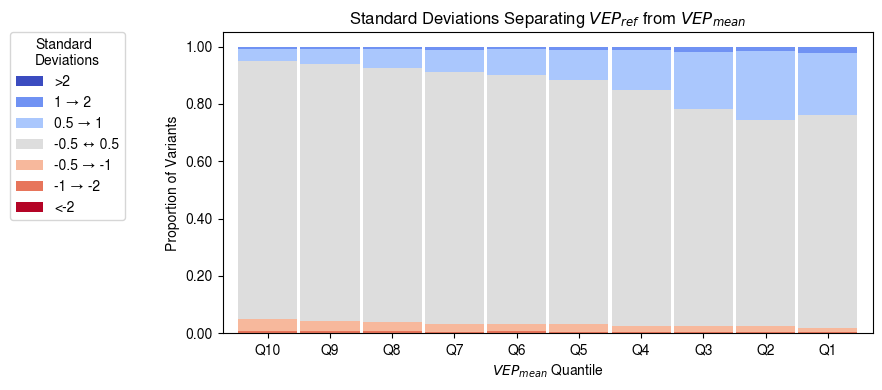

In [162]:
#### Standard Deviation version ####

# Limit to variants with normal VEP distributions
groupby_cols = ['model_location','protein','clinsig','mutant','scoring_strategy']
vep_sub = vep_df.merge(
    normality_results.loc[normality_results["pvalue"] >= 0.05],
    on=groupby_cols,
    how="left"
) 
fig_std = db.plot_ref_vep_std_stacked_bar(vep_sub, flip_xaxis=True, add_arrows=False)
fig_std['fig'].savefig("manuscript/fig/ref_rep_bar_std_esm2.pdf", **utils.FIG_SAVE_KWARGS)

In [128]:
fig_std['data'].groupby('VEP_pct_group_cat').size() / fig_std['data'].groupby('VEP_pct_group_cat').size().sum()*100

/tmp/ipykernel_500173/94682268.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fig_std['data'].groupby('VEP_pct_group_cat').size() / fig_std['data'].groupby('VEP_pct_group_cat').size().sum()*100
/tmp/ipykernel_500173/94682268.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fig_std['data'].groupby('VEP_pct_group_cat').size() / fig_std['data'].groupby('VEP_pct_group_cat').size().sum()*100


VEP_pct_group_cat
<-2            0.072744
-1 → -2        1.169227
-0.5 → -1     12.228097
-0.5 ↔ 0.5    83.291934
0.5 → 1        2.677336
1 → 2          0.455981
>2             0.104680
dtype: float64

### Figure S2d

VEP distribution UMAP.

In [129]:
ecdf_umap_df, vep_ecdf_pivot = db.ecdf_to_umap(vep_ecdf)

Running UMAP


/home/schilder/.conda/envs/esm2/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP(n_jobs=1, random_state=42, verbose=True)
Mon Oct  6 22:27:35 2025 Construct fuzzy simplicial set
Mon Oct  6 22:27:35 2025 Finding Nearest Neighbors
Mon Oct  6 22:27:35 2025 Building RP forest with 16 trees
Mon Oct  6 22:27:39 2025 NN descent for 15 iterations
	 1  /  15
	 2  /  15
	Stopping threshold met -- exiting after 2 iterations
Mon Oct  6 22:27:49 2025 Finished Nearest Neighbor Search
Mon Oct  6 22:27:51 2025 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Mon Oct  6 22:28:10 2025 Finished embedding


In [130]:
ecdf_umap_df, vep_ecdf_pivot =  db.cluster_and_annotate_umap(ecdf_umap_df, 
                                                             vep_ecdf_pivot,  
                                                             n_samples=None, 
                                                             method='kmeans',
                                                             n_clusters=20,
                                                            #  cluster_on_umap=True,
                                                            #  cluster_kwargs={'eps':.01, 'min_samples':100},
                                                             show_dendrogram=False)

Number of clusters (kmeans): 20
Cluster distribution:
cluster
1     3050
2     2437
3     1138
4     2293
5     1750
6     1977
7     2470
8     2052
9     1868
10    1694
11    2267
12    2417
13    2386
14    2106
15    2709
16    2756
17    2284
18    2715
19    2833
20    2580
Name: count, dtype: int64


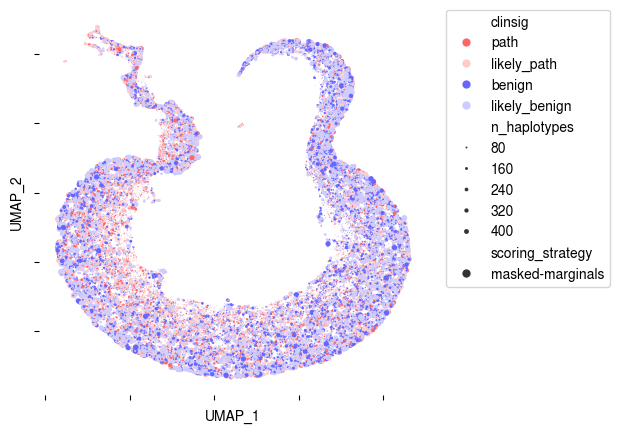

In [ ]:
fig_umap_clinsig = db.plot_cluster_umap(ecdf_umap_df,  
                     hue_var="clinsig",
                     palette=utils.get_clinsig_palette(),
                     figsize=(5, 5))
fig_umap_clinsig['fig'].savefig("manuscript/fig/ecdf_umap_by_clinsig.pdf", **utils.FIG_SAVE_KWARGS)                    

/home/schilder/projects/VEP_protein/src/analysis/distributions.py:890: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  linewidth=2.0


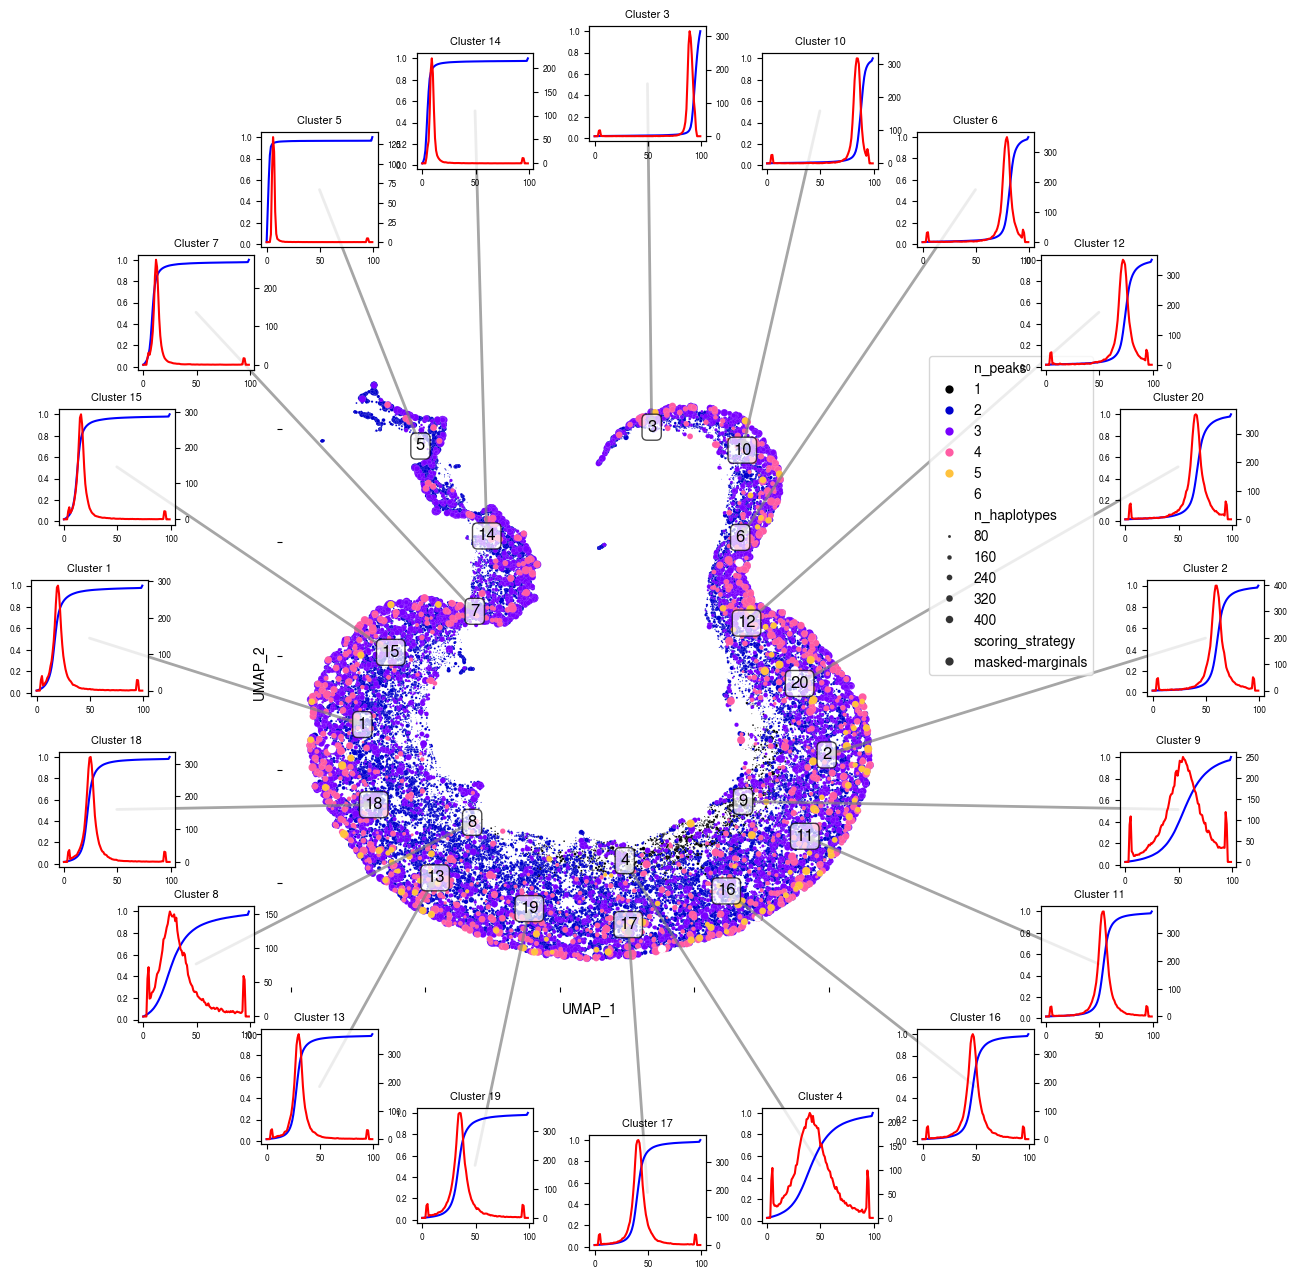

In [134]:
fig_umap_modality = db.plot_cluster_umap_with_distribution_plots(ecdf_umap_df.sort_values(by='n_peaks', ascending=True),
                                                       vep_ecdf, 
                                                       vep_ecdf_pivot, 
                                                      hue='n_peaks',
                                                      palette="gnuplot2",  
                                                      line_color="grey", 
                                                      figsize=(10, 10),
                                                       sizes=(.0001, 35), 
                                                        min_distance=0.8, 
                                                        connector_alpha=0.7)
fig_umap_modality['fig'].savefig("manuscript/fig/ecdf_umap_by_modality.pdf", **utils.FIG_SAVE_KWARGS)

## Figure S3

In [176]:
if "VEP_REF" not in vep_df.columns:
    vep_df = va.compute_representativeness_stats(vep_df, is_ref=False)

if "freq_df" not in globals():
    haps_to_samples = hs.haplotypes_to_samples(haplotypes=haplotypes,  
                                            as_df=True,
                                            add_sample_metadata=True,
                                            return_seqs=False, 
                                            add_ref=False, 
                                            duplicate_ref=False,
                                            verbose=True,
                                            )

    freq_df = hs.calculate_haplotype_frequency_per_superpop(
        haps_to_samples,
        cast=True, 
        verbose=True,
        add_specificity_cols=True
    )

Computing representativeness stats for VEP_percentile


In [247]:
max_rows=20
sample_head_and_tail=True
is_ref_filter=True
abs_diff_threshold=1
x="VEP_mean_diff" 



if "n_haplotypes" not in vep_df.columns:
    vep_df["n_haplotypes"] = vep_df.groupby(["model_location", "scoring_strategy","protein", "mutant"])["haplotype"].transform("nunique")
vep_df["Gene"] = vep_df["GENEINFO"].str.split(":").str[0]

diff_df = vep_df.copy()

if is_ref_filter is not None:
    diff_df = diff_df.loc[diff_df["is_ref"] ==is_ref_filter]

# Find variants where the REF was +/- 1 VEP unit from the mean
# (If x is not "VEP_mean_diff", still filter by VEP_mean_diff for consistency)
if abs_diff_threshold is not None:
    diff_df = diff_df.loc[((diff_df[x] > abs_diff_threshold) | (diff_df[x] < -abs_diff_threshold))]

# Merge in mean_freq if freq_df is provided
if freq_df is not None:
    freq_cols = [col for col in freq_df.columns if col.endswith("_freq") and col != "top_superpopulation_freq"]
    total_hap_freqs = freq_df.set_index("haplotype")[freq_cols].mean(axis=1).reset_index().rename(columns={0: "mean_freq"})
    diff_df = diff_df.merge(total_hap_freqs, on=["haplotype"], how="left")


diff_df = utils.sort_by_clinsig(diff_df)
diff_df[x+"_abs"] = diff_df[x].abs()
diff_df.sort_values(by=x, ascending=False, inplace=True)

if max_rows is not None: 
    if sample_head_and_tail:
        diff_df = pd.concat([diff_df.head(max_rows//2), 
                                diff_df.tail(max_rows//2)])
    else:
        diff_df = diff_df.head(max_rows)

print(diff_df.groupby(["model_location", "scoring_strategy"], observed=True).agg({"mutant": pd.Series.nunique, "protein": pd.Series.nunique}))

diff_df["Gene"] = diff_df["GENEINFO"].str.split(":").str[0]
diff_df.head()

                                      mutant  protein
model_location      scoring_strategy                 
esm2_t33_650M_UR50D masked-marginals      20        9


,haplotype,protein,protein_sequence,mutant,mutated_sequence,DMS_bin_score,VEP,scoring_strategy,is_ref,model_location,variant_set,ENSP,ENST,mutant_in_haplotype,site,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,#Uploaded_variation,Location,Allele,Gene,Feature,Feature_type,Consequence,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,IMPACT,DISTANCE,STRAND,FLAGS,REFSEQ_MATCH,REFSEQ_OFFSET,GIVEN_REF,USED_REF,BAM_EDIT,HGVSc,HGVSp,HGVS_OFFSET,AF_ESP,AF_EXAC,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNSIGCONF,CLNVC,CLNVCSO,GENEINFO,MC,ORIGIN,RS,AF_TGP,CLNVI,CLNDISDBINCL,CLNDNINCL,CLNSIGINCL,EVH_epistatic,EVH_independent,ESM1V_ensemble_mean,Tranception,model_count,clinsig,VEP_percentile,VEP_std,VEP_mean,VEP_mean_diff,VEP_REF,VEP_ref_diff,n_haplotypes,mean_freq,VEP_mean_diff_abs
132,ENSP00000344757:REF,NP_937799.1,MPRRAENWDEAEVGAEEAGVEEYGPEEDGGEESGAEESGPEESGPE...,C121F,MPRRAENWDEAEVGAEEAGVEEYGPEEDGGEESGAEESGPEESGPE...,Pathogenic,-0.743655,masked-marginals,True,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000344757,ENST00000345392,False,NP_937799.1:C121F,3,10149808,43604,G,T,.,PASS,43604,3:10149808,T,VHL,NM_198156.3,Transcript,missense_variant,432,362,121,C/F,tGc/tTc,-,MODERATE,-,1,-,-,-,G,G,-,NM_198156.3:c.362G>T,NP_937799.1:p.Cys121Phe,-,NaN,0.00001,52773,"MONDO:MONDO:0008667,MedGen:C0019562,OMIM:19330...",Von_Hippel-Lindau_syndrome|Chuvash_polycythemia,NC_000003.12:g.10149808G>T,"criteria_provided,_multiple_submitters,_no_con...",Pathogenic,NaN,single_nucleotide_variant,SO:0001483,VHL:7428|LOC107303340:107303340,"SO:0001583|missense_variant,SO:0001624|3_prime...",1,397516444,NaN,ClinGen:CA020418|UniProtKB:P40337#VAR_005754,None,None,None,-5.868242,-5.022188,0.670082,-0.096898,4,path,73.333333,3.447009,-3.365415,2.621759,-0.743655,0.0,15,0.000390,2.621759
133,ENSP00000344757:REF,NP_937799.1,MPRRAENWDEAEVGAEEAGVEEYGPEEDGGEESGAEESGPEESGPE...,C121W,MPRRAENWDEAEVGAEEAGVEEYGPEEDGGEESGAEESGPEESGPE...,Pathogenic,-0.874693,masked-marginals,True,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000344757,ENST00000345392,False,NP_937799.1:C121W,3,10149809,223227,C,G,.,PASS,223227,3:10149809,G,VHL,NM_198156.3,Transcript,missense_variant,433,363,121,C/W,tgC/tgG,-,MODERATE,-,1,-,-,-,C,C,-,NM_198156.3:c.363C>G,NP_937799.1:p.Cys121Trp,-,NaN,NaN,224957,"MONDO:MONDO:0009892,MedGen:C1837915,OMIM:26340...",Chuvash_polycythemia|Von_Hippel-Lindau_syndrom...,NC_000003.12:g.10149809C>G,"criteria_provided,_multiple_submitters,_no_con...",Pathogenic,NaN,single_nucleotide_variant,SO:0001483,VHL:7428|LOC107303340:107303340,"SO:0001583|missense_variant,SO:0001624|3_prime...",1,5030622,NaN,ClinGen:CA357016|UniProtKB:P40337#VAR_005756,None,None,None,-5.868242,-5.022188,-0.620578,-0.139289,4,path,73.333333,2.816355,-3.149899,2.275206,-0.874693,0.0,15,0.000390,2.275206
131,ENSP00000344757:REF,NP_937799.1,MPRRAENWDEAEVGAEEAGVEEYGPEEDGGEESGAEESGPEESGPE...,C121Y,MPRRAENWDEAEVGAEEAGVEEYGPEEDGGEESGAEESGPEESGPE...,Pathogenic,-0.542314,masked-marginals,True,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000344757,ENST00000345392,False,NP_937799.1:C121Y,3,10149808,223225,G,A,.,PASS,223225,3:10149808,A,VHL,NM_198156.3,Transcript,missense_variant,432,362,121,C/Y,tGc/tAc,-,MODERATE,-,1,-,-,-,G,G,-,NM_198156.3:c.362G>A,NP_937799.1:p.Cys121Tyr,-,NaN,NaN,224955,"MONDO:MONDO:0008667,MedGen:C0019562,OMIM:19330...",Von_Hippel-Lindau_syndrome,NC_000003.12:g.10149808G>A,"criteria_provided,_single_submitter",Likely_pathogenic,NaN,single_nucleotide_variant,SO:0001483,VHL:7428|LOC107303340:107303340,"SO:0001583|missense_variant,SO:0001624|3_prime...",1,397516444,NaN,ClinGen:CA357010|UniProtKB:P40337#VAR_005757,None,None,None,-5.868242,-5.022188,0.618526,-0.116856,4,likely_path,73.333333,2.921206,-2.753346,2.211033,-0.542314,0.0,15,0.000390,2.211033
130,ENSP00000344757:REF,NP_937799.1,MPRRAENWDEAEVGAEEAGVEEYGPEEDGGEESGAEESGPEESGPE...,C121R,MPRRAENWDEAEVGAEEAGVEEYGPEEDGGEESGAEESGPEESGPE...,Pathogenic,-0.715974,masked-margi

In [179]:
import src.analysis.vep_gmm as gmm

gmm_df = gmm.train_vep_gmm(vep_df)
gmm_df.head()

Training GMMs: 100%|██████████| 2250/2250 [01:03<00:00, 35.71it/s]


Total model-protein-scoring combinations with GMM models: 2240
Average accuracy: 0.2177
Average AUC: 0.8809

Top 10 models by accuracy:
           model_location         protein  scoring_strategy  accuracy  \
1884  esm2_t33_650M_UR50D     NP_085135.1  masked-marginals  0.957395   
888   esm2_t33_650M_UR50D     NP_002959.2  masked-marginals  0.942280   
2198  esm2_t33_650M_UR50D     NP_938011.1  masked-marginals  0.929825   
420   esm2_t33_650M_UR50D  NP_001025053.1  masked-marginals  0.925532   
1607  esm2_t33_650M_UR50D     NP_058633.2  masked-marginals  0.888889   
264   esm2_t33_650M_UR50D     NP_000470.3  masked-marginals  0.887774   
421   esm2_t33_650M_UR50D  NP_001025054.1  masked-marginals  0.876608   
933   esm2_t33_650M_UR50D     NP_003325.2  masked-marginals  0.870968   
971   esm2_t33_650M_UR50D     NP_003782.1  masked-marginals  0.870412   
1097  esm2_t33_650M_UR50D     NP_004786.2  masked-marginals  0.867505   

      precision  recall   f1       auc  benign_count  path_c

,model_location,protein,scoring_strategy,accuracy,precision,recall,f1,auc,benign_count,path_count,mean_0,mean_1,var_0,var_1,weight_0,weight_1
0,esm2_t33_650M_UR50D,NP_000007.1,masked-marginals,0.216288,0.946502,0.209567,0.343156,0.790091,52,2195,-4.858321,-2.936112,17.367346,4.357797,0.380848,0.619152
1,esm2_t33_650M_UR50D,NP_000008.1,masked-marginals,0.116769,0.289902,0.101482,0.150338,0.947596,262,877,-9.042980,-1.518019,4.370647,2.407739,0.744596,0.255404
2,esm2_t33_650M_UR50D,NP_000009.1,masked-marginals,0.135375,0.627983,0.147178,0.238468,0.988069,343,3934,-9.605497,-5.205273,4.802372,11.925458,0.644322,0.355678
3,esm2_t33_650M_UR50D,NP_000010.1,masked-marginals,0.067669,0.419118,0.052102,0.092683,0.980494,103,1094,-9.201572,-5.107226,2.724309,10.559997,0.789079,0.210921
4,esm2_t33_650M_UR50D,NP_000011.2,masked-marginals,0.300866,0.843866,0.313825,0.457508,0.907284,280,4340,-9.486340,-4.397326,4.214063,7.623743,0.619080,0.380920


In [186]:
boundary_crossing_df = gmm.get_decision_boundaries(gmm_df, vep_df, plot=False)
boundary_crossing_df.head()

Finding boundary-crossing variants: 100%|██████████| 56364/56364 [00:06<00:00, 8959.28it/s] 


No variants found that cross decision boundaries in different haplotypes


,protein,mutant,clinsig,decision_boundary,min_vep,max_vep,vep_range,haplotype_count,scores_above_boundary,scores_below_boundary,crossing_proportion
0,NP_000007.1,M326T,likely_path,-6.210108,-7.108946,-4.940533,2.168413,26,1,25,0.038462
1,NP_000007.1,P132H,likely_path,-6.210108,-6.668670,-5.512917,1.155754,26,7,19,0.269231
2,NP_000007.1,P74L,likely_path,-6.210108,-7.300304,-4.750434,2.549870,26,25,1,0.038462
3,NP_000007.1,Q317E,likely_path,-6.210108,-6.965709,-4.721759,2.243949,26,25,1,0.038462
4,NP_000007.1,T193A,likely_path,-6.210108,-6.297962,-6.030916,0.267046,26,25,1,0.038462


### Entropy ranking

In [ ]:
from scipy.stats import entropy

tqdm.pandas()
entropy_df = vep_df.groupby(["model_location", "scoring_strategy", "protein", "mutant", "site","n_haplotypes"], observed=True).progress_apply(
    lambda x: entropy(x["VEP"])
).reset_index(name="entropy").sort_values(by="entropy", ascending=False)


  0%|          | 0/56364 [00:00<?, ?it/s]

/home/schilder/.conda/envs/esm2/lib/python3.12/site-packages/tqdm/std.py:917: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return getattr(df, df_function)(wrapper, **kwargs)


Text(0.05, 0.95, '$R^2$ = 0.645\np = 0.00e+00')

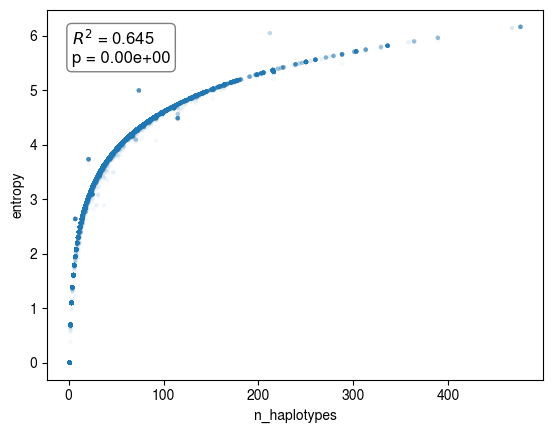

In [238]:
import scipy.stats as stats
from sklearn.linear_model import LinearRegression
import numpy as np

# Remove rows with NaN or inf/-inf in 'entropy' or 'n_haplotypes'
entropy_df_clean = entropy_df.dropna(subset=["n_haplotypes", "entropy"])
# Remove rows where 'entropy' or 'n_haplotypes' are inf or -inf
entropy_df_clean = entropy_df_clean[
    np.isfinite(entropy_df_clean["n_haplotypes"]) & np.isfinite(entropy_df_clean["entropy"])
]

# Scatterplot
sns.scatterplot(data=entropy_df_clean, x="n_haplotypes", y="entropy", edgecolor="none", alpha=0.05, s=10)

# Linear regression for R^2 and p-value
x = entropy_df_clean["n_haplotypes"].values.reshape(-1, 1)
y = entropy_df_clean["entropy"].values

# Fit linear regression
reg = LinearRegression().fit(x, y)
r2 = reg.score(x, y)

# Calculate p-value using scipy.stats.linregress
slope, intercept, r_value, p_value, std_err = stats.linregress(entropy_df_clean["n_haplotypes"], entropy_df_clean["entropy"])

# Annotate plot with R^2 and p-value
plt.gca().annotate(f"$R^2$ = {r2:.3f}\np = {p_value:.2e}", 
                   xy=(0.05, 0.95), xycoords='axes fraction', 
                   ha='left', va='top', fontsize=12,
                   bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=1))

In [233]:
# Instead of linear regression, use a non-parametric correction: for each n_haplotypes, subtract the median entropy at that n_haplotypes.
# This gives a "corrected" entropy that reflects deviation from typical entropy at that sample size.

# Compute the median entropy for each n_haplotypes value
median_entropy_by_n = entropy_df.groupby("n_haplotypes")["entropy"].median()

# Map the median entropy to each row
entropy_df["median_entropy_at_n"] = entropy_df["n_haplotypes"].map(median_entropy_by_n)

# Subtract the median to get a corrected entropy
entropy_df["entropy_resid"] = entropy_df["entropy"] - entropy_df["median_entropy_at_n"]

# Optionally, drop the helper column
entropy_df.drop(columns=["median_entropy_at_n"])

,model_location,scoring_strategy,protein,mutant,site,n_haplotypes,entropy,entropy_resid
56113,esm2_t33_650M_UR50D,masked-marginals,NP_982272.2,L1530V,NP_982272.2:L1530V,476,6.165417,0.000198
56110,esm2_t33_650M_UR50D,masked-marginals,NP_982272.2,F12L,NP_982272.2:F12L,476,6.165411,0.000193
56121,esm2_t33_650M_UR50D,masked-marginals,NP_982272.2,T3S,NP_982272.2:T3S,476,6.165396,0.000177
56120,esm2_t33_650M_UR50D,masked-marginals,NP_982272.2,T366M,NP_982272.2:T366M,476,6.165386,0.000168
56111,esm2_t33_650M_UR50D,masked-marginals,NP_982272.2,I1189V,NP_982272.2:I1189V,476,6.165380,0.000162
...,...,...,...,...,...,...,...,...
56333,esm2_t33_650M_UR50D,masked-marginals,NP_998764.1,R758C,NP_998764.1:R758C,78,NaN,NaN
56335,esm2_t33_650M_UR50D,masked-marginals,NP_998764.1,S796L,NP_998764.1:S796L,78,NaN,NaN
56339,esm2_t33_650M_UR50D,masked-marginals,NP_998764.1,W655R,NP_998764.1:W655R,78,NaN,NaN
56340,esm2_t33_650M_UR50D,masked-marginals,NP_998764.1,Y652C,NP_998764.1:Y652C,78,NaN,NaN


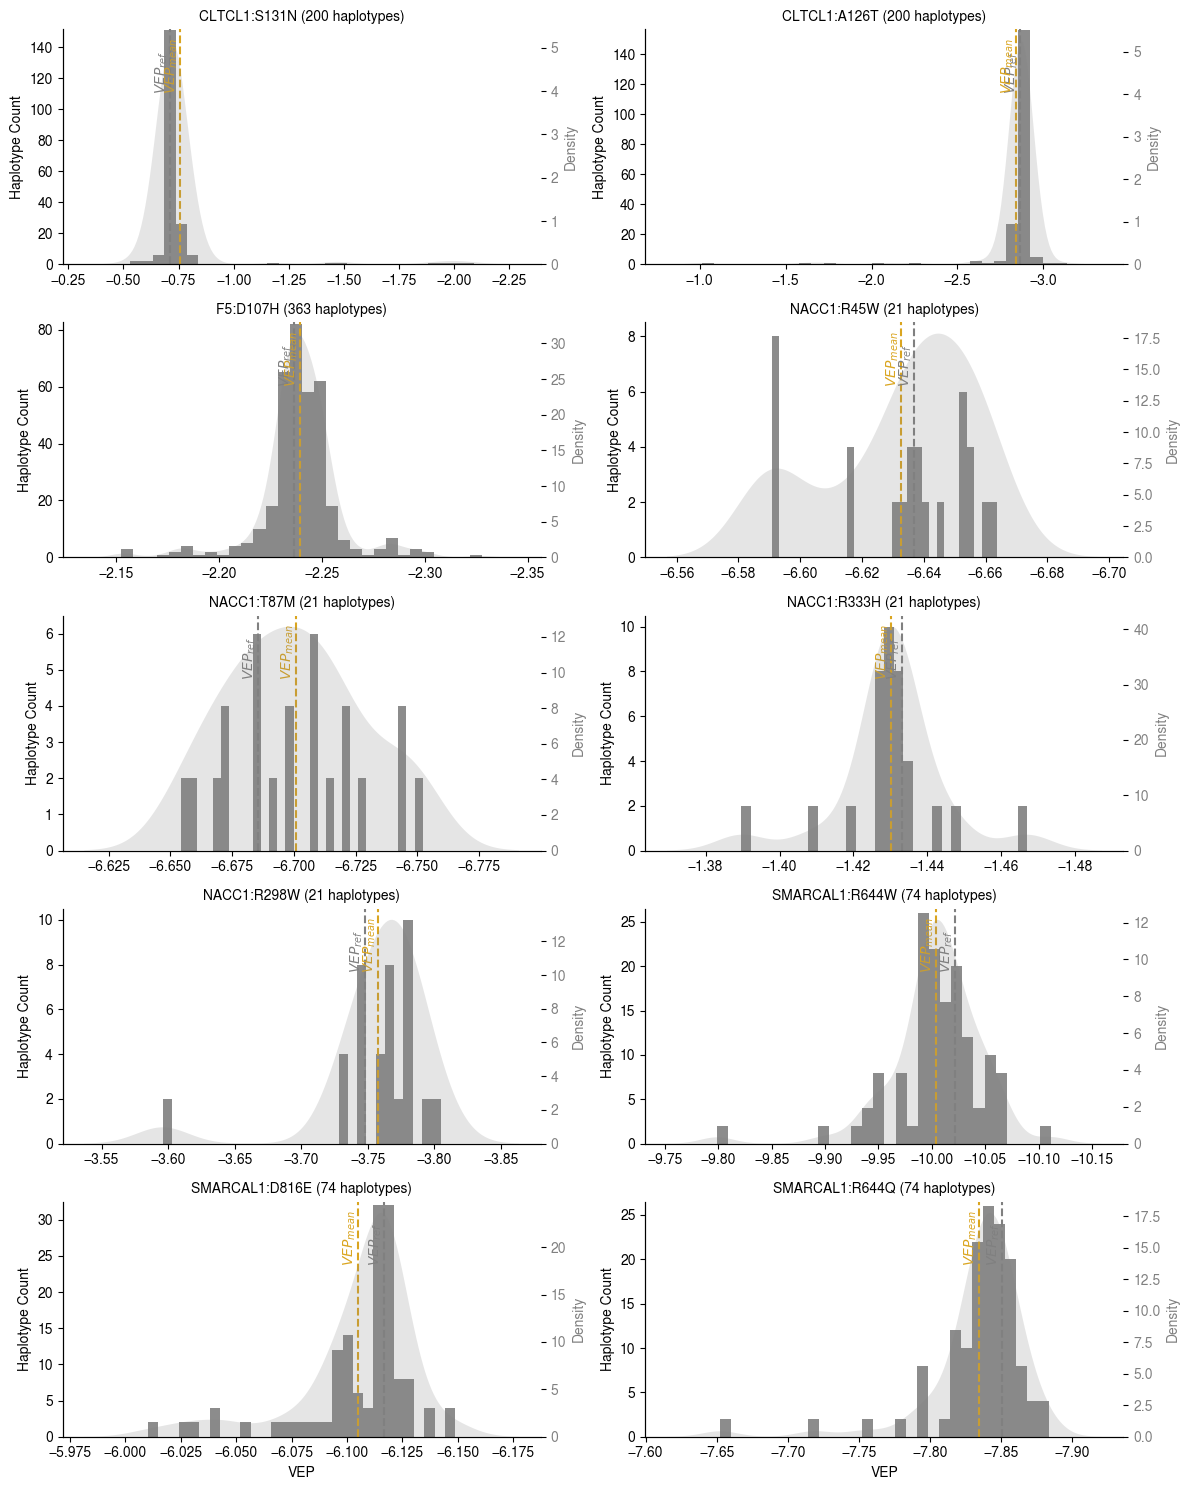

In [235]:
n_facets= 10
target_sites = entropy_df.sort_values(by="entropy_resid", ascending=False).iloc[:n_facets]["site"]
top_entropy_sites = gmm.plot_vep_histograms_with_boundaries(vep_df, boundary_crossing_df,
                                                              target_sites=target_sites, 
                                                              sharex=False,
                                                              sharey=False,
                                                              bins=30)
top_entropy_sites["fig"].savefig("manuscript/fig/top_entropy_sites.pdf.pdf", **utils.FIG_SAVE_KWARGS)

### Variance ranking

In [260]:
from statsmodels import robust

tqdm.pandas()
mad_df = vep_df.groupby(["model_location", "scoring_strategy", "protein","Gene", "mutant", "site","clinsig"], observed=True).progress_apply(
    lambda x: robust.mad(x["VEP"], c=1)
).reset_index().rename(columns={0:"MAD"}).sort_values(by="MAD", ascending=False)


  0%|          | 0/56364 [00:00<?, ?it/s]

/home/schilder/.conda/envs/esm2/lib/python3.12/site-packages/tqdm/std.py:917: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return getattr(df, df_function)(wrapper, **kwargs)


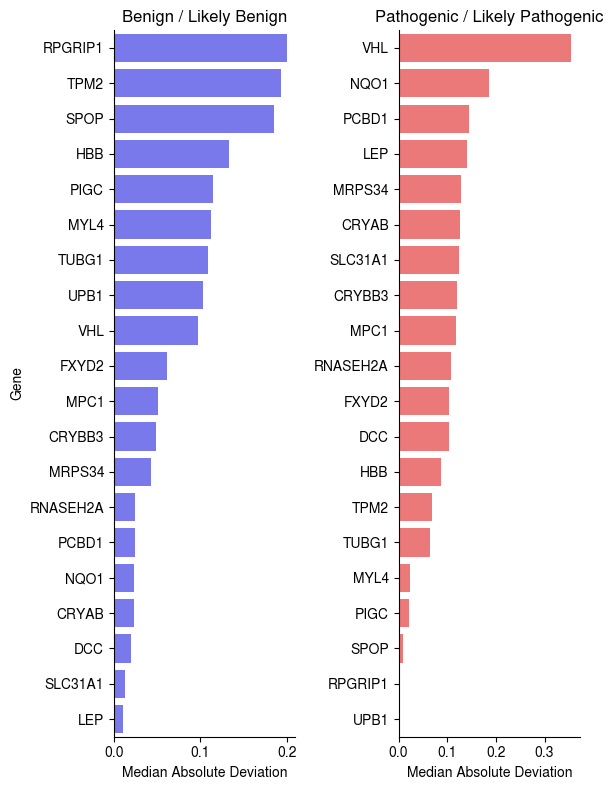

In [308]:
# Compute mean MAD per gene and clinsig
# Reassign "likely_benign" to "benign" and "likely_path" to "path" in the "clinsig" column
mad_df["clinsig"] = mad_df["clinsig"].replace({"likely_benign": "benign", "likely_path": "path"})

mad_plot_df = mad_df.groupby(["Gene", "clinsig"])["MAD"].mean().reset_index()

# Select top N genes by MAD in any clinsig category
top_n = 20
top_genes = (
    mad_plot_df.groupby("Gene")["MAD"].max()
    .sort_values(ascending=False)
    .head(top_n)
    .index
)
mad_plot_df = mad_plot_df[mad_plot_df["Gene"].isin(top_genes)]

# Get clinsig categories in desired order
clinsig_order = utils.get_clinsig_order()
clinsig_present = [c for c in clinsig_order if c in mad_plot_df["clinsig"].unique()]
n_clinsig = len(clinsig_present)

# Create subfigures (one column per clinsig)
fig, axes = plt.subplots(1, n_clinsig, figsize=(3*n_clinsig, 8), sharey=False)
if n_clinsig == 1:
    axes = [axes]

for ax, clinsig in zip(axes, clinsig_present):
    data = mad_plot_df[mad_plot_df["clinsig"] == clinsig].sort_values("MAD", ascending=False)
    sns.barplot(
        data=data,
        x="MAD",
        y="Gene",
        hue="clinsig",
        palette=utils.get_clinsig_palette(),
        orient="h",
        ax=ax
    )
    ax.set_title("Benign / Likely Benign" if clinsig == "benign" else "Pathogenic / Likely Pathogenic")
    ax.set_xlabel("Median Absolute Deviation")
    if ax != axes[0]:
        ax.set_ylabel("")
    else:
        ax.set_ylabel("Gene")
    ax.legend().remove()
    # Remove top and right borders
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)



plt.tight_layout()


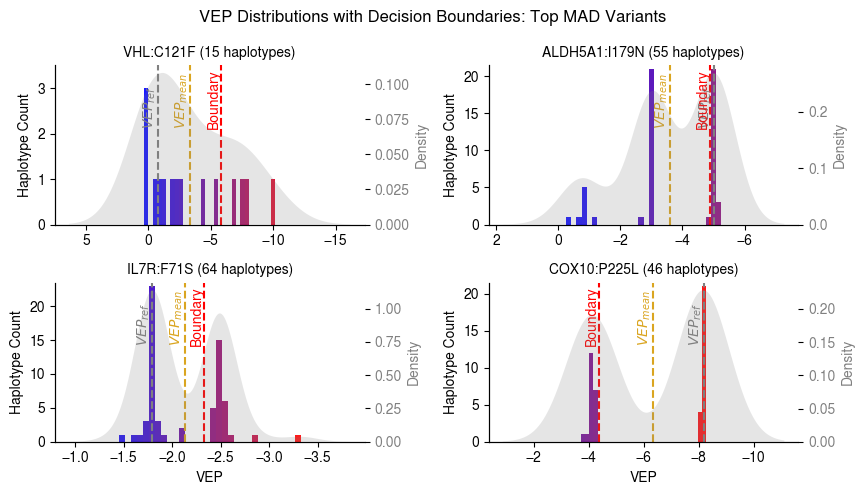

In [346]:
n_facets = 4
# Filter to sites with sufficient haplotypes and not in VHL
no_no_genes  = ["RPGRIP1","PRNP"]
pos_diff_sites = vep_df.loc[(vep_df["n_haplotypes"] > 10) & (~vep_df["Gene"].isin(no_no_genes)), 'site'].unique()
# Subset mad_df to those sites
filtered_mad_df = mad_df.loc[(mad_df["site"].isin(pos_diff_sites)) & (mad_df["protein"].isin(boundary_crossing_df["protein"].unique()))]
# For each gene, select the variant (site) with the highest MAD
top_mad_per_gene = (
    filtered_mad_df.sort_values("MAD", ascending=False)
    .drop_duplicates(subset="Gene", keep="first")
)
# Select up to n_facets top variants (one per gene)
target_sites = top_mad_per_gene.iloc[:n_facets]["site"]
top_mad_sites = gmm.plot_vep_histograms_with_boundaries(vep_df.loc[vep_df["site"].isin(target_sites)], boundary_crossing_df,
                                                              target_sites=target_sites, 
                                                              title="VEP Distributions with Decision Boundaries: Top MAD Variants",
                                                              sharex=False,
                                                              sharey=False,
                                                               y_offset_factor = 0.6,
                                                            # x_offset = 0.01,
                                                              bins=30)
top_mad_sites["fig"].savefig("manuscript/fig/boundaries_top_mad.pdf", **utils.FIG_SAVE_KWARGS)

#### VEPref - VEPmean difference ranking

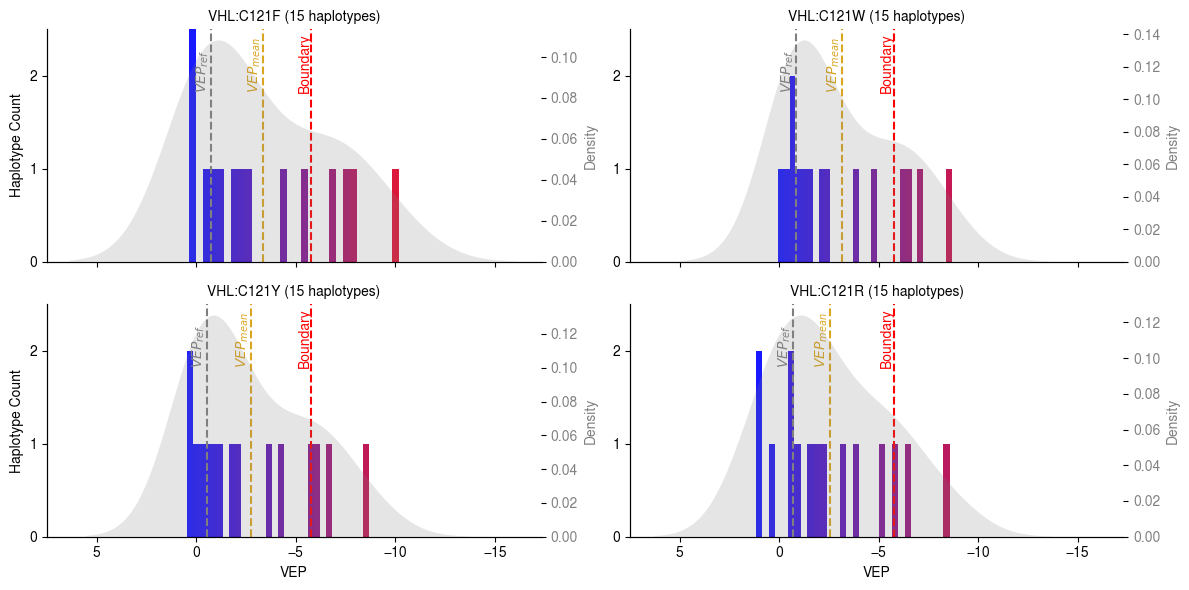

In [ ]:
n_facets= 4
target_sites = diff_df.loc[diff_df["VEP_mean_diff"] > 0, "site"].iloc[:n_facets]
underestimates_path = gmm.plot_vep_histograms_with_boundaries(vep_df, boundary_crossing_df,
                                                              target_sites=target_sites, 
                                                              sharex=True,
                                                              sharey=True,
                                                              bins=30)
underestimates_path["fig"].savefig("manuscript/fig/boundaries_underestimates_path.pdf", **utils.FIG_SAVE_KWARGS)

In [188]:
underestimates_path["data"].groupby("site").size()

/tmp/ipykernel_940401/303326205.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  underestimates_path["data"].groupby("site").size()


site
NP_937799.1:C121F    15
NP_937799.1:C121W    15
NP_937799.1:C121Y    15
NP_937799.1:C121R    15
dtype: int64

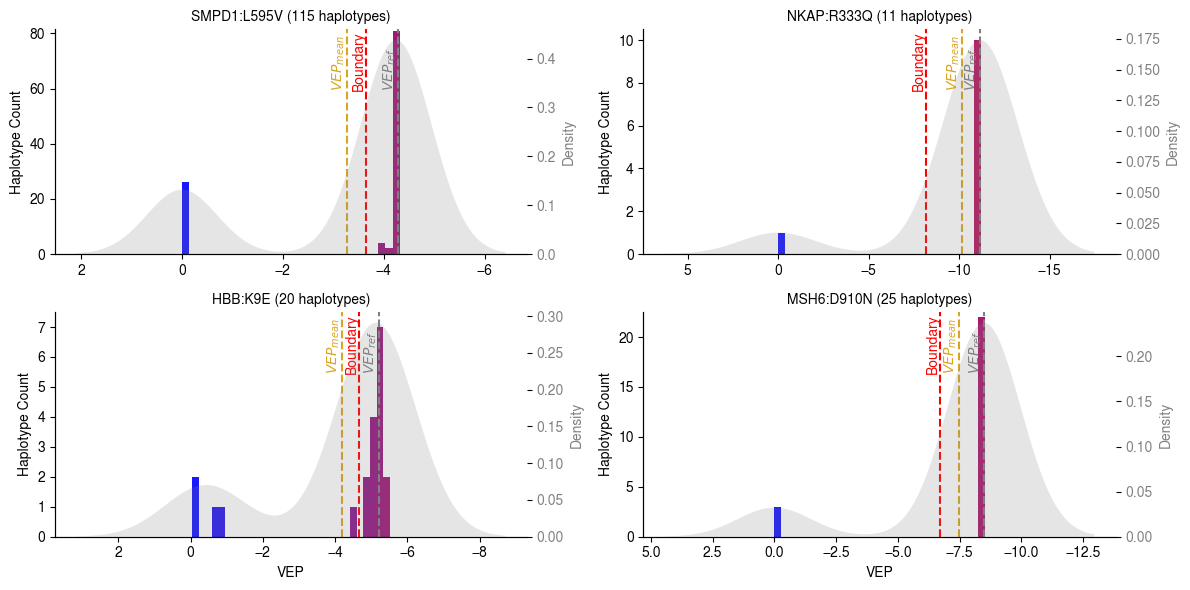

In [190]:
n_facets= 4
target_sites = diff_df.loc[diff_df["VEP_mean_diff"] < 0, "site"].iloc[:n_facets]
overestimates_path = gmm.plot_vep_histograms_with_boundaries(vep_df, boundary_crossing_df,
                                                              target_sites=target_sites, 
                                                              sharex=False,
                                                              sharey=False,
                                                              bins=30)
overestimates_path["fig"].savefig("manuscript/fig/boundaries_overestimates_path.pdf", **utils.FIG_SAVE_KWARGS)

Sampling 10 rows from 137
                                      mutant  protein
model_location      scoring_strategy                 
esm2_t33_650M_UR50D masked-marginals      10        5


<string>:93: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
<string>:157: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


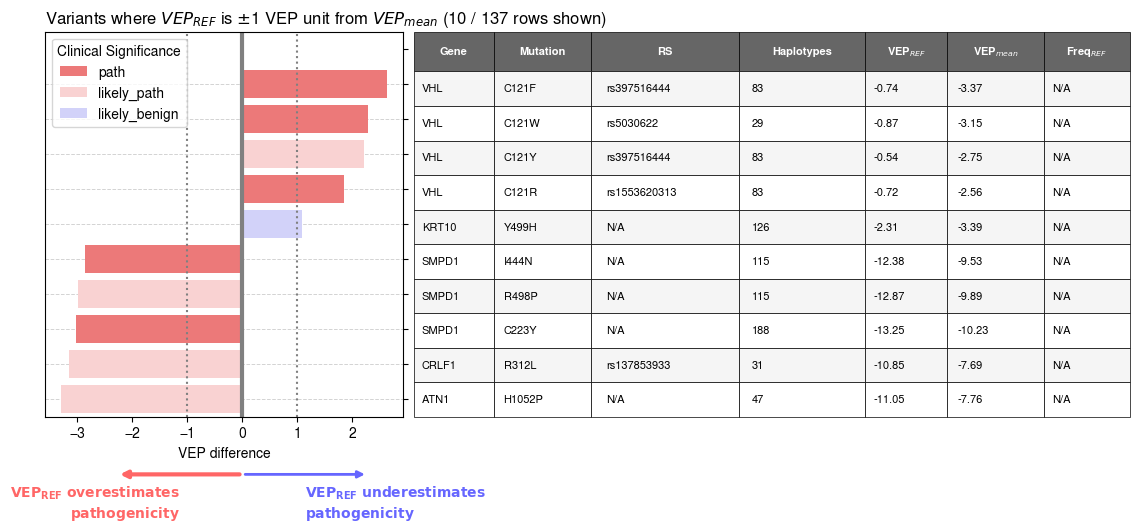

In [163]:
plot_top_diff_variants_out1 = va.plot_top_diff_variants(vep_df, 
                          freq_df, 
                          x="VEP_mean_diff", 
                          title=  r"Variants where $\it{VEP_{REF}}$ is $\pm$1 VEP unit from $\it{VEP_{mean}}$",
                          max_rows=10,
                          figsize=(14, None),
                          sample_head_and_tail=True,
                          arrow_bottom_margin=0.15,
                          arrow_text_padding=0.025,
                          table_width_ratio=2,
                          is_ref_filter=True)
plot_top_diff_variants_out1["fig"].savefig("manuscript/fig/top_diff_variants_VEPmean_diff.pdf", **utils.FIG_SAVE_KWARGS)

In [171]:
(plot_top_diff_variants_out1["data"].iloc[:4]["VEP_mean"] / plot_top_diff_variants_out1["data"].iloc[:4]["VEP_REF"]).describe()

count    4.000000
mean     4.195694
std      0.734671
min      3.579087
25%      3.595634
50%      4.063326
75%      4.663386
max      5.077035
dtype: float64

Sampling 10 rows from 13095
                                      mutant  protein
model_location      scoring_strategy                 
esm2_t33_650M_UR50D masked-marginals       7        5


<string>:93: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
<string>:157: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


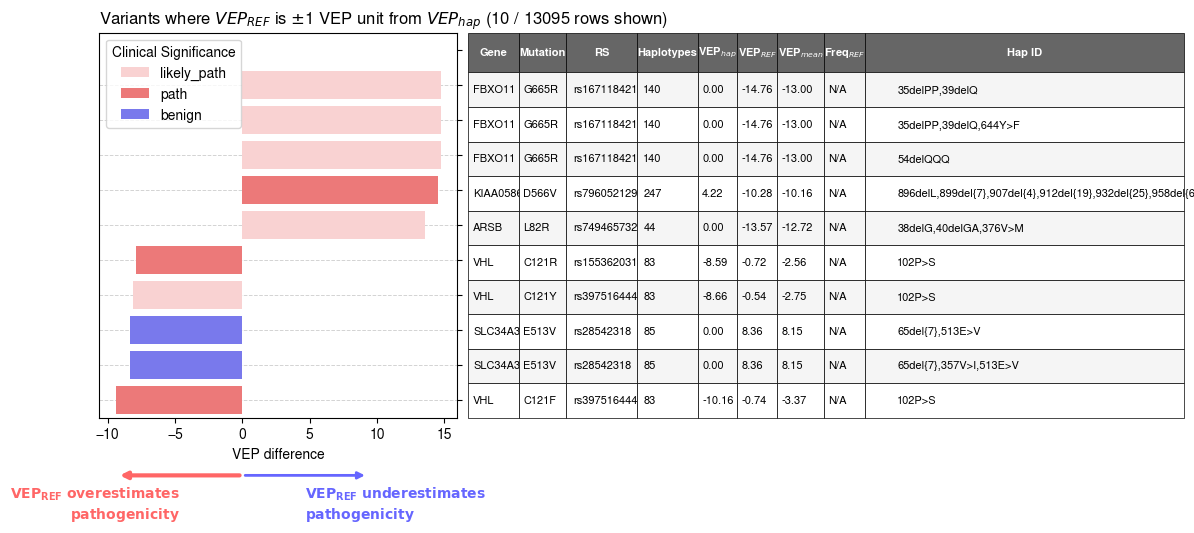

In [164]:
plot_top_diff_variants_out2 = va.plot_top_diff_variants(vep_df, 
                          freq_df, 
                          x="VEP_ref_diff", 
                          title=  r"Variants where $\it{VEP_{REF}}$ is $\pm$1 VEP unit from $\it{VEP_{hap}}$",
                          max_rows=10,
                          figsize=(14, None),
                          sample_head_and_tail=True,
                          arrow_bottom_margin=0.15,
                          arrow_text_padding=0.025,
                          table_width_ratio=2,
                          is_ref_filter=None)
plot_top_diff_variants_out2["fig"].savefig("manuscript/fig/top_diff_variants_VEPhap_diff.pdf", **utils.FIG_SAVE_KWARGS)

In [153]:
import matplotlib.pyplot as plt

# Create bins: '<-1', '-1 to 1', '>1'
bins = pd.cut(
    vep_df.loc[~vep_df["is_ref"], "VEP_ref_diff"],
    bins=[-float('inf'), -1, 1, float('inf')],
    labels=['<-1', '-1 to 1', '>1']
)
bin_counts = bins.value_counts().sort_index()
bin_counts
 

VEP_ref_diff
<-1           2173
-1 to 1    3760697
>1           10922
Name: count, dtype: int64

## Figure S4

Proportion of gained/lost contacts per superpopulation: weighted proportional to haplotype frequency within each superpopulation.

## Figure S5

Binary pathogenic/benign classifier results.

In [1]:
lr_dict = {} 
lr_gene_dict = {}
min_values_per_label= 10

ESM

In [ ]:
# Gather data from each model and compute logreg results

#### Run for all models ####
from IPython.display import clear_output
force = False

for model_location in va.list_all_models():
    print(f"Processing {model_location}") 
    save_path = os.path.join("results/data/","vep_df_"+model_location+".parquet")
    
    if os.path.exists(save_path) and not force:
        print(f"Loading {save_path}")
        vep_tmp = pd.read_parquet(save_path)
    else:
        vep_files_model = va.list_vep_files(model_location=model_location, as_df=True)
        vep_tmp = va.merge_vep(add_metadata=True, 
                                scoring_strategy=["masked-marginals"], 
                                vep_files=vep_files_model
                                )
        print(f"Saving {save_path}")
        vep_tmp.to_parquet(save_path)

    # Run logreg analysis
    lr_dict[model_location] = bcv.run_clinvar_logreg_analysis(vep_tmp, 
                                                                clinsig_col="clinsig",
                                                                site_col="site") 

    lr_gene_dict[model_location] = bcv.run_clinvar_logreg_analysis_by_group(vep_tmp, 
                                                group_by="protein",
                                                vep_col="VEP",
                                                clinsig_col="clinsig",
                                                min_values_per_label=min_values_per_label,
                                                site_col="site" ) 
    clear_output()
del vep_tmp

#### Run for just the main ESM model ####
# lr_dict[model_name] = bcv.run_clinvar_logreg_analysis(vep_df, 
#                                             clinsig_col="clinsig",
#                                             site_col="site") 
# lr_gene_dict[model_name] = bcv.run_clinvar_logreg_analysis_by_group(vep_df, 
#                                                 group_by="protein",
#                                                 vep_col="VEP",
#                                                 clinsig_col="clinsig",
#                                                 min_values_per_label=min_values_per_label,
#                                                 site_col="site" )
    

SpliceAI

In [10]:
lr_dict['SpliceAI'] = bcv.run_clinvar_logreg_analysis(spliceai_df, 
                                                        clinsig_col="CLNSIG_simplified",
                                                        site_col="site")  

Running logistic regression for REF
Running logistic regression for non-REF


In [11]:
lr_gene_dict['SpliceAI']= bcv.run_clinvar_logreg_analysis_by_group(spliceai_df, 
                                                                    group_by="protein",
                                                                    vep_col="VEP",
                                                                    clinsig_col="CLNSIG_simplified",
                                                                    min_values_per_label=min_values_per_label)

Groups:   0%|          | 0/1836 [00:00<?, ?it/s]

/home/schilder/.conda/envs/esm2/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/schilder/.conda/envs/esm2/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/schilder/.conda/envs/esm2/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

Flashzoi

In [12]:
lr_dict['Flashzoi'] = bcv.run_clinvar_logreg_analysis(flashzoi_df, 
                                                        clinsig_col="CLNSIG_simple",
                                                        site_col="site") 

Running logistic regression for REF
Running logistic regression for non-REF


In [13]:
lr_gene_dict['Flashzoi'] = bcv.run_clinvar_logreg_analysis_by_group(flashzoi_df, 
                                                                    group_by="protein",
                                                                    vep_col="VEP",
                                                                    clinsig_col="CLNSIG_simple",
                                                                    min_values_per_label=min_values_per_label)

Groups:   0%|          | 0/1464 [00:00<?, ?it/s]

/home/schilder/.conda/envs/esm2/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/schilder/.conda/envs/esm2/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/schilder/.conda/envs/esm2/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

Uncorrected for gene bias.

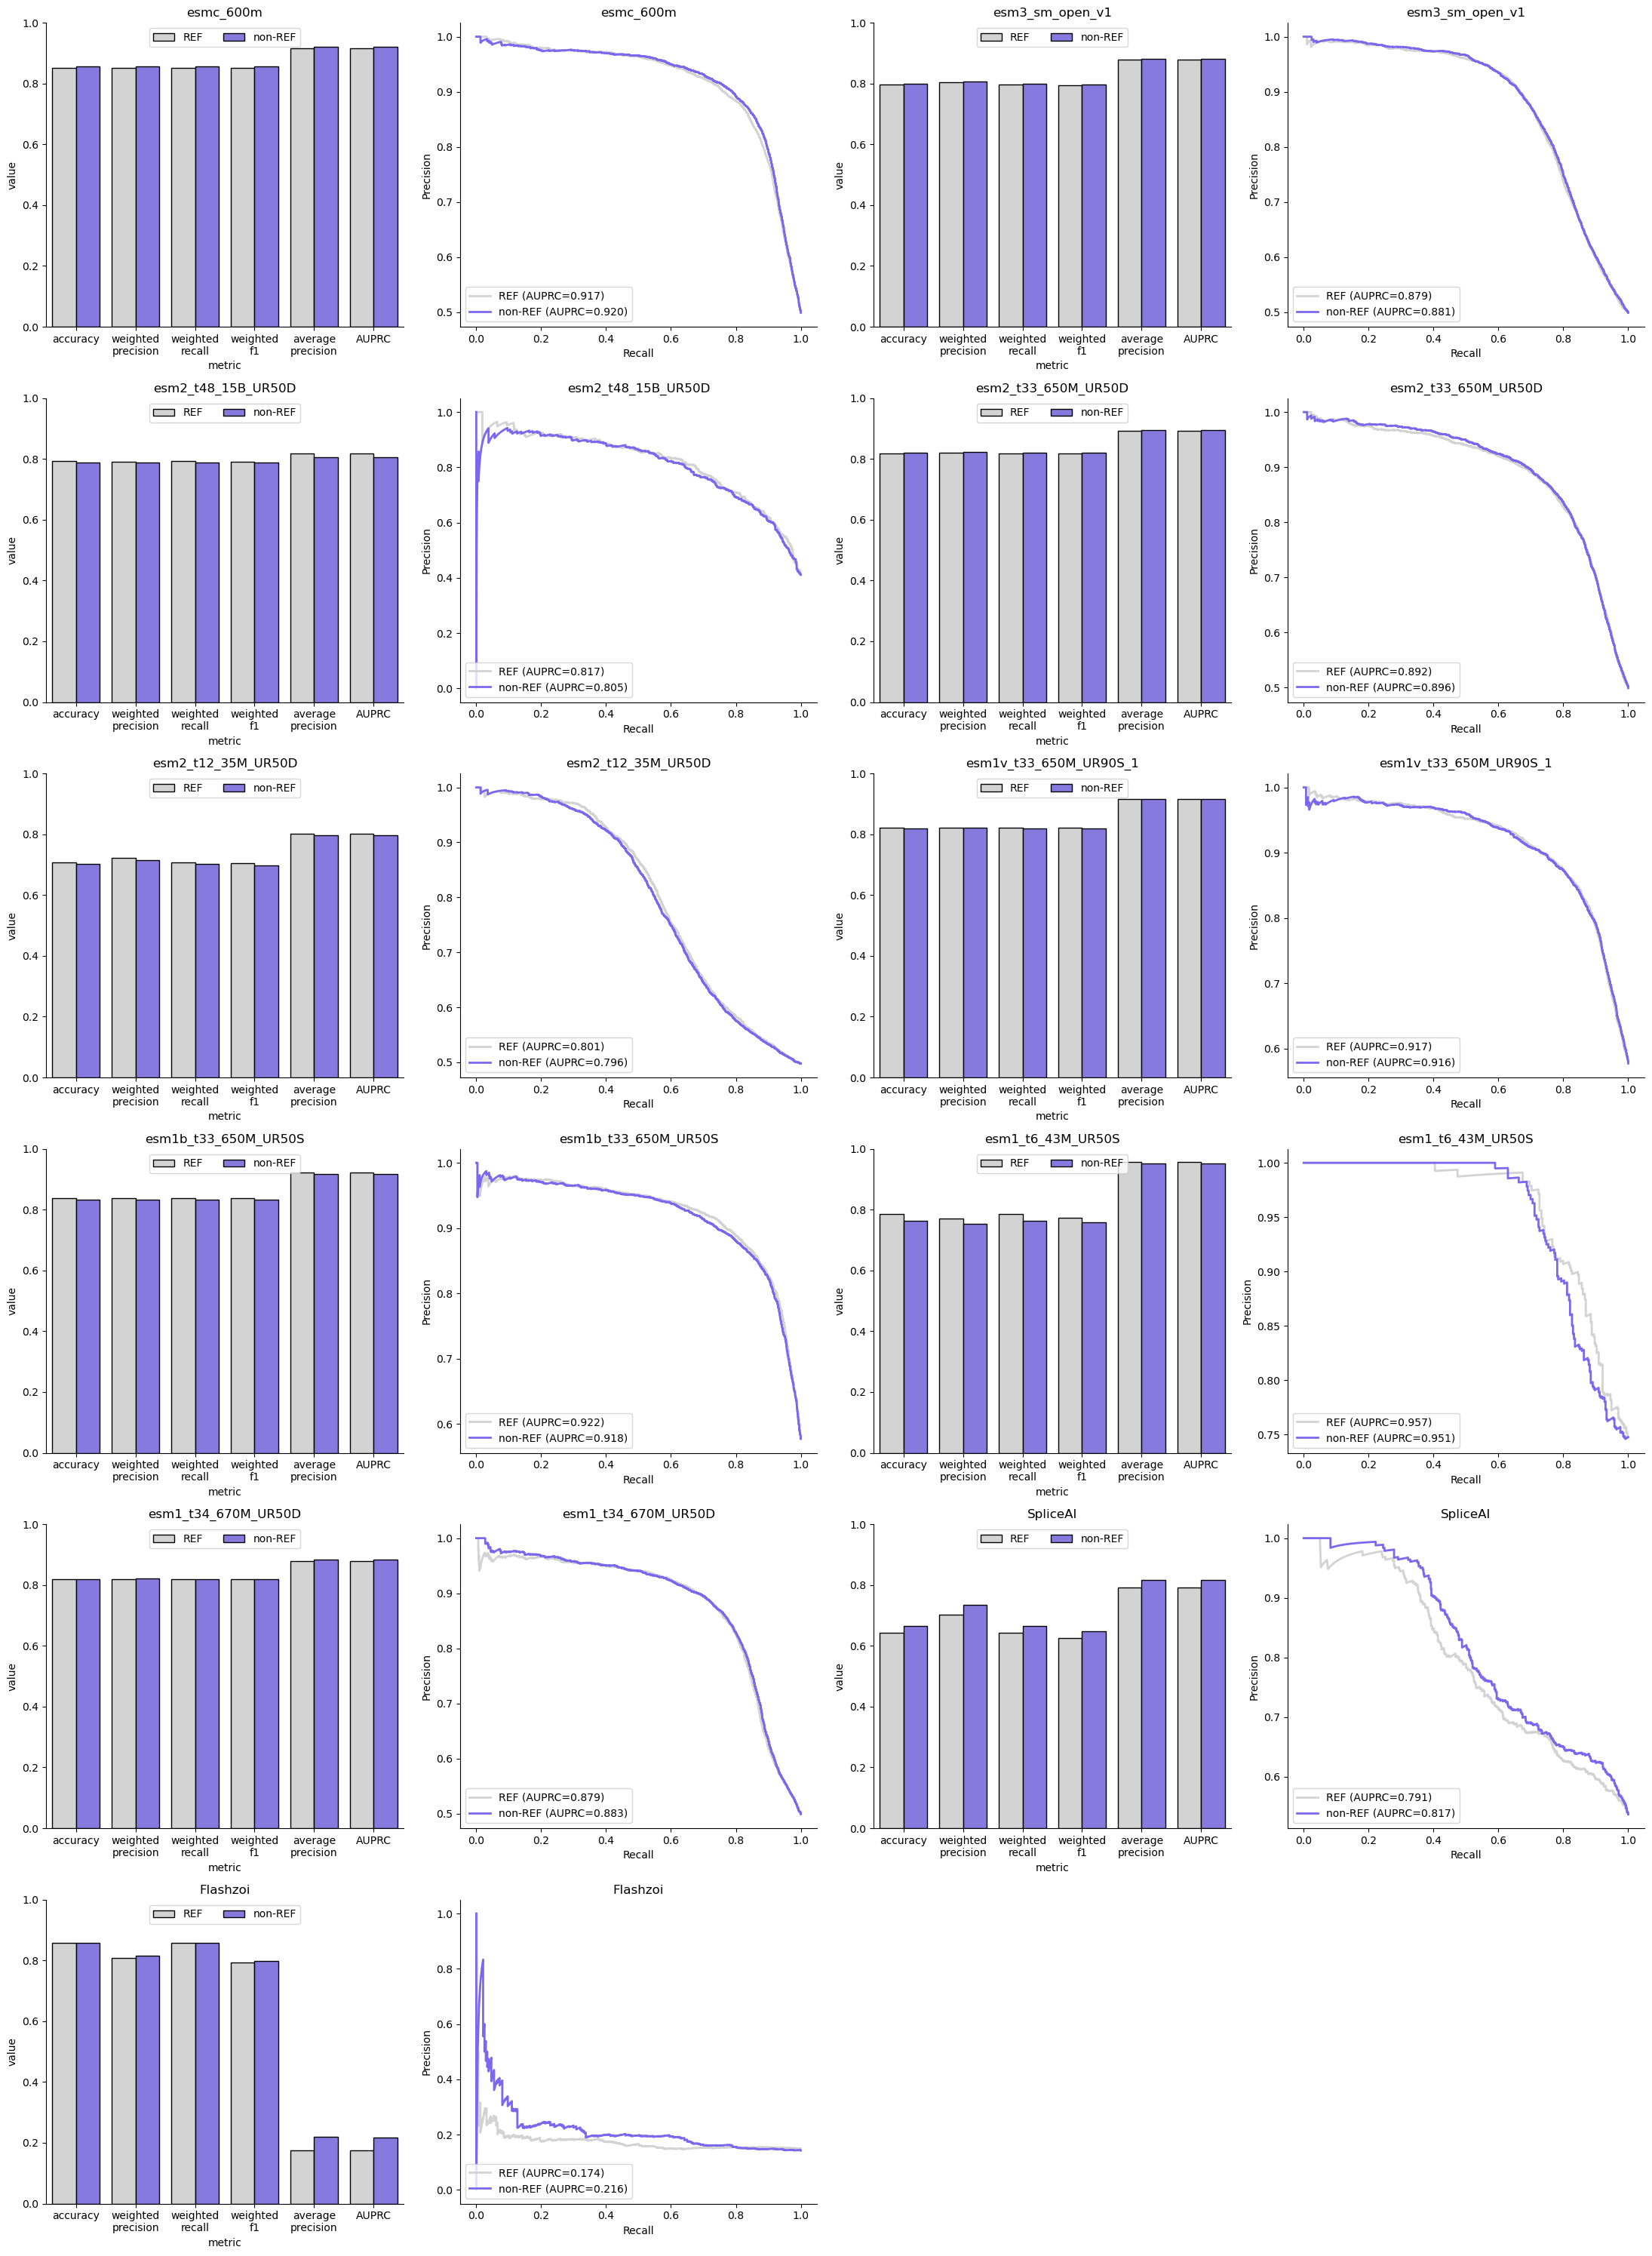

In [64]:
plot_logreg_results_subplots_out = bcv.plot_logreg_results_subplots(
      palette=utils.get_ref_nonref_palette(),
    data_dict = lr_dict,
    figsize = (11, 5),
    colwrap=2
)

In [ ]:
# Determine if non-REF beats REF for each model/metric
pivot_df = plot_logreg_results_subplots_out["data"]["barplot_df"].pivot_table(
    index=["model", "metric"],
    columns="group_id",
    values="value"
).reset_index()
pivot_df["nonREF_beats_REF"] = pivot_df["non-REF"] > pivot_df["REF"] 
print("Proportion of models/metrics where non-REF beats REF:",pivot_df["nonREF_beats_REF"].sum() / pivot_df.shape[0] * 100)

Proportion of models/metrics where non-REF beats REF:  54.54545454545454


Corrected for gene bias.

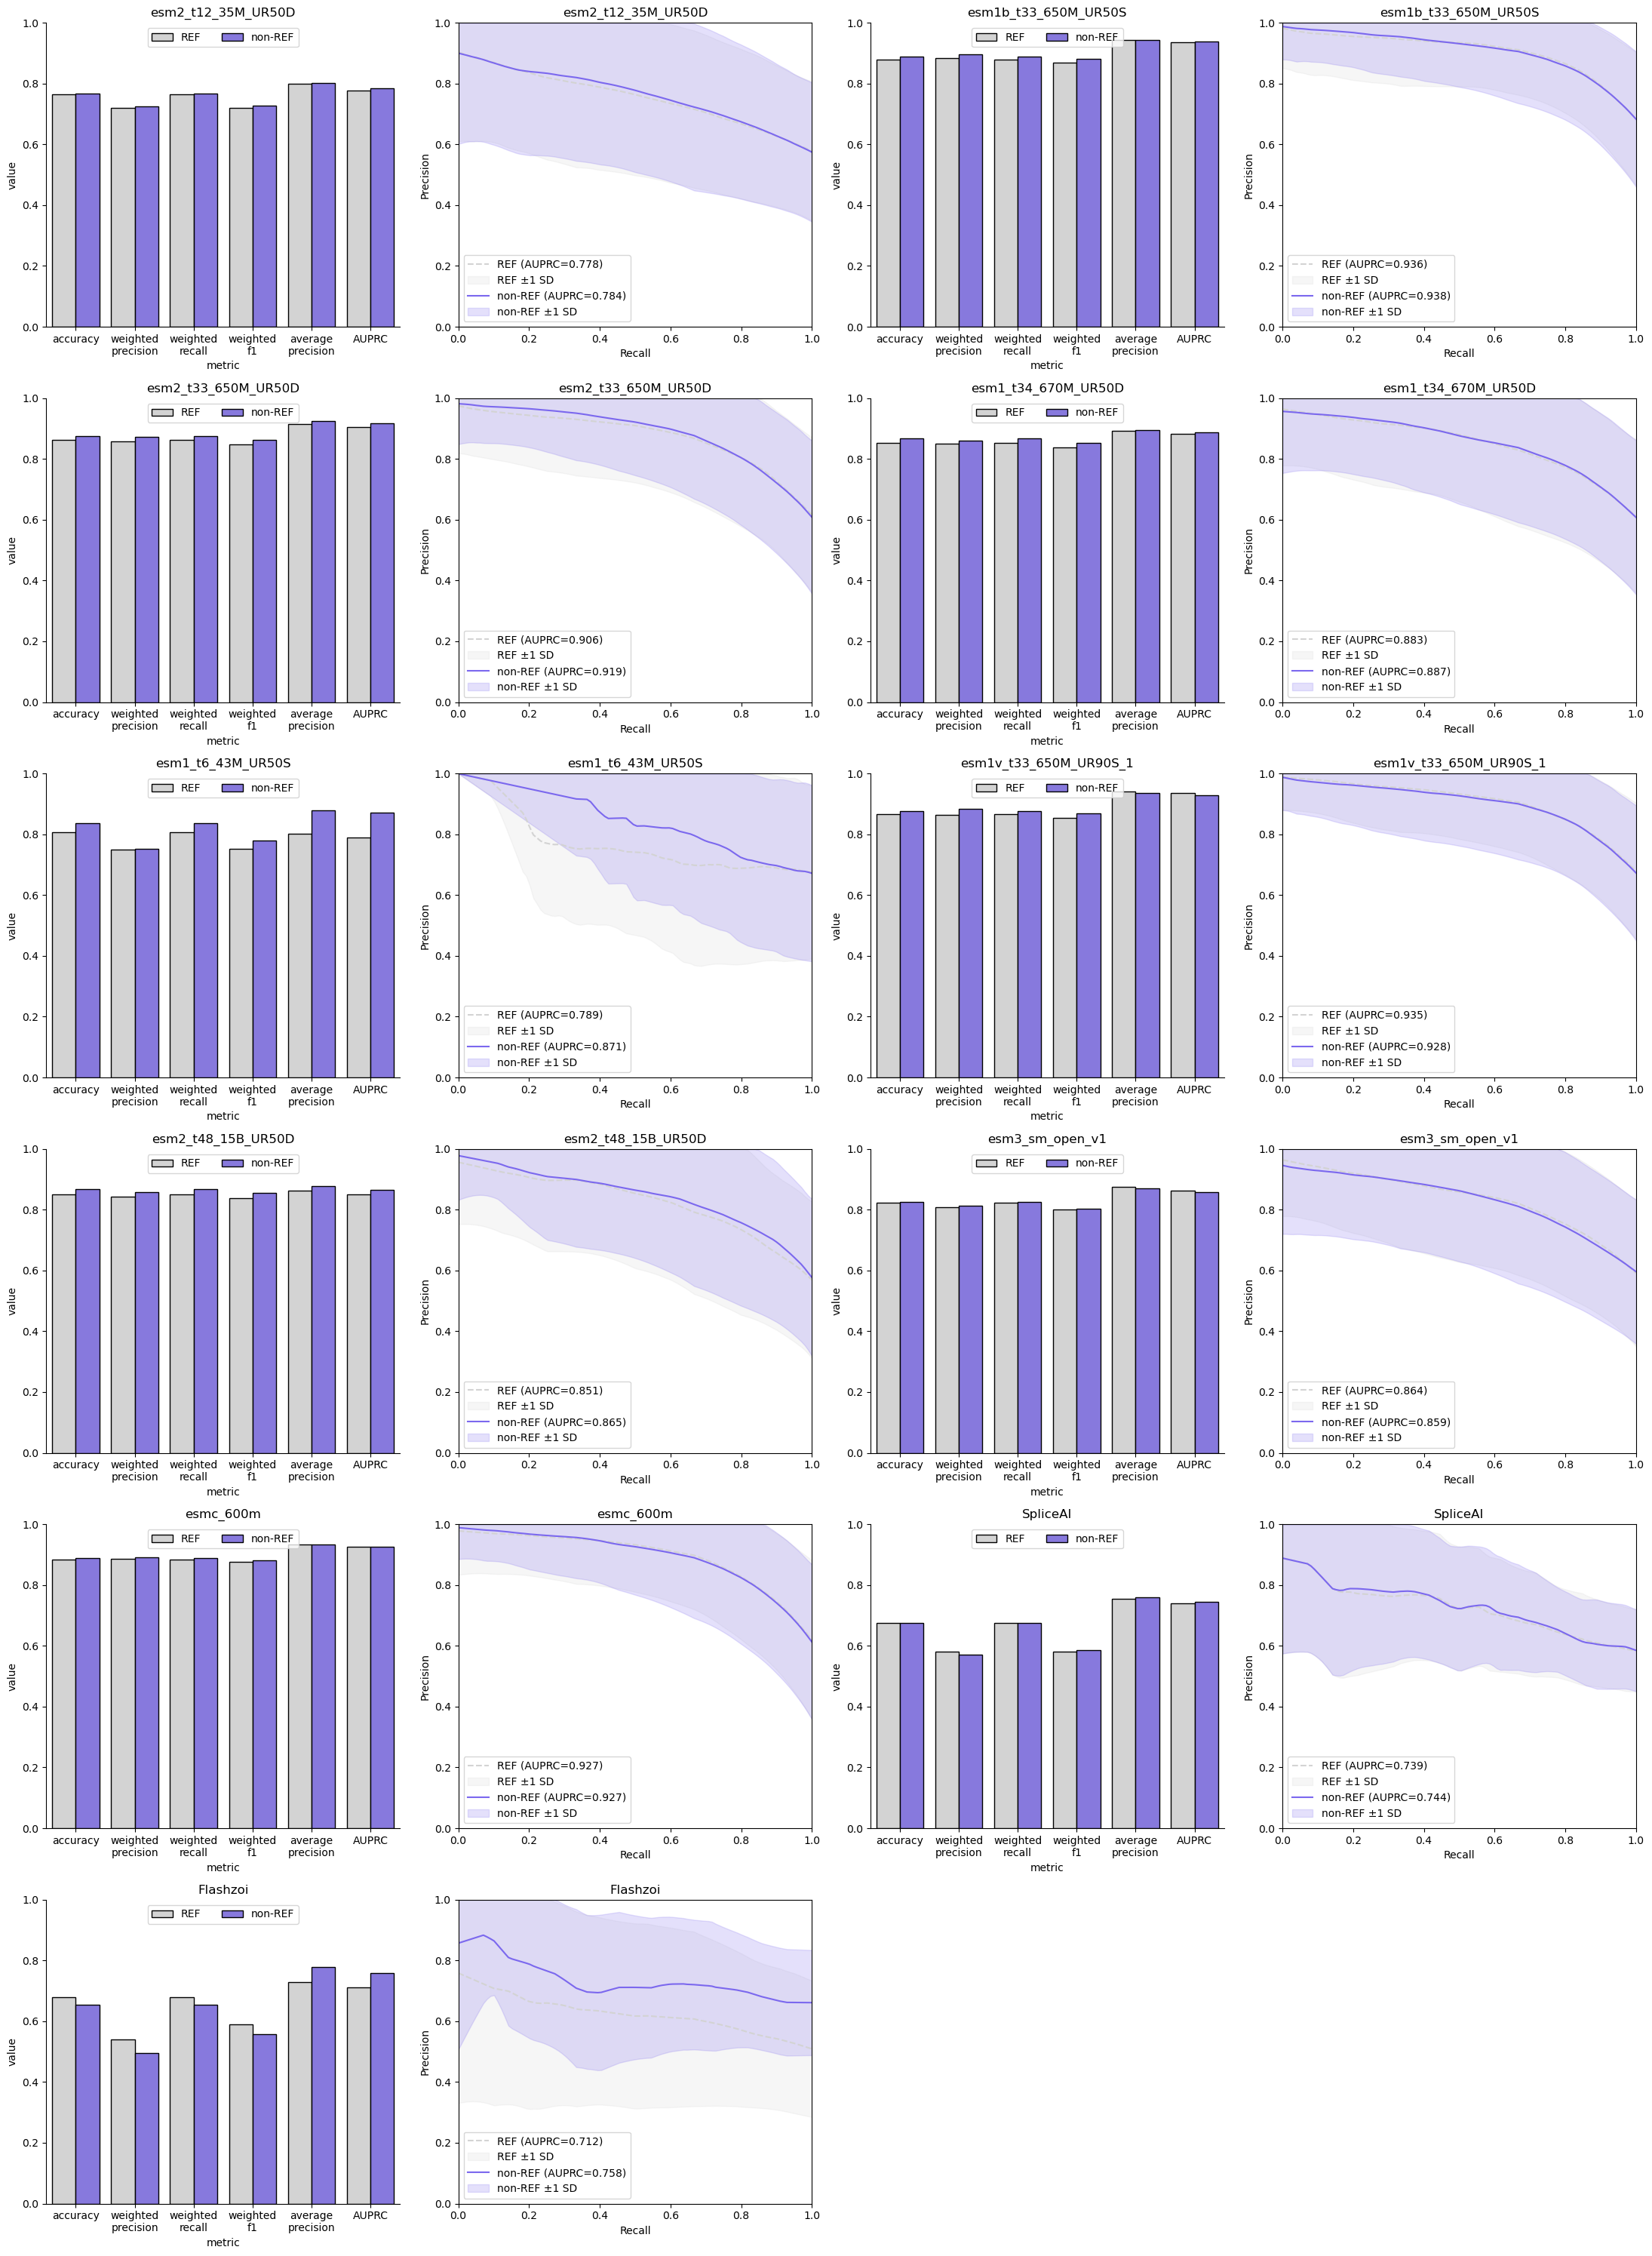

In [61]:
plot_logreg_gene_subplots_out = bcv.plot_logreg_gene_subplots(
    palette=utils.get_ref_nonref_palette(),
    data_dict = lr_gene_dict,
    figsize = (11, 5),
    colwrap=2
)
plot_logreg_gene_subplots_out["fig"].savefig("manuscript/fig/figS5.png", **utils.FIG_SAVE_KWARGS)

In [ ]:
# Determine if non-REF beats REF for each model/metric
pivot_df = plot_logreg_gene_subplots_out["data"]["barplot_df"].pivot_table(
    index=["model", "metric"],
    columns="group_id",
    values="value"
).reset_index()
pivot_df["nonREF_beats_REF"] = pivot_df["non-REF"] > pivot_df["REF"] 
print("Proportion of models/metrics where non-REF beats REF:",pivot_df["nonREF_beats_REF"].sum() / pivot_df.shape[0] * 100)

Proportion of models/metrics where non-REF beats REF:  80.3030303030303


## Figure S6

In [75]:
pg_df = pg.merge_resources()
pg_df.loc[pg_df["genename"]=="TP53"]

ProteinGym: Gathering resources:   0%|          | 0/2 [00:00<?, ?it/s]

,protein,RefSeq peptide ID,source_file,source_type,experiment_id,genename,ENSG,ENST,ENSP
2062,NP_000537.3,NP_000537,/home/schilder/.cache/ProteinGym/v1.1/clinical...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000537.3,TP53,ENSG00000141510,ENST00000269305,ENSP00000269305
2063,NP_000537.3,NP_000537,/home/schilder/.cache/ProteinGym/v1.1/clinical...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000537.3,TP53,ENSG00000141510,ENST00000359597,ENSP00000352610
2064,NP_000537.3,NP_000537,/home/schilder/.cache/ProteinGym/v1.1/clinical...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000537.3,TP53,ENSG00000141510,ENST00000413465,ENSP00000410739
3152,NP_000537.3,NP_000537,/home/schilder/.cache/ProteinGym/v1.1/clinical...,clinical_ProteinGym_indels,clinical_ProteinGym_indels/NP_000537.3,TP53,ENSG00000141510,ENST00000269305,ENSP00000269305
3153,NP_000537.3,NP_000537,/home/schilder/.cache/ProteinGym/v1.1/clinical...,clinical_ProteinGym_indels,clinical_ProteinGym_indels/NP_000537.3,TP53,ENSG00000141510,ENST00000359597,ENSP00000352610
3154,NP_000537.3,NP_000537,/home/schilder/.cache/ProteinGym/v1.1/clinical...,clinical_ProteinGym_indels,clinical_ProteinGym_indels/NP_000537.3,TP53,ENSG00000141510,ENST00000413465,ENSP00000410739


In [123]:
uniprot_ids = {"BRCA1":"P38398", 
               "DYPD":"Q12882",
               "TP53":"P04637"}
tx_ids = {"BRCA1":"ENST00000357654", 
          "DYPD":"ENST00000370192",
          "TP53":"ENST00000269305"}  # ENST00000269305, ENST00000359597, ENST00000413465
refseq_ids = {"BRCA1": 'NP_009225.1',
              "DYPD": 'NP_000101.2',
              "TP53": 'NP_000537.3'}

# Get specific instance of the protein
target_gene = "TP53"
uniprot_id = uniprot_ids[target_gene]
refseq_id = refseq_ids[target_gene]
tx_id = tx_ids[target_gene] 

In [124]:

#### Import directly from AlphaFoldDB ####
# structure = cf.import_mmcif(protein_id = uniprot_id)[0]
# contact_map_ref = cf.get_contact_map(structure,  
#                                  return_distance_map=True,
#                                  continuous=True )
# contact_map_dist_ref = cf.get_contact_map(structure,  
#                                return_raw_distance_map=True )

# contact_map_binary_ref = cf.get_contact_map(structure,
#                                                 max_distance=8.0, 
#                                                 continuous=False, 
#                                                 return_distance_map=False) 

# #### Import from local AlphaFold files that I generated myself ####
pdb_files = cf.search_files(base_dir =  os.path.expanduser("~/projects/data/colabfold"),
                            tx_id = tx_id,
                            subdir = "af2_sameMSA",
                            suffix = ".pdb*",
                            model_number = 1,
                            ref_only = True) 

contact_map_ref = cf.import_contact_maps(pdb_files,
                                        return_distance_map=True,
                                        continuous=True,
                                        as_dict=False)  


contact_map_dist_ref = cf.import_contact_maps(pdb_files,
                                            return_raw_distance_map=True,
                                            as_dict=False)  
contact_map_binary_ref = cf.import_contact_maps(pdb_files,
                                                max_distance=8.0, 
                                                continuous=False, 
                                                return_distance_map=False,
                                                as_dict=False ) 


1 PDB files found


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00, 42.95it/s]


Contact enrichment for BRCA1 WT vs. Clinical variant interactions.

In [125]:
model_name = "esm2_t33_650M_UR50D"
force = False

if 'vep_files' not in globals() or force:
    vep_files = va.list_vep_files(model_location=model_name, 
                                  as_df=True)

vep_prot = va.merge_vep(
    scoring_strategy=["masked-marginals"],
    vep_files=vep_files.loc[(vep_files['model_location']==model_name) & 
                            (vep_files['protein']==refseq_id)]
    )
print("n_haplotypes: ", vep_prot["haplotype"].nunique())
vep_prot["HGNC"] = vep_prot["GENEINFO"].str.split(":").str[0]  


No save_dir provided, using: /home/schilder/projects/data/1KG/vep
Found 26 masked-marginals parquet files


Reading files:   0%|          | 0/26 [00:00<?, ?it/s]

Concatenating VEP dataframes
Loading ==> /home/schilder/projects/data/haplosaurus/tx_id_map.pkl


Loading '/home/schilder/projects/data/haplosaurus/tx_id_map.pkl': 100%|██████████| 1.70M/1.70M [00:00<00:00, 7.85GB/s]


VEP dataframe shape: (7046, 73)
n_haplotypes:  26


Use ridge regression to find WT-Clinical variant interactions.

In [126]:
wtvariants_to_vep_linear_model_out = ab.wtvariants_to_vep_linear_model(vep_df=vep_prot,
                                                                       alpha=1)  
utils.save_pickle(wtvariants_to_vep_linear_model_out, 
        f"results/data/wtvariants_to_vep_linear_model_out_{target_gene}.pkl")
ridge_df = wtvariants_to_vep_linear_model_out["interaction_df"]

vep_matrix shape:  (26, 271)
wt_matrix shape:  (26, 26)
Saving ==> results/data/wtvariants_to_vep_linear_model_out_TP53.pkl


### Figure 2A

DYPD AlphaFold contact map (reference sequence).

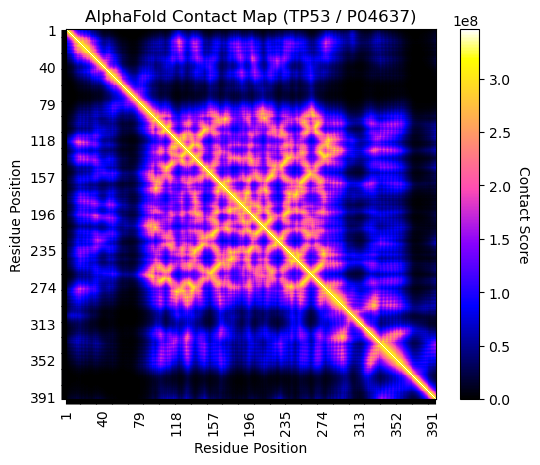

In [127]:
figS6a = cf.plot_contact_map(contact_map=contact_map_ref, 
                            title=f"AlphaFold Contact Map ({target_gene} / {uniprot_id})",  
                            bin_size=1,   
                            pow=4, 
                            agg_func=np.nanmax)
contact_map_ref  = figS6a["data"]["contact_map"]
contact_map_ref_binned = figS6a["data"]["contact_map_binned"]
figS6a['fig'].savefig("manuscript/fig/figS6a.png", **utils.FIG_SAVE_KWARGS)

### Figure 2B

DYPD sensitization map (aligned) +  DYPD AlphaFold contact map (reference sequence).

Choose a threshold for the interaction strength and compute the contact enrichment at that specific threshold.  
Then plot the contact map and the sensitization map.

In [128]:
interaction_threshold = 0.05

top_interactions = ridge_df.loc[ridge_df["interaction_strength"] > interaction_threshold]    

ridge_enrichment_at_threshold = ab.compute_enrichment_vs_threshold(
    outlier_df=ridge_df,
    contact_map_binary=contact_map_binary_ref, 
    thresholds=[interaction_threshold],
    linear_sampling=False,  
    interaction_col="interaction_strength"
)

print()
print(f"Number of top interactions: {top_interactions.shape[0]}" + \
      f" ({top_interactions.shape[0] / ridge_df.shape[0]*100:.2f}% of all WT-Clinical variant pairs)")
print(f"Enrichment at threshold {interaction_threshold}: {ridge_enrichment_at_threshold['enrichment'].values[0]:.2f}x" )

100%|██████████| 1/1 [00:00<00:00, 115.88it/s]


Number of top interactions: 578 (8.20% of all WT-Clinical variant pairs)
Enrichment at threshold 0.05: 9.40x


In [129]:
vep_prot.loc[(vep_prot["site"].isin(top_interactions["site"].head(10)))].groupby("site")["VEP"].mean().sort_values(ascending=False)
# vep_prot.loc[vep_prot["site"]=="NP_009225.1:V1687I"]["VEP"].hist(bins=50)

site
NP_000537.3:R213Q    -3.953045
NP_000537.3:G199V    -4.150334
NP_000537.3:H179Y    -6.292132
NP_000537.3:H179Q    -6.932359
NP_000537.3:R158S    -7.322601
NP_000537.3:D281N    -7.763233
NP_000537.3:R213P    -8.252064
NP_000537.3:D281G   -10.244985
NP_000537.3:D281V   -10.545165
NP_000537.3:D281Y   -10.916056
Name: VEP, dtype: float64

In [130]:
top_interactions.head(20)

,wt_variant,site,interaction_strength,interaction_strength_signed,outlier_type,n_haplotypes,interaction_strength_weighted,clinical_variant,wt_position,wt_REF,wt_ALT,clinical_position,clinical_REF,clinical_ALT
2354,215S>R,NP_000537.3:R213P,2.445649,2.445649,more benign,1,1.563857,R213P,215,S,R,213,R,P
2355,215S>R,NP_000537.3:R213Q,1.092954,1.092954,more benign,1,1.045444,R213Q,215,S,R,213,R,Q
3015,273R>H,NP_000537.3:D281N,0.857769,0.857769,more benign,1,0.926158,D281N,273,R,H,281,D,N
1447,175R>C,NP_000537.3:H179Y,0.846658,0.846658,more benign,1,0.920140,H179Y,175,R,C,179,H,Y
3016,273R>H,NP_000537.3:D281V,0.840008,0.840008,more benign,1,0.916519,D281V,273,R,H,281,D,V
3017,273R>H,NP_000537.3:D281Y,0.821178,0.821178,more benign,1,0.906189,D281Y,273,R,H,281,D,Y
1695,202R>C,NP_000537.3:G199V,0.788605,0.788605,more benign,1,0.888035,G199V,202,R,C,199,G,V
3014,273R>H,NP_000537.3:D281G,0.673420,0.673420,more benign,1,0.820622,D281G,273,R,H,281,D,G
2347,215S>R,NP_000537.3:R158S,0.645741,0.645741,more benign,1,0.803580,R158S,215,S,R,158,R,S
1446,175R>C,NP_000537.3:H179Q,0.610163,0.610163,more benign,1,0.781129,H179Q,175,R,C,179,H,Q


(393, 393)
Adding rectangles


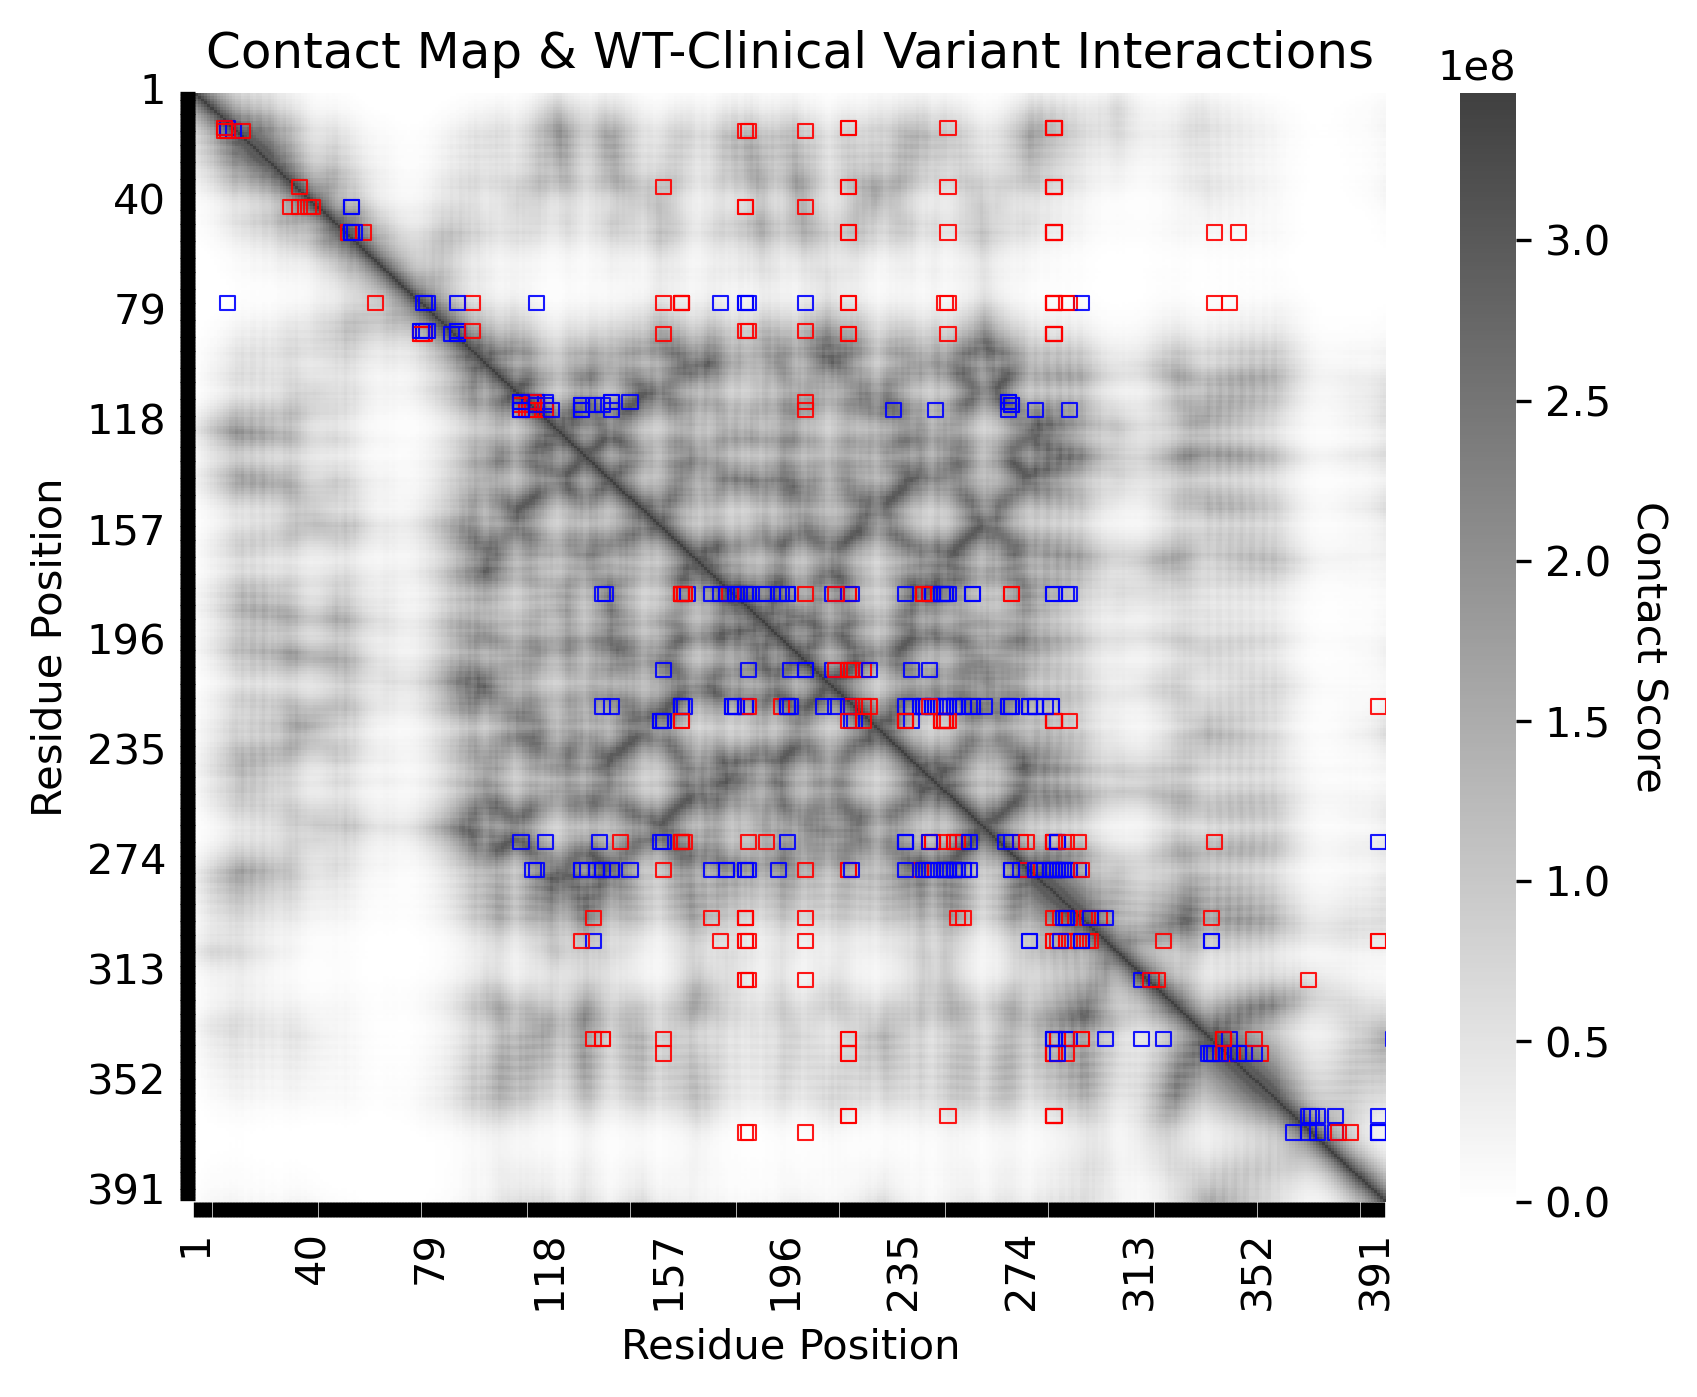

In [131]:
figS6b = ab.plot_contact_and_sensitization_maps(
    contact_map_binned=contact_map_ref_binned,
    outlier_sig=top_interactions, 
    heatmap_alpha=0.75,
    height_width=5,
    rectangles_cmap={"more pathogenic": "red", "more benign": "blue", "neutral": "grey"},
    title=rf"Contact Map & WT-Clinical Variant Interactions",# +"\n"+rf"(Interaction Strength $\geq$ {interaction_threshold})",
    show_plot=(False, True),
    # figsize=(10, 10)
)
figS6b["fig"]["subplot2"].savefig("manuscript/fig/figS6b.png", **utils.FIG_SAVE_KWARGS)

### Figure S6c

Contact enrichment: outlier detection method

In [132]:
ridge_enrichment = ab.compute_enrichment_vs_threshold(
    outlier_df=ridge_df,
    contact_map_binary=contact_map_binary_ref, 
    num_thresholds=50,
    linear_sampling=False,  
    interaction_col="interaction_strength"
)

  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [00:00<00:00, 112.56it/s]


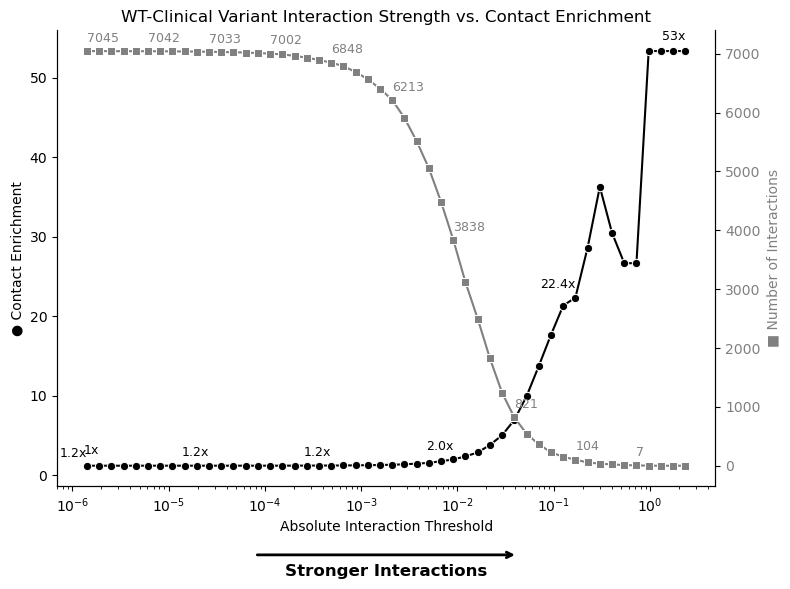

In [133]:
figS6c = ab.plot_enrichment_vs_interactions(ridge_enrichment,   
                                           figsize=(8, 6),
                                   log_x_axis=True, 
                                   y1_first_label=True,
                                   y1_last_label=True,
                                   y2_first_label=True,
                                   y2_last_label=True, )
figS6c["fig"].savefig("manuscript/fig/figS6c.png", **utils.FIG_SAVE_KWARGS)

### Figure 2E

Mean interaction strength per clinical variant.

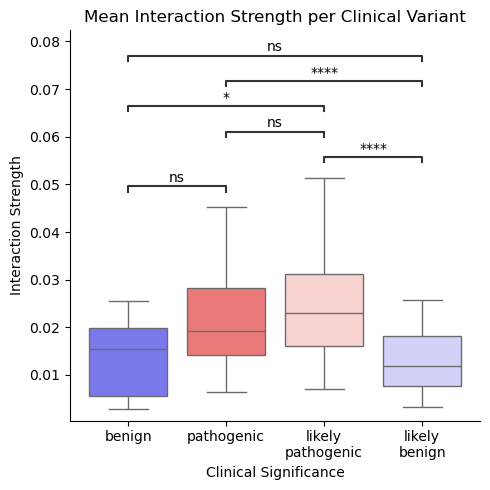

In [134]:
figS6d = ab.plot_clinsig_interaction_strength(
    ridge_df, 
    vep_prot,
    title="Mean Interaction Strength per Clinical Variant",
    xlabel="Clinical Significance",
    ylabel="Interaction Strength", 
    text_format="star",
    figsize=(5, 5),
)
figS6d["fig"].savefig("manuscript/fig/figS6d.png", **utils.FIG_SAVE_KWARGS)

### Figure 2F

Interaction strength vs. Angstroms.

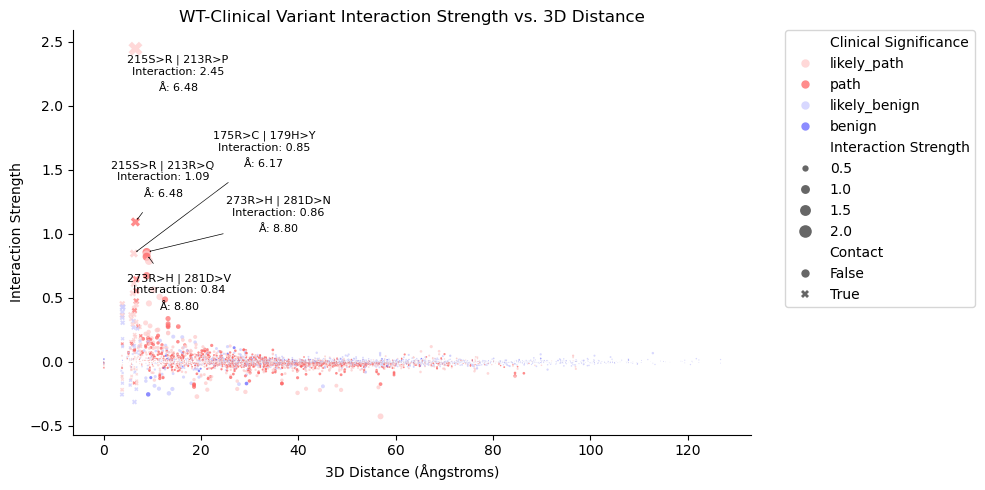

In [135]:
# Use a lambda to pass contact_map_ref as a closure variable, avoiding the error
ridge_df["position_distance"] = (ridge_df["wt_position"] - ridge_df["clinical_position"]).abs()
ridge_df["Angstroms"] = ridge_df.apply(lambda x: ab.get_contact_score(x, contact_map_dist_ref), axis=1)
ridge_df["is_contact"] = ridge_df.apply(lambda x: ab.get_contact_score(x, contact_map_binary_ref)==1, axis=1) 
ridge_df["clinical_variant_fmt"] = ridge_df["clinical_variant"].apply(
    lambda x: (
        f"{x[1:-1]}{x[0]}>{x[-1]}"
        if isinstance(x, str) and len(x) >= 3 and x[1:-1].isdigit()
        else x
    )
)
ridge_df['protein'] = ridge_df['site'].str.split(":").str[0]
ridge_df = utils.add_hgvsp_id(ridge_df)

fig6e = ab.plot_wt_clinical_interaction_vs_angstroms(ridge_df, vep_prot, N=5)
fig6e["fig"].savefig("manuscript/fig/figS6e.png", **utils.FIG_SAVE_KWARGS)

Check the baseline enrichment of all interactions with the top WT variant.

In [141]:
top_wt_variants = ridge_df.groupby("wt_variant")["interaction_strength"].mean().sort_values(ascending=False)
contact_maps_wt = {k:v for k,v in contact_maps.items() if top_wt_variants.index[0].replace(">","_") in k or k==cf.get_ref_key(contact_maps)}
top_wt_variants.head()

wt_variant
273R>H    0.057969
215S>R    0.055300
175R>C    0.047084
263N>D    0.029662
72P>R     0.026771
Name: interaction_strength, dtype: float64

In [142]:
ridge_enrichment_at_threshold_top1= ab.compute_enrichment_vs_threshold(
    outlier_df=ridge_df.loc[(ridge_df["wt_variant"]==top_wt_variants.index.tolist()[0])],
    contact_map_binary=contact_map_binary_ref, 
    thresholds=[0,],
    linear_sampling=False,  
    interaction_col="interaction_strength"
)
ridge_enrichment_at_threshold_top1

100%|██████████| 1/1 [00:00<00:00, 111.78it/s]


,observed_prob,expected_prob,binom_test,enrichment,interaction_threshold,n_interactions
0,0.055556,0.018738,"BinomTestResult(k=9, n=162, alternative='two-s...",2.964927,0,271


### Figure 2G
Personalized contact maps vs. REF contact map. 

In [143]:
#### Import from local AlphaFold files that I generated myself ####
pdb_files = cf.search_files(base_dir =  os.path.expanduser("~/projects/data/colabfold"),
                            tx_id = tx_id,
                            subdir = "af2_sameMSA",
                            suffix = ".pdb*",
                            model_number = 1 ) 

contact_maps = cf.import_contact_maps(pdb_files,
                                        return_distance_map=True,
                                        continuous=True)  

26 PDB files found


100%|██████████| 26/26 [00:00<00:00, 42.92it/s]


<string>:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


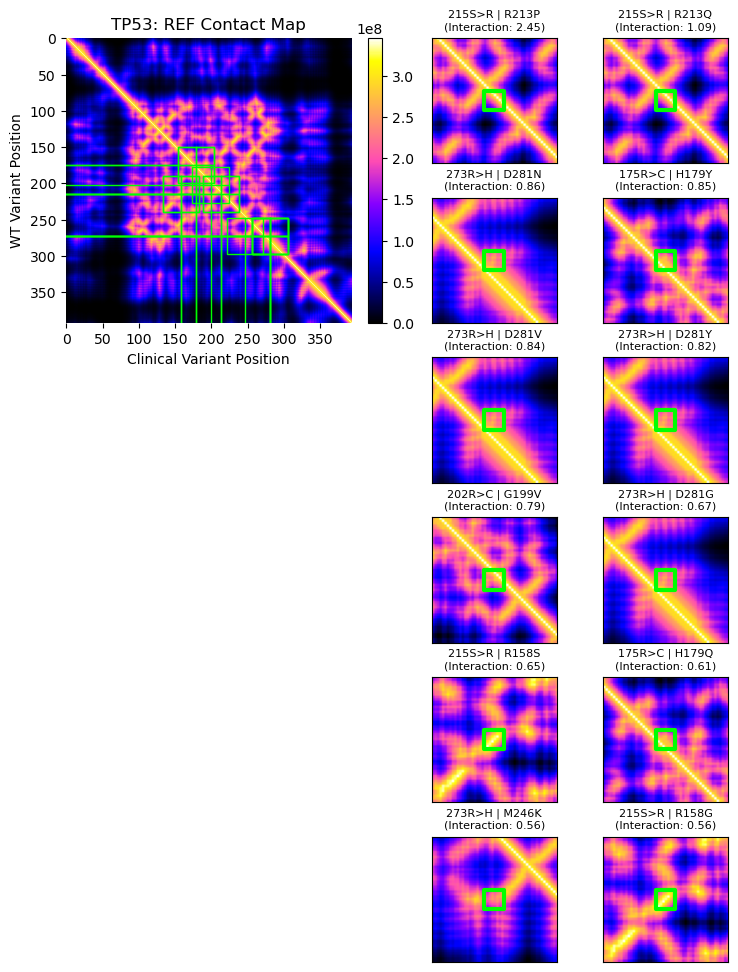

In [146]:
figS6f = cf.plot_contact_map_and_zooms(
    contact_maps_wt,
    ridge_df,
    target_gene, 
    main_plot_above=False,
    max_highlights=12,
    highlight_size=50,
    zoom_nrows = 6,
    zoom_ncols=None,
    zoom_subplot_size = 2,
    main_nrows = 2,
    main_ncols = 2,
    pow=4,
    main_padding=0.25,
    save_path="manuscript/fig/figS6f.png"
)

### Figure 2H

Create population-weighted contact maps

For each superpopulation, weight the contacts maps according to their frequency in those populations.

In [147]:
contact_maps_binary = cf.import_contact_maps(pdb_files,
                                             return_distance_map=False,
                                             continuous=False)

  0%|          | 0/26 [00:00<?, ?it/s]

100%|██████████| 26/26 [00:01<00:00, 21.45it/s]


In [148]:
haplotypes_hgdp = hs.get_haplotypes(cache = hs.DIR_DICT["HGDP_haplotypes"],
                                     tx_ids=tx_id, 
                                    cache_only = True) 
haplotypes_1kg = hs.get_haplotypes(cache = hs.DIR_DICT["haplotypes"],
                                    tx_ids=tx_id, 
                                    cache_only = True) 
haplotypes = hs.merge_haplotype_datasets({"1KG":haplotypes_1kg, "HGDP":haplotypes_hgdp},
                                         tx_id_method = "intersection",
                                         use_deepcopy = True)

# Get a merged FASTA file
merged_fasta = hs.haplotypes_to_fasta(haplotypes=haplotypes,  
                        tx_ids=[tx_id],
                        save_dir=os.path.expanduser(f"~/projects/data/colabfold/{tx_id}"), 
                        split_subdir="",
                        # force=True,
                        compress=False) 

# Insert or add padding to each contact map (using the MSA as a guide)to make them all the same length
msa = bp.read_msa(merged_fasta[list(merged_fasta.keys())[0]], to_msa=True)
contact_maps_binary = cf.pad_all_contact_maps_to_msa(contact_maps=contact_maps_binary, 
                                                     msa=msa) 


Found haplotypes of 85520 transcripts in: '/home/schilder/projects/data/Human_Genome_Diversity_Project/haplosaurus/'


Getting haplotypes:   0%|          | 0/1 [00:00<?, ?it/s]

Found haplotypes of 47329 transcripts in: '/home/schilder/.cache/ensembl_rest/haplotypes/'


Getting haplotypes:   0%|          | 0/1 [00:00<?, ?it/s]

Using deepcopy
Merging 1 tx_ids using intersection


...

Merging haplotypes:   0%|          | 0/1 [00:00<?, ?it/s]

Getting haplotype names:   0%|          | 0/1 [00:00<?, ?it/s]

Merged 26 haplotypes across 1 tx_ids.


Converting haplotypes to split FASTAs:   0%|          | 0/1 [00:00<?, ?it/s]

Padding contact maps to MSA: 100%|██████████| 26/26 [00:00<00:00, 891.11it/s]


In [149]:
haps_to_samples = hs.haplotypes_to_samples(haplotypes=haplotypes,  
                                           as_df=True,
                                           add_sample_metadata=True,
                                           return_seqs=False, 
                                           add_ref=False, 
                                           duplicate_ref=False,
                                           verbose=True,
                                           )

freq_df = hs.calculate_haplotype_frequency_per_superpop(
    haps_to_samples,
    cast=True, 
    verbose=True,
    add_specificity_cols=True
)
freq_df.head()

Extracting sample IDs:   0%|          | 0/1 [00:00<?, ?it/s]

Number of samples: 3938
Number of transcripts to process: 1


Processing sample to haplotype name maps:   0%|          | 0/1 [00:00<?, ?it/s]

Converting haplotypes to DataFrame
Adding sample metadata to the DataFrame
0 samples are missing superpopulation metadata
Samples before merging: 3826
Samples after merging: 3826
Final shape: (7720, 16)
>> haplotype(s): 26
>> cohort(s): 3
>> cohort_sample(s): 3878
>> sample(s): 3826
>> population(s): 158
>> superpopulation(s): 8
>> sex(s): 2
0 samples are missing superpopulation metadata

Number of variants specific to each superpopulation:
specific_superpopulation
EAS    5
AFR    5
SAS    4
EUR    4
AMR    4
MID    1
Name: count, dtype: int64

Percentage of superpopulation-specific haplotypes: 88.46%


,haplotype,AFR_freq,AMR_freq,CSA_freq,EAS_freq,EUR_freq,MID_freq,OCE_freq,SAS_freq,AFR_samples,AMR_samples,CSA_samples,EAS_samples,EUR_samples,MID_samples,OCE_samples,SAS_samples,top_superpopulation,top_superpopulation_freq,superpopulation_count,specific_superpopulation,specific_superpopulation_samples
0,ENSP00000269305:10V>I,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000992,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,SAS,0.000992,1,SAS,1.0
1,"ENSP00000269305:11E>Q,72P>R",0.000000,0.0,0.0,0.001379,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,EAS,0.001379,1,EAS,2.0
2,ENSP00000269305:215S>R,0.000000,0.0,0.0,0.000000,0.000753,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,EUR,0.000753,1,EUR,1.0
3,ENSP00000269305:220Y>H,0.000418,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,AFR,0.000418,1,AFR,1.0
4,ENSP00000269305:263N>D,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000992,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,SAS,0.000992,1,SAS,1.0


In [150]:
pop_contact_maps = cf.compute_population_specific_contact_maps(
    contact_maps=contact_maps,
    contact_maps_binary=contact_maps_binary,
    freq_df=freq_df, 
    superpopulation_specific_only=False,
    exclude_ref_from_weights=True,
    weight_binary_maps=True,
)
specific_maps = pop_contact_maps["specific_maps"]
specific_diff_maps = pop_contact_maps["specific_diff_maps"]
specific_binary_diff_maps = pop_contact_maps["specific_binary_diff_maps"]
specific_binary_diff_figs = pop_contact_maps["specific_binary_diff_figs"]

100%|██████████| 8/8 [00:00<00:00,  8.86it/s]


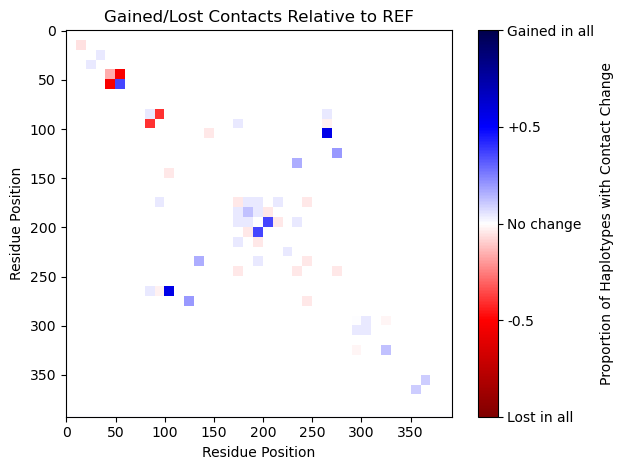

In [155]:
figS6g = cf.plot_contact_map_diff(contact_maps_binary,  
                                bin_size=10,
                                weights=None,
                                show_plot=True,
                                verbose=False)
figS6g["fig"].savefig("manuscript/fig/figS6g.png", **utils.FIG_SAVE_KWARGS)

### Figure 2I

In [156]:
%%capture

fig_superop_diff = cf.plot_superpopulation_contact_diff(
    specific_binary_diff_figs,
    specific_binary_diff_maps, 
    use_common_heatmap_scale=True,
    set_common_barplot_ylim=True,
    show_plot=False
)

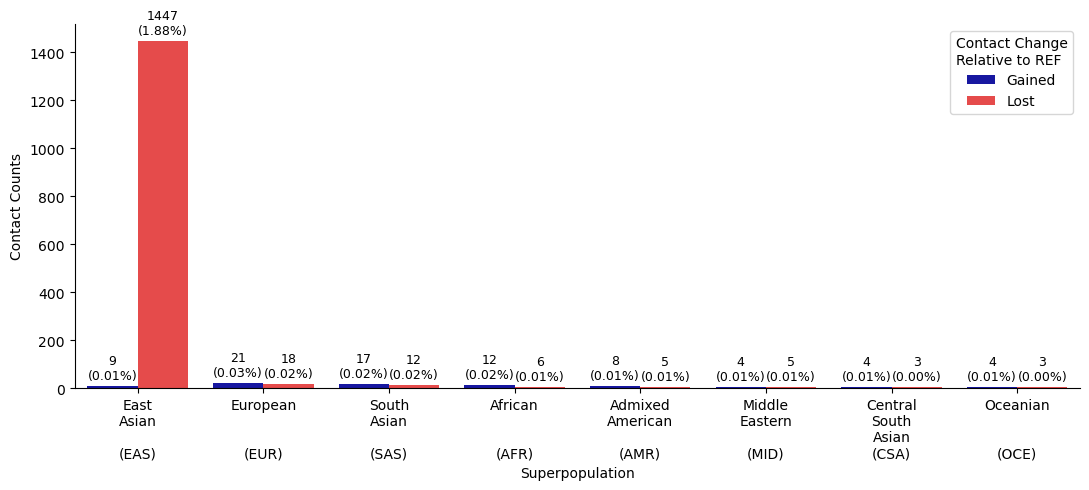

In [158]:
figS6h = cf.plot_contact_map_diff_barplot_grouped(
    bar_df=fig_superop_diff['data'],
    group_by="superpopulation", 
      figsize=(11, 5),
    )
figS6h['fig'].savefig("manuscript/fig/figS6h.png", **utils.FIG_SAVE_KWARGS)
